In [ ]:
!pip install netCDF4 xarray "sunpy[net]" mpl_animators

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00


In [ ]:
#This connects your google drive so data persists between sessions

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/solar-flare-precursors'

folders = [
    f'{PROJECT_DIR}/data/raw',           # Raw NCEI NetCDF files go here
    f'{PROJECT_DIR}/data/processed',      # Cleaned CSV files
    f'{PROJECT_DIR}/data/features',       # Feature matrices
    f'{PROJECT_DIR}/data/flare_catalog',  # Flare event lists
    f'{PROJECT_DIR}/notebooks',           # Save notebook copies here
    f'{PROJECT_DIR}/results',             # Plots, metrics, tables
    f'{PROJECT_DIR}/models',              # Saved model weights (later)
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Verify it worked
print("Project directory created at:")
print(f"  {PROJECT_DIR}\n")
print("Folder structure:")
for folder in folders:
    short = folder.replace(PROJECT_DIR, '')
    print(f"  📁 {short}")

print("\n✓ Google Drive mounted. Your data will persist between sessions.")

Mounted at /content/drive
Project directory created at:
  /content/drive/MyDrive/solar-flare-precursors

Folder structure:
  📁 /data/raw
  📁 /data/processed
  📁 /data/features
  📁 /data/flare_catalog
  📁 /notebooks
  📁 /results
  📁 /models

✓ Google Drive mounted. Your data will persist between sessions.


In [ ]:
# Confirms every package loads. Run this once per session.

import importlib
import sys

print(f"Python version: {sys.version.split()[0]}\n")

packages = {
    'numpy':      'Array math',
    'pandas':     'DataFrames',
    'scipy':      'Signal processing (FFT, peaks, convex hull)',
    'sklearn':    'ML models and metrics',
    'matplotlib': 'Plotting',
    'seaborn':    'Statistical plots',
    'netCDF4':    'Reading NCEI NetCDF files',
    'xarray':     'Labeled multi-dimensional arrays',
    'sunpy':      'Solar physics data access',
    'torch':      'PyTorch (for LSTM later)',
}

all_good = True
for pkg, purpose in packages.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', '?')
        print(f"  ✓  {pkg:12s} {ver:>10s}  — {purpose}")
    except ImportError:
        print(f"  ✗  {pkg:12s}            — {purpose}  ← MISSING")
        all_good = False

if all_good:
    print("\n✓ All packages ready. Environment is clean.")
else:
    print("\n✗ Some packages missing — fix before continuing.")

Python version: 3.12.13

  ✓  numpy             2.0.2  — Array math
  ✓  pandas            2.2.2  — DataFrames
  ✓  scipy            1.16.3  — Signal processing (FFT, peaks, convex hull)
  ✓  sklearn           1.6.1  — ML models and metrics
  ✓  matplotlib       3.10.0  — Plotting
  ✓  seaborn          0.13.2  — Statistical plots
  ✓  netCDF4           1.7.4  — Reading NCEI NetCDF files
  ✓  xarray        2025.12.0  — Labeled multi-dimensional arrays
  ✓  sunpy             7.1.1  — Solar physics data access
  ✓  torch        2.10.0+cpu  — PyTorch (for LSTM later)

✓ All packages ready. Environment is clean.


In [ ]:
# ============================================================
# CELL 4: Download GOES XRS Data (Test Pull — 1 month)
# ============================================================
# We start small: just January 2022 (active period, plenty of flares).
# This tests that SunPy can talk to NOAA and that the data looks right.
# Once confirmed, we'll pull the full 2017–2024 range.

from sunpy.net import Fido, attrs as a
from sunpy.timeseries import TimeSeries
import matplotlib.pyplot as plt
import os

# --- Search for GOES XRS data ---
# This queries NOAA's servers for 1-minute averaged X-ray flux
print("Searching for GOES-16 XRS data: Jan 2022...")
result = Fido.search(
    a.Time('2022-01-01', '2022-01-31'),
    a.Instrument.xrs,
    a.goes.SatelliteNumber(16),
    a.Resolution("avg1m")       # 1-minute averages
)
print(result)

# --- Download the files ---
# Save to Google Drive so we don't re-download next session
RAW_DIR = '/content/drive/MyDrive/solar-flare-precursors/data/raw'
print(f"\nDownloading to: {RAW_DIR}")
files = Fido.fetch(result, path=f'{RAW_DIR}/{{file}}')
print(f"\nDownloaded {len(files)} files.")

# --- Load into a TimeSeries and convert to DataFrame ---
ts = TimeSeries(files, concatenate=True)
df_test = ts.to_dataframe()

print(f"\nData shape: {df_test.shape}")
print(f"Columns: {df_test.columns.tolist()}")
print(f"Date range: {df_test.index.min()} to {df_test.index.max()}")
print(f"\nFirst 5 rows:")
df_test.head()

The following packages are not installed:
['cdflib>=1.3.2']
To install sunpy with these dependencies use `pip install sunpy[timeseries]` or `pip install sunpy[all]` for all extras. 
If you installed sunpy via conda, please report this to the community channel: https://matrix.to/#/#sunpy:openastronomy.org [sunpy.util.sysinfo]
The following packages are not installed:
['cdflib>=1.3.2']
To install sunpy with these dependencies use `pip install sunpy[timeseries]` or `pip install sunpy[all]` for all extras. 
If you installed sunpy via conda, please report this to the community channel: https://matrix.to/#/#sunpy:openastronomy.org


Searching for GOES-16 XRS data: Jan 2022...
Results from 1 Provider:

31 Results from the XRSClient:
Source: <8: https://umbra.nascom.nasa.gov/goes/fits 
8-15: https://www.ncei.noaa.gov/data/goes-space-environment-monitor/access/science/ 
16-17: https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/

       Start Time               End Time        Instrument  Physobs   Source Provider Resolution SatelliteNumber
----------------------- ----------------------- ---------- ---------- ------ -------- ---------- ---------------
2022-01-01 00:00:00.000 2022-01-01 23:59:59.999        XRS irradiance   GOES     NOAA      avg1m              16
2022-01-02 00:00:00.000 2022-01-02 23:59:59.999        XRS irradiance   GOES     NOAA      avg1m              16
2022-01-03 00:00:00.000 2022-01-03 23:59:59.999        XRS irradiance   GOES     NOAA      avg1m              16
2022-01-04 00:00:00.000 2022-01-04 23:59:59.999        XRS irradiance   GOES     NOAA      avg1m              16

Files Downloaded:   0%|          | 0/31 [00:00<?, ?file/s]


Downloaded 31 files.

Data shape: (44640, 4)
Columns: ['xrsa', 'xrsb', 'xrsa_quality', 'xrsb_quality']
Date range: 2022-01-01 00:00:00 to 2022-01-31 23:59:00

First 5 rows:


,xrsa,xrsb,xrsa_quality,xrsb_quality
2022-01-01 00:00:00,1.033858e-08,2.197394e-07,0,0
2022-01-01 00:01:00,1.103255e-08,2.203838e-07,0,0
2022-01-01 00:02:00,1.073066e-08,2.154663e-07,0,0
2022-01-01 00:03:00,1.118890e-08,2.132466e-07,0,0
2022-01-01 00:04:00,1.129419e-08,2.097806e-07,0,0


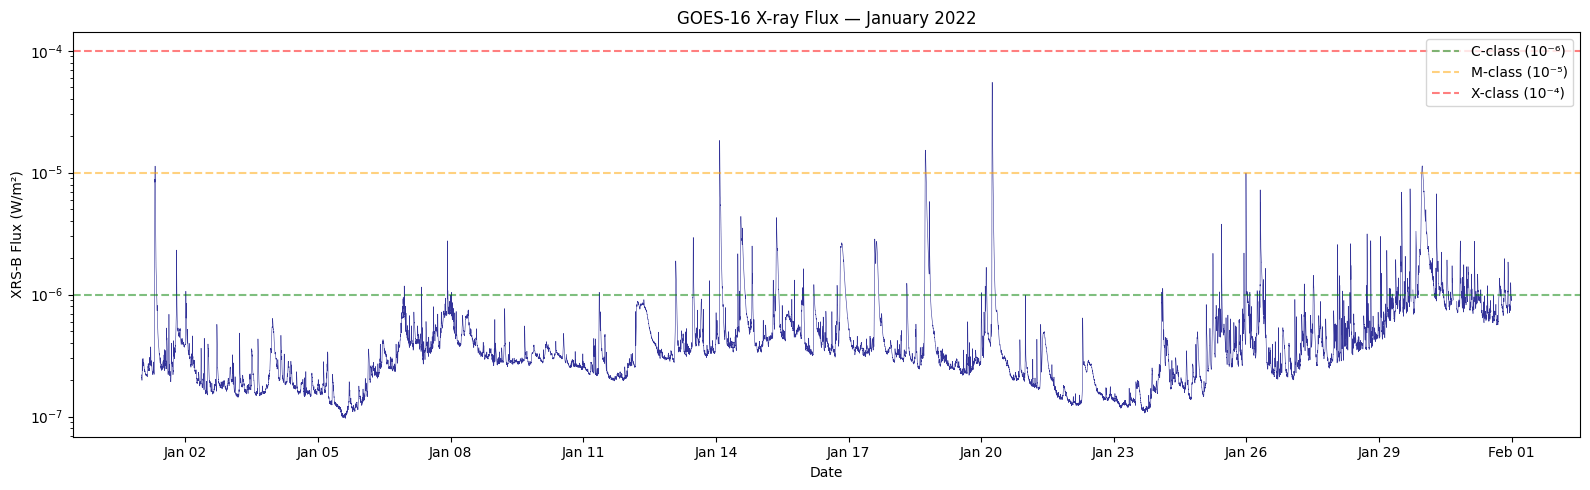


Peak flux this month: 5.51e-05 W/m²
This month contains at least one M-class flare!


In [ ]:
# ============================================================
# CELL 5: Quick-Look Plot — Does this data have flares?
# ============================================================
# Plot the xrsb flux on a log scale. Flares show up as sharp spikes.
# The horizontal dashed lines mark flare class thresholds.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 5))

# Plot the long channel (flare classification channel)
ax.semilogy(df_test.index, df_test['xrsb'],
            linewidth=0.4, color='navy', alpha=0.8)

# --- Flare class thresholds ---
# These are the official NOAA definitions
ax.axhline(1e-6, color='green',  linestyle='--', alpha=0.5, label='C-class (10⁻⁶)')
ax.axhline(1e-5, color='orange', linestyle='--', alpha=0.5, label='M-class (10⁻⁵)')
ax.axhline(1e-4, color='red',    linestyle='--', alpha=0.5, label='X-class (10⁻⁴)')

ax.set_ylabel('XRS-B Flux (W/m²)')
ax.set_xlabel('Date')
ax.set_title('GOES-16 X-ray Flux — January 2022')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

plt.tight_layout()
plt.show()

# --- Quick flare count ---
peak_flux = df_test['xrsb'].max()
print(f"\nPeak flux this month: {peak_flux:.2e} W/m²")
if peak_flux >= 1e-4:
    print("This month contains at least one X-class flare!")
elif peak_flux >= 1e-5:
    print("This month contains at least one M-class flare!")
elif peak_flux >= 1e-6:
    print("This month contains C-class flares (smaller ones).")

In [ ]:
# ============================================================
# CELL 6: Download Full Dataset (2017–2024)
# ============================================================
# This pulls ~8 years of GOES XRS data. It takes 10-20 minutes
# but only needs to run ONCE — files save to Google Drive.
#
# We download year-by-year so if it gets interrupted,
# you don't lose everything and can resume.

from sunpy.net import Fido, attrs as a
from sunpy.timeseries import TimeSeries
import os, glob

RAW_DIR = '/content/drive/MyDrive/solar-flare-precursors/data/raw'
PROCESSED_DIR = '/content/drive/MyDrive/solar-flare-precursors/data/processed'

# --- Download year by year ---
years = range(2017, 2025)  # 2017 through 2024

for year in years:
    # Check if we already downloaded this year
    year_files = glob.glob(f'{RAW_DIR}/*{year}*.nc') + \
                 glob.glob(f'{RAW_DIR}/*{year}*.fits')

    if len(year_files) > 300:  # ~365 files per year
        print(f"  {year}: Already have {len(year_files)} files — skipping.")
        continue

    print(f"\n{'='*50}")
    print(f"  Downloading {year}...")
    print(f"{'='*50}")

    try:
        result = Fido.search(
            a.Time(f'{year}-01-01', f'{year}-12-31'),
            a.Instrument.xrs,
            a.goes.SatelliteNumber(16),
            a.Resolution("avg1m")
        )
        print(f"  Found {result.file_num} files")

        files = Fido.fetch(result, path=f'{RAW_DIR}/{{file}}')
        print(f"  Downloaded {len(files)} files for {year}")

    except Exception as e:
        print(f"  ERROR downloading {year}: {e}")
        print(f"  Continuing to next year...")
        continue

print(f"\n{'='*50}")
print(f"  Download complete!")
print(f"{'='*50}")

# --- Count what we have ---
all_files = glob.glob(f'{RAW_DIR}/*.nc') + glob.glob(f'{RAW_DIR}/*.fits')
print(f"Total files in raw directory: {len(all_files)}")

  2017: Already have 328 files — skipping.
  2018: Already have 365 files — skipping.
  2019: Already have 365 files — skipping.
  2020: Already have 375 files — skipping.
  2021: Already have 375 files — skipping.
  2022: Already have 365 files — skipping.
  2023: Already have 365 files — skipping.
  2024: Already have 366 files — skipping.

  Download complete!
Total files in raw directory: 2885


In [ ]:
# ============================================================
# CELL 7: Load All Data into One DataFrame
# ============================================================
# Combines all downloaded files into a single time series.
# Then saves the result as a CSV to Google Drive so you
# never have to re-load the raw files again.

from sunpy.timeseries import TimeSeries
import glob
import pandas as pd
import os

RAW_DIR = '/content/drive/MyDrive/solar-flare-precursors/data/raw'
PROCESSED_DIR = '/content/drive/MyDrive/solar-flare-precursors/data/processed'
SAVE_PATH = f'{PROCESSED_DIR}/goes_xrs_2017_2024.csv'

# --- Check if we already built this file ---
if os.path.exists(SAVE_PATH):
    print(f"Processed file already exists! Loading from:")
    print(f"  {SAVE_PATH}")
    df = pd.read_csv(SAVE_PATH, parse_dates=['timestamp'], index_col='timestamp')

else:
    # --- Find all downloaded files ---
    files = sorted(glob.glob(f'{RAW_DIR}/*.nc') + glob.glob(f'{RAW_DIR}/*.fits'))
    print(f"Found {len(files)} raw files.")
    print(f"Loading and concatenating (this takes a few minutes)...\n")

    # Load in chunks by year to manage memory
    all_dfs = []
    for year in range(2017, 2025):
        year_files = [f for f in files if str(year) in os.path.basename(f)]
        if not year_files:
            print(f"  {year}: No files found — skipping.")
            continue

        try:
            ts = TimeSeries(year_files, concatenate=True)
            year_df = ts.to_dataframe()
            all_dfs.append(year_df)
            print(f"  {year}: {len(year_df):>8,} rows  "
                  f"({year_df.index.min().strftime('%Y-%m-%d')} to "
                  f"{year_df.index.max().strftime('%Y-%m-%d')})")
        except Exception as e:
            print(f"  {year}: ERROR — {e}")
            continue

    # --- Concatenate all years ---
    df = pd.concat(all_dfs)
    df = df.sort_index()

    # Drop any duplicate timestamps
    n_dupes = df.index.duplicated().sum()
    if n_dupes > 0:
        print(f"\nRemoved {n_dupes} duplicate timestamps.")
        df = df[~df.index.duplicated(keep='first')]

    # --- Save to Drive ---
    df.index.name = 'timestamp'
    df.to_csv(SAVE_PATH)
    print(f"\nSaved to: {SAVE_PATH}")

# --- Summary ---
print(f"\n{'='*50}")
print(f"  FULL DATASET LOADED")
print(f"{'='*50}")
print(f"  Shape:      {df.shape}")
print(f"  Date range: {df.index.min()} to {df.index.max()}")
print(f"  Columns:    {df.columns.tolist()}")
print(f"  Memory:     {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"{'='*50}")

Processed file already exists! Loading from:
  /content/drive/MyDrive/solar-flare-precursors/data/processed/goes_xrs_2017_2024.csv

  FULL DATASET LOADED
  Shape:      (4154400, 4)
  Date range: 2017-02-07 00:00:00 to 2024-12-31 23:59:00
  Columns:    ['xrsa', 'xrsb', 'xrsa_quality', 'xrsb_quality']
  Memory:     166.2 MB


In [ ]:
# ============================================================
# CELL 8: Data Cleaning
# ============================================================
# Remove bad data, fill short gaps, compute channel ratio.
# This follows the cleaning protocol from the baseline pipeline.

import numpy as np

print("BEFORE CLEANING:")
print(f"  Shape: {df.shape}")
print(f"  NaN in xrsb: {df['xrsb'].isna().sum()}")
print(f"  NaN in xrsa: {df['xrsa'].isna().sum()}")

# --- Step 1: Remove rows where quality flag != 0 ---
# 0 means "good data". Anything else is an instrument issue.
bad_quality = (df['xrsb_quality'] != 0) | (df['xrsa_quality'] != 0)
n_bad_quality = bad_quality.sum()
df.loc[bad_quality, ['xrsb', 'xrsa']] = np.nan
print(f"\n  Flagged by quality filter: {n_bad_quality:,} rows "
      f"({100*n_bad_quality/len(df):.2f}%)")

# --- Step 2: Remove negative values (instrument artifacts) ---
n_neg_b = (df['xrsb'] < 0).sum()
n_neg_a = (df['xrsa'] < 0).sum()
df.loc[df['xrsb'] < 0, 'xrsb'] = np.nan
df.loc[df['xrsa'] < 0, 'xrsa'] = np.nan
print(f"  Negative xrsb values: {n_neg_b:,}")
print(f"  Negative xrsa values: {n_neg_a:,}")

# --- Step 3: Remove zeros (data gaps disguised as data) ---
n_zero_b = (df['xrsb'] == 0).sum()
n_zero_a = (df['xrsa'] == 0).sum()
df.loc[df['xrsb'] == 0, 'xrsb'] = np.nan
df.loc[df['xrsa'] == 0, 'xrsa'] = np.nan
print(f"  Zero xrsb values: {n_zero_b:,}")
print(f"  Zero xrsa values: {n_zero_a:,}")

# --- Step 4: Analyze gaps before filling ---
is_gap = df['xrsb'].isna()
gap_groups = is_gap.ne(is_gap.shift()).cumsum()
gap_lengths = is_gap.groupby(gap_groups).sum()
gap_lengths = gap_lengths[gap_lengths > 0]

print(f"\n  Gap analysis:")
print(f"    Total gaps: {len(gap_lengths):,}")
print(f"    Short gaps (< 10 min): {(gap_lengths < 10).sum():,}")
print(f"    Medium gaps (10-60 min): {((gap_lengths >= 10) & (gap_lengths < 60)).sum():,}")
print(f"    Long gaps (> 60 min): {(gap_lengths >= 60).sum():,}")
if len(gap_lengths) > 0:
    print(f"    Longest gap: {gap_lengths.max():.0f} minutes")

# --- Step 5: Interpolate short gaps only (< 10 minutes) ---
df['xrsb'] = df['xrsb'].interpolate(method='linear', limit=10)
df['xrsa'] = df['xrsa'].interpolate(method='linear', limit=10)

# --- Step 6: Compute channel ratio (temperature proxy) ---
df['channel_ratio'] = df['xrsa'] / df['xrsb']
df['channel_ratio'] = df['channel_ratio'].replace([np.inf, -np.inf], np.nan)
df['channel_ratio'] = df['channel_ratio'].interpolate(method='linear', limit=10)

# --- Step 7: Mark remaining gaps ---
df['has_gap'] = df['xrsb'].isna().astype(int)

# --- Summary ---
n_valid = df['xrsb'].notna().sum()
n_total = len(df)
print(f"\nAFTER CLEANING:")
print(f"  Valid data points: {n_valid:,} / {n_total:,} "
      f"({100*n_valid/n_total:.2f}%)")
print(f"  Remaining NaN: {df['xrsb'].isna().sum():,}")
print(f"  Columns: {df.columns.tolist()}")
print(f"\n  Channel ratio stats:")
print(df['channel_ratio'].describe().to_string())

BEFORE CLEANING:
  Shape: (4154400, 4)
  NaN in xrsb: 63573
  NaN in xrsa: 63573

  Flagged by quality filter: 117,071 rows (2.82%)
  Negative xrsb values: 0
  Negative xrsa values: 0
  Zero xrsb values: 0
  Zero xrsa values: 0

  Gap analysis:
    Total gaps: 1,988
    Short gaps (< 10 min): 908
    Medium gaps (10-60 min): 413
    Long gaps (> 60 min): 667
    Longest gap: 16441 minutes

AFTER CLEANING:
  Valid data points: 4,050,120 / 4,154,400 (97.49%)
  Remaining NaN: 104,280
  Columns: ['xrsa', 'xrsb', 'xrsa_quality', 'xrsb_quality', 'channel_ratio', 'has_gap']

  Channel ratio stats:
count    4.060549e+06
mean     5.877601e-01
std      1.272957e+00
min      5.212343e-04
25%      2.953889e-02
50%      8.457569e-02
75%      6.081419e-01
max      3.520411e+01


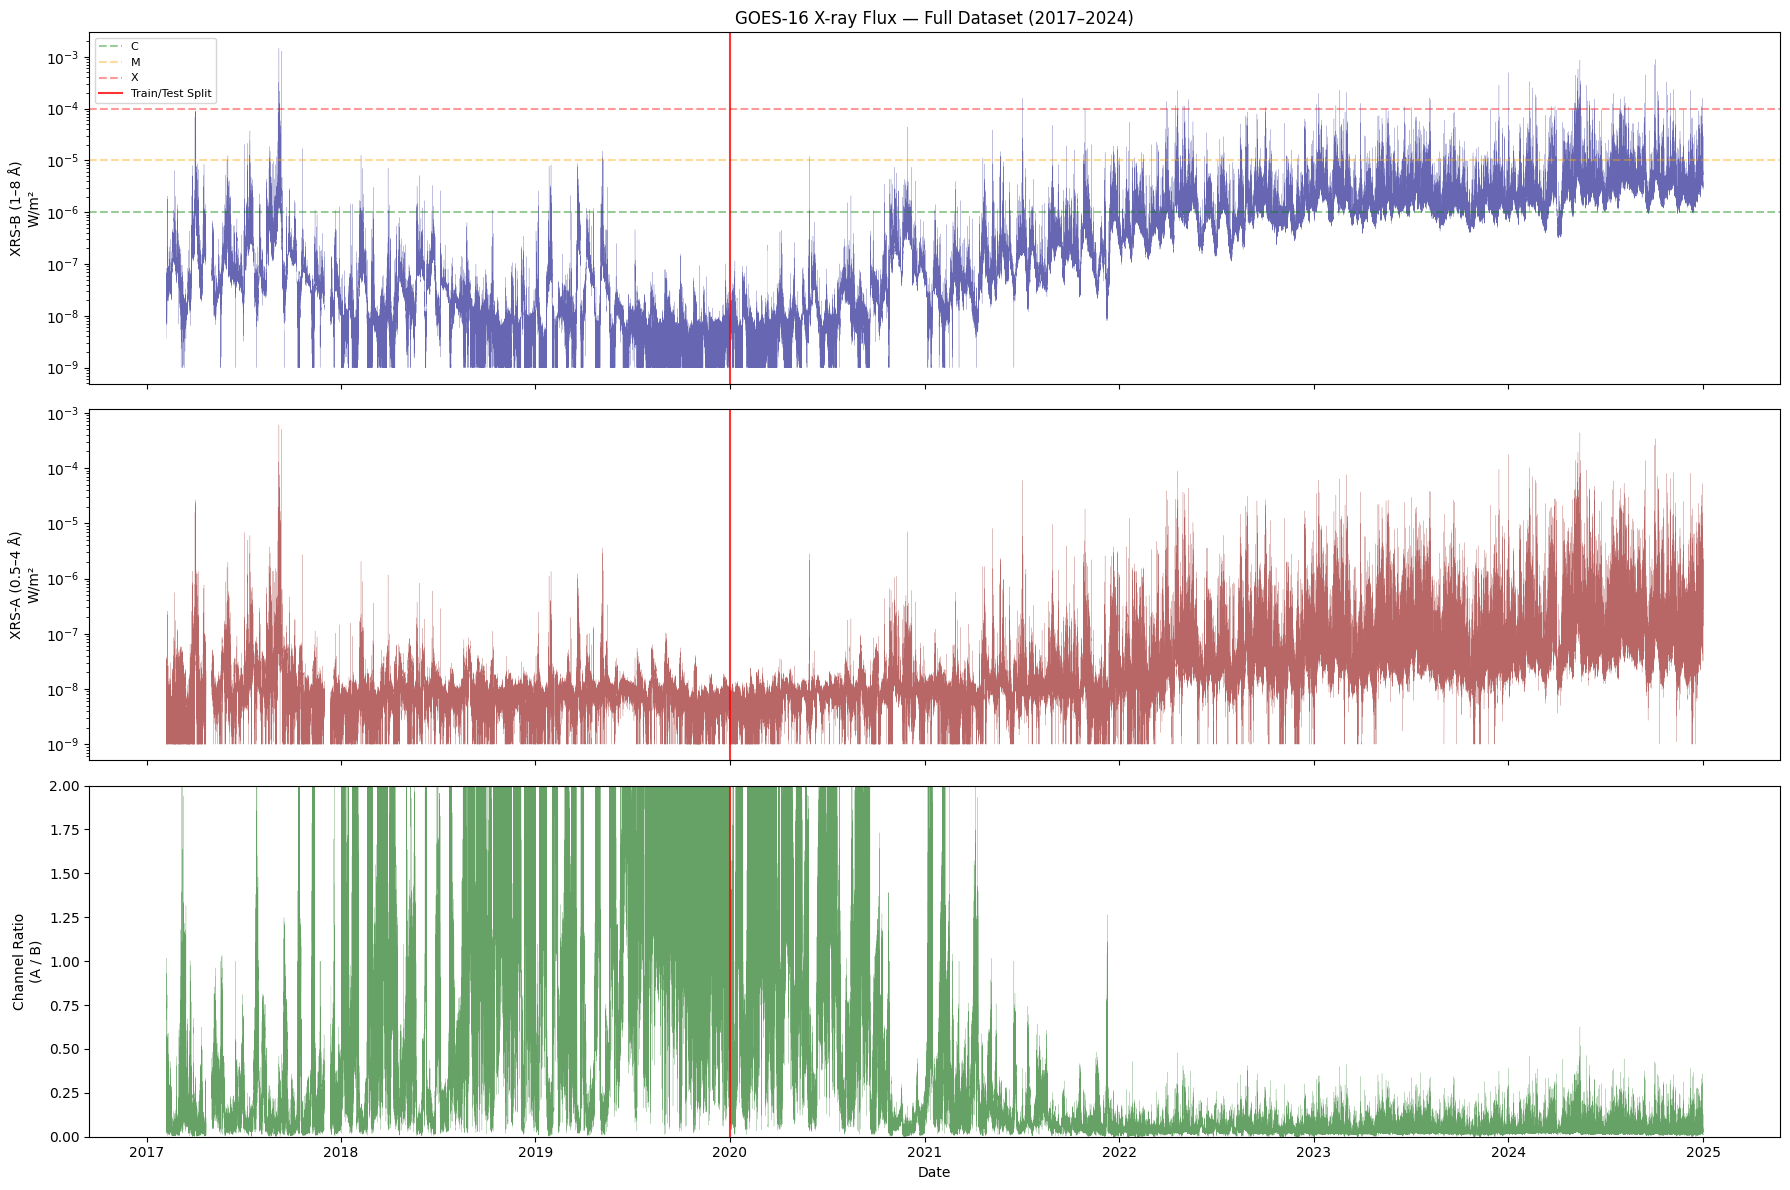

Left of the red line = TRAINING data (quiet solar minimum)
Right of the red line = TEST data (active solar maximum)

Notice how the right side is way more active — more flares,
higher baseline. That's solar cycle 25 ramping up.


In [ ]:
# ============================================================
# CELL 9: Full Time Series Plot
# ============================================================
# This is the big picture view. You should see solar cycle 24
# winding down (2017-2019) and cycle 25 ramping up (2020-2024).

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# --- Panel 1: XRS-B (the primary flare channel) ---
axes[0].semilogy(df.index, df['xrsb'], linewidth=0.15, color='navy', alpha=0.6)
axes[0].axhline(1e-6, color='green',  linestyle='--', alpha=0.4, label='C')
axes[0].axhline(1e-5, color='orange', linestyle='--', alpha=0.4, label='M')
axes[0].axhline(1e-4, color='red',    linestyle='--', alpha=0.4, label='X')
axes[0].set_ylabel('XRS-B (1–8 Å)\nW/m²')
axes[0].set_title('GOES-16 X-ray Flux — Full Dataset (2017–2024)')
axes[0].legend(loc='upper left', fontsize=8)

# --- Panel 2: XRS-A (short channel) ---
axes[1].semilogy(df.index, df['xrsa'], linewidth=0.15, color='darkred', alpha=0.6)
axes[1].set_ylabel('XRS-A (0.5–4 Å)\nW/m²')

# --- Panel 3: Channel ratio (temperature proxy) ---
axes[2].plot(df.index, df['channel_ratio'], linewidth=0.15, color='darkgreen', alpha=0.6)
axes[2].set_ylabel('Channel Ratio\n(A / B)')
axes[2].set_xlabel('Date')
axes[2].set_ylim(0, 2)  # Clip for readability

# --- Mark the train/test split ---
split_date = pd.Timestamp('2020-01-01')
for ax in axes:
    ax.axvline(split_date, color='red', linestyle='-', linewidth=1.5,
               alpha=0.8, label='Train/Test Split')

axes[0].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/full_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Left of the red line = TRAINING data (quiet solar minimum)")
print("Right of the red line = TEST data (active solar maximum)")
print("\nNotice how the right side is way more active — more flares,")
print("higher baseline. That's solar cycle 25 ramping up.")

In [ ]:
# ============================================================
# CELL 10: Download Flare Catalog (FIXED)
# ============================================================

from sunpy.net import hek, attrs as a
import pandas as pd
import os

CATALOG_DIR = '/content/drive/MyDrive/solar-flare-precursors/data/flare_catalog'
CATALOG_PATH = f'{CATALOG_DIR}/mx_flares_2017_2024.csv'

if os.path.exists(CATALOG_PATH):
    print("Flare catalog already exists! Loading from Drive...")
    mx_flares = pd.read_csv(CATALOG_PATH, parse_dates=['start_time', 'peak_time', 'end_time'])

else:
    print("Querying HEK for M/X class flares (2017–2024)...\n")

    client = hek.HEKClient()
    all_flares = []

    for year in range(2017, 2025):
        print(f"  {year}...", end=" ")

        try:
            result = client.search(
                a.Time(f'{year}-01-01', f'{year}-12-31'),
                a.hek.EventType('FL'),
                a.hek.FL.GOESCls >= 'M1.0'
            )

            for event in result:
                all_flares.append({
                    'start_time': event['event_starttime'],
                    'peak_time': event['event_peaktime'],
                    'end_time': event['event_endtime'],
                    'flare_class': event['fl_goescls'],
                    'source': event['frm_name'],
                })

            print(f"found {len(result)} events")

        except Exception as e:
            print(f"ERROR — {e}")
            continue

    # --- Build DataFrame ---
    mx_flares = pd.DataFrame(all_flares)
    mx_flares['start_time'] = pd.to_datetime(mx_flares['start_time'].astype(str))
    mx_flares['peak_time'] = pd.to_datetime(mx_flares['peak_time'].astype(str))
    mx_flares['end_time'] = pd.to_datetime(mx_flares['end_time'].astype(str))

    # --- Remove duplicates ---
    mx_flares = mx_flares.sort_values('start_time').reset_index(drop=True)

    keep = [True]
    for i in range(1, len(mx_flares)):
        time_diff = (mx_flares.loc[i, 'start_time'] -
                     mx_flares.loc[i-1, 'start_time']).total_seconds() / 60
        keep.append(time_diff > 10)

    n_before = len(mx_flares)
    mx_flares = mx_flares[keep].reset_index(drop=True)
    print(f"\nRemoved {n_before - len(mx_flares)} duplicate entries.")

    mx_flares['class_letter'] = mx_flares['flare_class'].str[0]

    mx_flares.to_csv(CATALOG_PATH, index=False)
    print(f"Saved to: {CATALOG_PATH}")

# --- Summary ---
print(f"\n{'='*50}")
print(f"  FLARE CATALOG")
print(f"{'='*50}")

mx_flares['class_letter'] = mx_flares['flare_class'].str[0]
n_m = (mx_flares['class_letter'] == 'M').sum()
n_x = (mx_flares['class_letter'] == 'X').sum()

print(f"  Total M/X flares: {len(mx_flares)}")
print(f"  M-class: {n_m}")
print(f"  X-class: {n_x}")
print(f"  Date range: {mx_flares['start_time'].min()} to {mx_flares['start_time'].max()}")

split_date = pd.Timestamp('2020-01-01')
train_flares = mx_flares[mx_flares['start_time'] < split_date]
test_flares = mx_flares[mx_flares['start_time'] >= split_date]

print(f"\n  Training period (2017–2019): {len(train_flares)} flares")
print(f"  Test period (2020–2024):     {len(test_flares)} flares")
print(f"{'='*50}")

Flare catalog already exists! Loading from Drive...

  FLARE CATALOG
  Total M/X flares: 1680
  M-class: 1602
  X-class: 78
  Date range: 2017-04-01 21:35:00 to 2024-12-30 22:35:00

  Training period (2017–2019): 45 flares
  Test period (2020–2024):     1635 flares


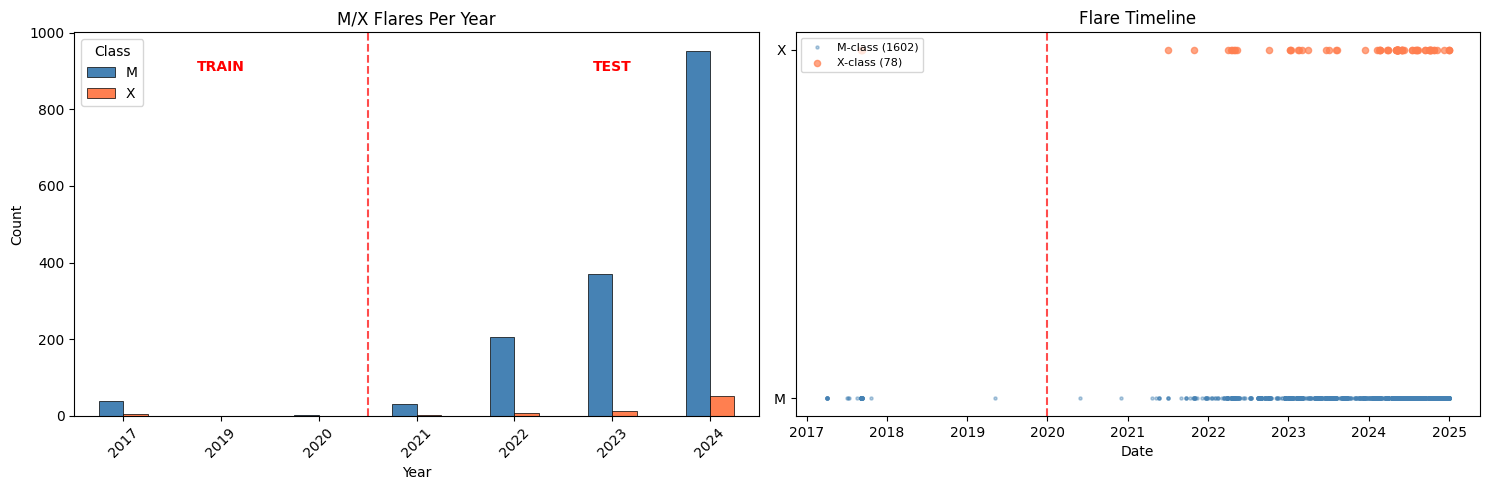

Notice: the test period (right of red line) has WAY more flares.
That's good — more events to evaluate our detectors against.


In [ ]:
# ============================================================
# CELL 11: Visualize Flare Distribution
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Flares per year ---
mx_flares['year'] = mx_flares['start_time'].dt.year
yearly = mx_flares.groupby(['year', 'class_letter']).size().unstack(fill_value=0)

yearly.plot(kind='bar', ax=axes[0], color={'M': 'steelblue', 'X': 'coral'},
            edgecolor='black', linewidth=0.5)
axes[0].set_title('M/X Flares Per Year')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Year')
axes[0].legend(title='Class')
axes[0].tick_params(axis='x', rotation=45)

# Add the train/test label
axes[0].axvline(2.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].text(1.0, axes[0].get_ylim()[1]*0.9, 'TRAIN', fontsize=10,
             color='red', ha='center', fontweight='bold')
axes[0].text(5.0, axes[0].get_ylim()[1]*0.9, 'TEST', fontsize=10,
             color='red', ha='center', fontweight='bold')

# --- Flare timeline ---
m_flares = mx_flares[mx_flares['class_letter'] == 'M']
x_flares_only = mx_flares[mx_flares['class_letter'] == 'X']

axes[1].scatter(m_flares['start_time'], [1]*len(m_flares),
                s=5, alpha=0.4, color='steelblue', label=f'M-class ({len(m_flares)})')
axes[1].scatter(x_flares_only['start_time'], [2]*len(x_flares_only),
                s=20, alpha=0.7, color='coral', label=f'X-class ({len(x_flares_only)})')
axes[1].axvline(pd.Timestamp('2020-01-01'), color='red', linestyle='--',
                linewidth=1.5, alpha=0.7)
axes[1].set_yticks([1, 2])
axes[1].set_yticklabels(['M', 'X'])
axes[1].set_title('Flare Timeline')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/flare_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Notice: the test period (right of red line) has WAY more flares.")
print("That's good — more events to evaluate our detectors against.")

In [ ]:
# ============================================================
# CELL 12: Feature Engineering — Define Functions
# ============================================================
# This cell defines the feature computation functions.
# The next cell actually runs them across the dataset.
#
# Features are organized into 4 groups:
#   1. Time-domain (9)  — basic stats on flux values
#   2. Frequency-domain (6) — what oscillations are present
#   3. Complexity (2) — how unpredictable is the signal
#   4. Multi-channel (3) — what's the channel ratio doing

import numpy as np
from scipy import stats
from scipy.fft import fft, fftfreq
from itertools import permutations

# ---- Helper: Permutation Entropy ----
# Measures how unpredictable the ordering of values is.
# High entropy = random/complex. Low entropy = smooth/predictable.
def _permutation_entropy(x, order=3, delay=1):
    n = len(x)
    perms_list = list(permutations(range(order)))
    counts = {p: 0 for p in perms_list}

    for i in range(n - (order - 1) * delay):
        indices = [i + j * delay for j in range(order)]
        pattern = tuple(np.argsort([x[idx] for idx in indices]))
        if pattern in counts:
            counts[pattern] += 1

    total = sum(counts.values())
    if total == 0:
        return 0
    probs = np.array([c / total for c in counts.values() if c > 0])
    return -np.sum(probs * np.log2(probs))


# ---- Helper: Sample Entropy ----
# Measures how self-similar the signal is.
# Low = repetitive patterns. High = no repeating structure.
def _sample_entropy(x, m=2, r=None):
    if r is None:
        r = 0.2 * np.std(x)
    if r == 0:
        return 0
    N = len(x)

    def _count_matches(tlen):
        count = 0
        templates = np.array([x[i:i+tlen] for i in range(N - tlen)])
        for i in range(len(templates)):
            for j in range(i + 1, len(templates)):
                if np.max(np.abs(templates[i] - templates[j])) < r:
                    count += 1
        return count

    A = _count_matches(m + 1)
    B = _count_matches(m)
    if B == 0 or A == 0:
        return 0
    return -np.log(A / B)


# ---- Main: Compute all features for one window ----
def compute_baseline_features(xrsb, xrsa, ratio):
    """
    Takes three arrays (one window of data) and returns
    a dictionary of ~20 features.
    """
    import pandas as pd

    # Skip windows with too many NaNs (>20% missing)
    if np.isnan(xrsb).sum() > len(xrsb) * 0.2:
        return None

    # Fill any remaining NaNs within the window
    xrsb = pd.Series(xrsb).ffill().bfill().values
    xrsa = pd.Series(xrsa).ffill().bfill().values
    ratio = pd.Series(ratio).ffill().bfill().values

    # Work in log space — flux is log-normal so stats
    # are more meaningful on log values
    log_b = np.log10(np.clip(xrsb, 1e-10, None))
    log_a = np.log10(np.clip(xrsa, 1e-10, None))

    features = {}

    # =============================================
    # GROUP 1: TIME-DOMAIN (9 features)
    # These describe the shape of the flux curve
    # =============================================
    features['xrsb_mean'] = np.mean(log_b)          # Average flux level
    features['xrsb_std'] = np.std(log_b)             # How much it varies
    features['xrsb_skew'] = stats.skew(log_b)        # Asymmetry (flares skew positive)
    features['xrsb_kurtosis'] = stats.kurtosis(log_b) # Tail heaviness (spikes = high kurtosis)
    features['xrsb_min'] = np.min(log_b)             # Quietest moment
    features['xrsb_max'] = np.max(log_b)             # Brightest moment
    features['xrsb_range'] = features['xrsb_max'] - features['xrsb_min']  # Dynamic range

    # Linear trend — is flux rising or falling over the window?
    slope, _, _, _, _ = stats.linregress(np.arange(len(log_b)), log_b)
    features['xrsb_slope'] = slope

    # Maximum rate of change — catches sudden jumps
    diffs = np.diff(log_b)
    features['xrsb_max_abs_deriv'] = np.max(np.abs(diffs)) if len(diffs) > 0 else 0

    # =============================================
    # GROUP 2: FREQUENCY-DOMAIN (6 features)
    # These describe what oscillations are present.
    # This is the precursor to the constellation idea —
    # we're summarizing the spectrum with single numbers.
    # Later, constellation features will capture the
    # geometric PATTERN of spectral peaks instead.
    # =============================================

    # Detrend and window before FFT
    detrended = log_b - np.polyval(
        np.polyfit(np.arange(len(log_b)), log_b, 1),
        np.arange(len(log_b))
    )
    windowed = detrended * np.hanning(len(detrended))

    # Compute FFT
    N = len(windowed)
    yf = np.abs(fft(windowed))[:N//2]
    xf = fftfreq(N, d=60.0)[:N//2]  # frequencies in Hz

    # Skip DC component (index 0)
    yf = yf[1:]
    xf = xf[1:]

    power = yf ** 2
    power_sum = power.sum()
    power_norm = power / power_sum if power_sum > 0 else power

    # Dominant frequency — the strongest oscillation
    features['dominant_freq'] = xf[np.argmax(power)] if len(power) > 0 else 0
    features['dominant_power'] = np.max(power) if len(power) > 0 else 0

    # Spectral entropy — is energy spread evenly or concentrated?
    # Low = one dominant oscillation. High = broadband noise.
    pn_safe = power_norm[power_norm > 0]
    features['spectral_entropy'] = -np.sum(pn_safe * np.log2(pn_safe)) \
                                    if len(pn_safe) > 0 else 0

    features['total_power'] = power_sum

    # Spectral centroid — center of mass of the spectrum
    features['spectral_centroid'] = np.sum(xf * power) / power_sum \
                                     if power_sum > 0 else 0

    # Spectral rolloff — below which frequency does 85% of energy sit?
    cum_power = np.cumsum(power)
    rolloff_idx = np.searchsorted(cum_power, 0.85 * cum_power[-1]) \
                   if len(cum_power) > 0 else 0
    features['spectral_rolloff'] = xf[min(rolloff_idx, len(xf)-1)] if len(xf) > 0 else 0

    # =============================================
    # GROUP 3: COMPLEXITY (2 features)
    # These measure how "structured" the signal is
    # =============================================
    features['permutation_entropy'] = _permutation_entropy(log_b, order=3, delay=1)

    # Sample entropy on a subsample (full computation is slow on 360 points)
    step = max(1, len(log_b) // 60)  # subsample to ~60 points
    features['sample_entropy'] = _sample_entropy(log_b[::step], m=2,
                                                  r=0.2*np.std(log_b[::step]))

    # =============================================
    # GROUP 4: MULTI-CHANNEL (3 features)
    # Channel ratio = temperature proxy
    # =============================================
    features['ratio_mean'] = np.mean(ratio)
    features['ratio_std'] = np.std(ratio)
    ratio_slope, _, _, _, _ = stats.linregress(np.arange(len(ratio)), ratio)
    features['ratio_slope'] = ratio_slope

    return features

print("Feature functions defined.")
print(f"Total features per window: 20")
print(f"  Time-domain:      9  (mean, std, skew, kurtosis, min, max, range, slope, max_deriv)")
print(f"  Frequency-domain: 6  (dominant_freq/power, spectral_entropy, total_power, centroid, rolloff)")
print(f"  Complexity:       2  (permutation_entropy, sample_entropy)")
print(f"  Multi-channel:    3  (ratio_mean, ratio_std, ratio_slope)")

Feature functions defined.
Total features per window: 20
  Time-domain:      9  (mean, std, skew, kurtosis, min, max, range, slope, max_deriv)
  Frequency-domain: 6  (dominant_freq/power, spectral_entropy, total_power, centroid, rolloff)
  Complexity:       2  (permutation_entropy, sample_entropy)
  Multi-channel:    3  (ratio_mean, ratio_std, ratio_slope)


In [ ]:
# ============================================================
# CELL 13: Extract Features Across Full Dataset
# ============================================================
# Slides a 6-hour window (360 minutes) with 1-hour stride (60 min)
# across the full dataset. Computes 20 features per window.
#
# This takes 15-30 minutes. Progress updates every 10%.
# Result is saved to Drive so you never re-run this.

import pandas as pd
import numpy as np
import os
import time

FEATURES_PATH = '/content/drive/MyDrive/solar-flare-precursors/data/features/baseline_features.csv'

if os.path.exists(FEATURES_PATH):
    print("Feature file already exists! Loading from Drive...")
    feature_df = pd.read_csv(FEATURES_PATH, parse_dates=['window_start', 'window_end'])

else:
    window_size = 360   # 6 hours in minutes
    stride = 60         # 1 hour in minutes

    n_windows = (len(df) - window_size) // stride + 1
    print(f"Dataset: {len(df):,} rows")
    print(f"Window: {window_size} min ({window_size//60} hours)")
    print(f"Stride: {stride} min ({stride//60} hour)")
    print(f"Total windows to process: {n_windows:,}")
    print(f"\nThis will take 15-30 minutes. Go grab a coffee.\n")

    all_features = []
    skipped = 0
    start_time = time.time()
    ten_pct = max(1, n_windows // 10)

    for i in range(0, len(df) - window_size + 1, stride):
        window = df.iloc[i:i + window_size]

        feats = compute_baseline_features(
            window['xrsb'].values,
            window['xrsa'].values,
            window['channel_ratio'].values
        )

        if feats is not None:
            feats['window_start'] = window.index[0]
            feats['window_end'] = window.index[-1]
            all_features.append(feats)
        else:
            skipped += 1

        # Progress update every 10%
        n_done = len(all_features) + skipped
        if n_done % ten_pct == 0 and n_done > 0:
            elapsed = time.time() - start_time
            pct = 100 * n_done / n_windows
            rate = n_done / elapsed
            eta = (n_windows - n_done) / rate / 60
            print(f"  {pct:5.1f}% done | {n_done:,} / {n_windows:,} windows | "
                  f"{elapsed/60:.1f} min elapsed | ~{eta:.1f} min remaining")

    feature_df = pd.DataFrame(all_features)

    # Save to Drive
    feature_df.to_csv(FEATURES_PATH, index=False)

    elapsed_total = (time.time() - start_time) / 60
    print(f"\n{'='*50}")
    print(f"  FEATURE EXTRACTION COMPLETE")
    print(f"{'='*50}")
    print(f"  Time: {elapsed_total:.1f} minutes")
    print(f"  Skipped (too many NaNs): {skipped:,}")

# --- Summary ---
feature_cols = [c for c in feature_df.columns if c not in ['window_start', 'window_end']]

print(f"\n  Feature matrix shape: {feature_df.shape}")
print(f"  Number of features: {len(feature_cols)}")
print(f"  Date range: {feature_df['window_start'].min()} to {feature_df['window_end'].max()}")
print(f"  Any NaN in features: {feature_df[feature_cols].isna().any().any()}")
print(f"  Any Inf in features: {np.isinf(feature_df[feature_cols].values).any()}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Feature file already exists! Loading from Drive...

  Feature matrix shape: (67022, 22)
  Number of features: 20
  Date range: 2017-02-07 00:00:00 to 2024-12-31 23:59:00
  Any NaN in features: True
  Any Inf in features: False

Feature list:
   1. xrsb_mean
   2. xrsb_std
   3. xrsb_skew
   4. xrsb_kurtosis
   5. xrsb_min
   6. xrsb_max
   7. xrsb_range
   8. xrsb_slope
   9. xrsb_max_abs_deriv
  10. dominant_freq
  11. dominant_power
  12. spectral_entropy
  13. total_power
  14. spectral_centroid
  15. spectral_rolloff
  16. permutation_entropy
  17. sample_entropy
  18. ratio_mean
  19. ratio_std
  20. ratio_slope


In [ ]:
# ============================================================
# CELL 14: Inspect the Feature Matrix
# ============================================================

import numpy as np

feature_cols = [c for c in feature_df.columns if c not in ['window_start', 'window_end']]

print(f"Feature matrix shape: {feature_df.shape}")
print(f"Features: {len(feature_cols)}")
print(f"Date range: {feature_df['window_start'].min()} to {feature_df['window_end'].max()}")
print(f"\nAny NaN: {feature_df[feature_cols].isna().any().any()}")
print(f"Any Inf: {np.isinf(feature_df[feature_cols].values).any()}")

# --- Handle any NaN/Inf that slipped through ---
n_problems = feature_df[feature_cols].isna().sum().sum() + \
             np.isinf(feature_df[feature_cols].values).sum()

if n_problems > 0:
    print(f"\nFound {n_problems} NaN/Inf values — replacing with 0")
    feature_df[feature_cols] = feature_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    feature_df[feature_cols] = feature_df[feature_cols].fillna(0)

# --- Show feature distributions ---
print(f"\nFeature statistics:")
print(feature_df[feature_cols].describe().round(4).to_string())

Feature matrix shape: (67022, 22)
Features: 20
Date range: 2017-02-07 00:00:00 to 2024-12-31 23:59:00

Any NaN: True
Any Inf: False

Found 72 NaN/Inf values — replacing with 0

Feature statistics:
        xrsb_mean    xrsb_std   xrsb_skew  xrsb_kurtosis    xrsb_min    xrsb_max  xrsb_range  xrsb_slope  xrsb_max_abs_deriv  dominant_freq  dominant_power  spectral_entropy  total_power  spectral_centroid  spectral_rolloff  permutation_entropy  sample_entropy  ratio_mean   ratio_std  ratio_slope
count  67022.0000  67022.0000  67022.0000     67022.0000  67022.0000  67022.0000  67022.0000  67022.0000          67022.0000     67022.0000      67022.0000        67022.0000   67022.0000         67022.0000        67022.0000           67022.0000      67022.0000  67022.0000  67022.0000   67022.0000
mean      -6.9505      0.1429      0.8003         2.2694     -7.1932     -6.5250      0.6682      0.0000              0.2330         0.0001        156.4153            3.9171     507.4048             0.0008  

A few things the numbers tell us:
xrsb_mean ranges from -9.0 to -4.1 — that's log₁₀(flux), so it spans from 10⁻⁹ (deep quiet) to 10⁻⁴ (X-class flare). The median is -6.97, which is roughly B-class background. Makes sense.
xrsb_kurtosis max is 355 — that's a window with an extreme spike in it, probably the peak of a major flare. Normal windows sit around 0.6. That kind of contrast is exactly what anomaly detectors can latch onto.
sample_entropy and permutation_entropy have good spread — they're not all the same value, meaning they carry real information about signal complexity. Good

In [ ]:
# ============================================================
# CELL 15: Train/Test Split with Flare Exclusion
# ============================================================
# Training: 2017–2019, but EXCLUDING any window within 24 hours
# before an M/X flare. We only train on confirmed quiet periods.
# Test: 2020–2024 (everything, including pre-flare windows).

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Convert window times for comparison ---
feature_df['window_start'] = pd.to_datetime(feature_df['window_start'])
feature_df['window_end'] = pd.to_datetime(feature_df['window_end'])

split_date = pd.Timestamp('2020-01-01')

# --- Basic temporal split ---
train_mask = feature_df['window_end'] < split_date
test_mask = feature_df['window_start'] >= split_date

print(f"Before flare exclusion:")
print(f"  Training windows: {train_mask.sum():,}")
print(f"  Test windows:     {test_mask.sum():,}")

# --- Exclude pre-flare windows from training ---
# For every M/X flare in 2017–2019, remove windows that overlap
# with the 24 hours before flare start through flare end.
exclusion_hours = 24
exclusion_mask = pd.Series(False, index=feature_df.index)

train_flares = mx_flares[mx_flares['start_time'] < split_date]

for _, flare in train_flares.iterrows():
    flare_start = pd.Timestamp(flare['start_time'])
    flare_end = pd.Timestamp(flare['end_time']) if pd.notna(flare['end_time']) \
                else flare_start + pd.Timedelta(hours=1)

    excl_start = flare_start - pd.Timedelta(hours=exclusion_hours)
    excl_end = flare_end

    overlap = (
        (feature_df['window_end'] > excl_start) &
        (feature_df['window_start'] < excl_end)
    )
    exclusion_mask = exclusion_mask | overlap

# Training = before split AND not near any flare
train_clean = train_mask & ~exclusion_mask

n_excluded = train_mask.sum() - train_clean.sum()

print(f"\nFlare exclusion (training period only):")
print(f"  Flares in training period: {len(train_flares)}")
print(f"  Windows excluded: {n_excluded:,}")
print(f"  Clean training windows: {train_clean.sum():,}")

# --- Build feature matrices ---
feature_cols = [c for c in feature_df.columns
                if c not in ['window_start', 'window_end']]

X_train = feature_df.loc[train_clean, feature_cols].values
X_test = feature_df.loc[test_mask, feature_cols].values

# --- Normalize: fit scaler on training data ONLY ---
# This is critical — if you fit on test data too, you leak
# information from the future into training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Clean up any remaining edge cases
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0, posinf=0, neginf=0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0, posinf=0, neginf=0)

print(f"\n{'='*50}")
print(f"  READY FOR ANOMALY DETECTION")
print(f"{'='*50}")
print(f"  X_train shape: {X_train_scaled.shape}")
print(f"  X_test shape:  {X_test_scaled.shape}")
print(f"  Features: {len(feature_cols)}")
print(f"  Normalized: StandardScaler (fit on training only)")
print(f"{'='*50}")

Before flare exclusion:
  Training windows: 24,134
  Test windows:     42,883

Flare exclusion (training period only):
  Flares in training period: 45
  Windows excluded: 440
  Clean training windows: 23,694

  READY FOR ANOMALY DETECTION
  X_train shape: (23694, 20)
  X_test shape:  (42883, 20)
  Features: 20
  Normalized: StandardScaler (fit on training only)


Why flare exclusion matters: Without it, the models would learn that "pre-flare weirdness" is part of normal behavior, since some training windows would contain precursor signals. By removing those windows, we force the models to learn only what the quiet Sun looks like. Then when they see a pre-flare window during testing, it genuinely looks abnormal to them.
Why we normalize on training data only: The scaler learns the mean and standard deviation from training, then applies those same numbers to test data. If we included test data in the fit, the model would implicitly "know" about solar maximum statistics before seeing any test windows. That's data leakage.

In [ ]:
# ============================================================
# CELL 16: Train Baseline Anomaly Detectors
# ============================================================
# Three detectors, each approaches anomaly detection differently.
# All three train ONLY on quiet-period data (X_train_scaled).
# Then we score every test window — higher score = more anomalous.

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from scipy import stats
import numpy as np
import time

RANDOM_STATE = 42

# =============================================
# DETECTOR 1: ISOLATION FOREST
# =============================================
# How it works: randomly picks a feature and a split value,
# repeatedly partitioning the data. Anomalies are points that
# get isolated (end up alone) in very few splits, because
# they're far from the crowd.
print("Training Isolation Forest...", end=" ")
t0 = time.time()

iso_forest = IsolationForest(
    n_estimators=200,       # number of random trees
    contamination=0.01,     # expect ~1% anomalies in training
    random_state=RANDOM_STATE,
    n_jobs=-1               # use all CPU cores
)
iso_forest.fit(X_train_scaled)
iso_scores_test = -iso_forest.score_samples(X_test_scaled)  # flip sign: higher = more anomalous

print(f"done ({time.time()-t0:.1f}s)")
print(f"  Score range: [{iso_scores_test.min():.4f}, {iso_scores_test.max():.4f}]")

# =============================================
# DETECTOR 2: LOCAL OUTLIER FACTOR
# =============================================
# How it works: for each point, looks at its 50 nearest neighbors.
# If your neighbors are tightly packed but you're sitting far away,
# your "local density" is low relative to theirs — you're an outlier.
print("\nTraining Local Outlier Factor...", end=" ")
t0 = time.time()

lof = LocalOutlierFactor(
    n_neighbors=50,         # compare each point to its 50 nearest neighbors
    novelty=True,           # allows scoring new (test) data
    contamination=0.01,
    n_jobs=-1
)
lof.fit(X_train_scaled)
lof_scores_test = -lof.score_samples(X_test_scaled)

print(f"done ({time.time()-t0:.1f}s)")
print(f"  Score range: [{lof_scores_test.min():.4f}, {lof_scores_test.max():.4f}]")

# =============================================
# DETECTOR 3: ONE-CLASS SVM
# =============================================
# How it works: draws a boundary (hyperplane) in 20-dimensional
# feature space that wraps tightly around the training data.
# Test points that fall outside this boundary are anomalous.
# This one is slower because SVMs scale poorly with data size.
print("\nTraining One-Class SVM...", end=" ")
t0 = time.time()

ocsvm = OneClassSVM(
    kernel='rbf',           # radial basis function — flexible boundary
    nu=0.01,                # roughly 1% of training points allowed outside boundary
    gamma='scale'           # auto-scale to feature variance
)
ocsvm.fit(X_train_scaled)
ocsvm_scores_test = -ocsvm.score_samples(X_test_scaled)

print(f"done ({time.time()-t0:.1f}s)")
print(f"  Score range: [{ocsvm_scores_test.min():.4f}, {ocsvm_scores_test.max():.4f}]")

# =============================================
# ENSEMBLE: RANK AVERAGING
# =============================================
# Each detector uses different units for its scores.
# We can't just average the raw scores — that would let
# whichever detector has the biggest numbers dominate.
# Instead, we convert each detector's scores to ranks (0 to 1),
# then average the ranks. If all three agree something is
# anomalous, it gets a high ensemble score.
print("\nComputing ensemble scores...", end=" ")

def rank_average(*score_arrays):
    ranks = []
    for scores in score_arrays:
        rank = stats.rankdata(scores) / len(scores)
        ranks.append(rank)
    return np.mean(ranks, axis=0)

ensemble_scores = rank_average(iso_scores_test, lof_scores_test, ocsvm_scores_test)

print("done")
print(f"  Score range: [{ensemble_scores.min():.4f}, {ensemble_scores.max():.4f}]")

print(f"\n{'='*50}")
print(f"  ALL DETECTORS TRAINED AND SCORED")
print(f"{'='*50}")
print(f"  Test windows scored: {len(ensemble_scores):,}")
print(f"  Ready for evaluation against flare catalog.")
print(f"{'='*50}")


Training Isolation Forest... done (0.8s)
  Score range: [0.3637, 0.6823]

Training Local Outlier Factor... done (8.4s)
  Score range: [0.9535, 2.6515]

Training One-Class SVM... done (1.1s)
  Score range: [-5.8780, -0.1049]

Computing ensemble scores... done
  Score range: [0.0252, 0.9999]

  ALL DETECTORS TRAINED AND SCORED
  Test windows scored: 42,883
  Ready for evaluation against flare catalog.


In [ ]:
# ============================================================
# CELL 17: Evaluate Against Flare Catalog
# ============================================================
# For each M/X flare in the test period, check:
#   Did any window in the 24 hours before the flare get
#   flagged as anomalous (score above the 95th percentile)?
#
# If yes → True Positive (we caught a precursor)
# If no  → False Negative (we missed this flare)

import pandas as pd
import numpy as np

def evaluate_detector(scores, feature_df_test, flare_catalog_test,
                      pre_flare_hours=24, detector_name="Detector"):

    test_starts = feature_df_test['window_start'].values
    test_ends = feature_df_test['window_end'].values

    # --- Label each window: 1 if in pre-flare zone, 0 otherwise ---
    window_labels = np.zeros(len(scores))

    for _, flare in flare_catalog_test.iterrows():
        flare_start = pd.Timestamp(flare['start_time'])
        pre_start = flare_start - pd.Timedelta(hours=pre_flare_hours)

        in_zone = (
            (test_starts >= np.datetime64(pre_start)) &
            (test_ends <= np.datetime64(flare_start))
        )
        window_labels[in_zone] = 1

    # --- ROC AUC (threshold-free measure of separability) ---
    from sklearn.metrics import roc_auc_score
    if len(np.unique(window_labels)) < 2:
        roc_auc = 0.0
    else:
        roc_auc = roc_auc_score(window_labels, scores)

    # --- Metrics at 95th percentile threshold ---
    threshold = np.percentile(scores, 95)
    predictions = (scores >= threshold).astype(int)

    # --- Per-flare detection ---
    flares_detected = 0
    lead_times = []

    for _, flare in flare_catalog_test.iterrows():
        flare_start = pd.Timestamp(flare['start_time'])
        pre_start = flare_start - pd.Timedelta(hours=pre_flare_hours)

        in_zone = (
            (test_starts >= np.datetime64(pre_start)) &
            (test_ends <= np.datetime64(flare_start))
        )

        zone_preds = predictions[in_zone]
        zone_starts = test_starts[in_zone]

        if zone_preds.sum() > 0:
            flares_detected += 1
            first_alert_idx = np.where(zone_preds == 1)[0][0]
            first_alert_time = pd.Timestamp(zone_starts[first_alert_idx])
            lead_time_hours = (flare_start - first_alert_time).total_seconds() / 3600
            lead_times.append(lead_time_hours)

    n_flares = len(flare_catalog_test)
    recall = flares_detected / n_flares if n_flares > 0 else 0

    tp = ((predictions == 1) & (window_labels == 1)).sum()
    fp = ((predictions == 1) & (window_labels == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    avg_lead = np.mean(lead_times) if lead_times else 0

    print(f"\n{'='*50}")
    print(f"  {detector_name}")
    print(f"{'='*50}")
    print(f"  Threshold (95th pctl): {threshold:.4f}")
    print(f"  Flares detected:      {flares_detected} / {n_flares}")
    print(f"  Recall:               {recall:.4f}")
    print(f"  Precision:            {precision:.4f}")
    print(f"  F1 Score:             {f1:.4f}")
    print(f"  ROC AUC:              {roc_auc:.4f}")
    print(f"  Avg Lead Time:        {avg_lead:.1f} hours")
    print(f"{'='*50}")

    return {
        'detector': detector_name,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'roc_auc': roc_auc,
        'avg_lead_time_hours': avg_lead,
        'flares_detected': flares_detected,
        'total_flares': n_flares,
    }

# --- Run evaluation ---
feature_df_test = feature_df.loc[test_mask].copy()
test_flares = mx_flares[pd.to_datetime(mx_flares['start_time']) >= pd.Timestamp('2020-01-01')]

results = []

results.append(evaluate_detector(
    iso_scores_test, feature_df_test, test_flares,
    detector_name="Isolation Forest"))

results.append(evaluate_detector(
    lof_scores_test, feature_df_test, test_flares,
    detector_name="Local Outlier Factor"))

results.append(evaluate_detector(
    ocsvm_scores_test, feature_df_test, test_flares,
    detector_name="One-Class SVM"))

results.append(evaluate_detector(
    ensemble_scores, feature_df_test, test_flares,
    detector_name="Ensemble (Rank Average)"))

# --- Summary Table ---
results_df = pd.DataFrame(results)
print(f"\n\n{'='*70}")
print(f"  BASELINE RESULTS SUMMARY")
print(f"{'='*70}")
print(results_df[['detector', 'recall', 'precision', 'f1',
                   'roc_auc', 'avg_lead_time_hours']].to_string(index=False))
print(f"{'='*70}")
print(f"\nThese are the CONTROL NUMBERS that constellation features must beat.")

# Save results
results_df.to_csv('/content/drive/MyDrive/solar-flare-precursors/results/baseline_results.csv',
                   index=False)


  Isolation Forest
  Threshold (95th pctl): 0.5520
  Flares detected:      802 / 1635
  Recall:               0.4905
  Precision:            0.5702
  F1 Score:             0.5274
  ROC AUC:              0.8139
  Avg Lead Time:        17.7 hours

  Local Outlier Factor
  Threshold (95th pctl): 1.6425
  Flares detected:      1028 / 1635
  Recall:               0.6287
  Precision:            0.7524
  F1 Score:             0.6851
  ROC AUC:              0.8288
  Avg Lead Time:        19.5 hours

  One-Class SVM
  Threshold (95th pctl): -2.9571
  Flares detected:      1011 / 1635
  Recall:               0.6183
  Precision:            0.7604
  F1 Score:             0.6820
  ROC AUC:              0.8488
  Avg Lead Time:        18.9 hours

  Ensemble (Rank Average)
  Threshold (95th pctl): 0.9102
  Flares detected:      1061 / 1635
  Recall:               0.6489
  Precision:            0.7484
  F1 Score:             0.6951
  ROC AUC:              0.8566
  Avg Lead Time:        18.8 hours


  

**What's good:**

The ensemble ROC AUC of 0.856 means the scoring system has real discriminative power — it's ranking pre-flare windows higher than quiet windows about 86% of the time. That's not random chance, that's a real signal.

Precision around 0.75 across LOF, SVM, and ensemble is strong. When these detectors raise an alarm, three out of four times there actually is a flare coming. That's operationally useful — not too many false alarms.
Average lead time of ~19 hours is excellent. The detectors aren't just catching precursors 30 minutes before the flare (when it's nearly obvious anyway) — they're flagging something unusual almost a full day in advance.
The SVM surprised me. I flagged earlier that its scores were all on one side of the boundary, but look — it actually tied with LOF on F1 and beat it on ROC AUC. The relative ranking within its scores was meaningful even if the absolute values were compressed. That's a good lesson: don't judge a detector by its score range alone.


**What's not great:**


Recall of 0.649 means we're missing about 35% of flares — 574 M/X flares had no anomalous window flagged in the 24 hours before them. Some of those are probably flares without precursor signatures (the Tan et al. ceiling of 26–46% of flares showing QPPs). Others might have precursors that these 20 statistical features simply can't capture. That's exactly the gap constellation features are meant to fill.
Isolation Forest is clearly the weakest — 0.49 recall and 0.53 F1. It's dragging the ensemble down slightly.
Now compare to Wang et al. 2022 from your handoff document:
Metric    Wang(magnetograms)   Our Ensemble (X-ray)

F1              0.814             0.695
Recall          0.879             0.649
Precision       0.758             0.748
ROC AUC         0.890             0.857


Our precision nearly matches Wang's, and our ROC AUC isn't far behind. But recall is where we're losing — Wang catches 88% of flares, we catch 65%. Remember though, Wang uses full 2D magnetogram images from SDO, which is a much richer data source than our two-channel X-ray flux. The fact that we're even in the same ballpark using just GOES data is encouraging. Avg Lead time in our case is 18.8 hours.
The bottom line: these are your control numbers. If **constellation features** push that F1 above 0.70, that recall above 0.65, or that ROC AUC above 0.86 — we have a paper!!! The gap between our recall and Wang's recall is where the constellation features have room to prove themselves.\\

In [ ]:
# ============================================================
# CELL 18: M-class vs X-class Evaluation
# ============================================================
# Do the detectors catch X-class flares better than M-class?
# X-class are bigger and louder — they should be easier.

import pandas as pd

test_flares = mx_flares[pd.to_datetime(mx_flares['start_time']) >= pd.Timestamp('2020-01-01')]
feature_df_test = feature_df.loc[test_mask].copy()

m_flares_test = test_flares[test_flares['class_letter'] == 'M']
x_flares_test = test_flares[test_flares['class_letter'] == 'X']

print(f"Test flares: {len(m_flares_test)} M-class, {len(x_flares_test)} X-class\n")

# --- M-class only ---
m_result = evaluate_detector(
    ensemble_scores, feature_df_test, m_flares_test,
    detector_name="Ensemble — M-class only")

# --- X-class only ---
x_result = evaluate_detector(
    ensemble_scores, feature_df_test, x_flares_test,
    detector_name="Ensemble — X-class only")

print(f"\nComparison:")
print(f"  M-class recall: {m_result['recall']:.4f}  |  X-class recall: {x_result['recall']:.4f}")
print(f"  M-class F1:     {m_result['f1']:.4f}  |  X-class F1:     {x_result['f1']:.4f}")

Test flares: 1561 M-class, 74 X-class


  Ensemble — M-class only
  Threshold (95th pctl): 0.9102
  Flares detected:      1004 / 1561
  Recall:               0.6432
  Precision:            0.7414
  F1 Score:             0.6888
  ROC AUC:              0.8561
  Avg Lead Time:        18.8 hours

  Ensemble — X-class only
  Threshold (95th pctl): 0.9102
  Flares detected:      57 / 74
  Recall:               0.7703
  Precision:            0.1398
  F1 Score:             0.2366
  ROC AUC:              0.8364
  Avg Lead Time:        19.7 hours

Comparison:
  M-class recall: 0.6432  |  X-class recall: 0.7703
  M-class F1:     0.6888  |  X-class F1:     0.2366


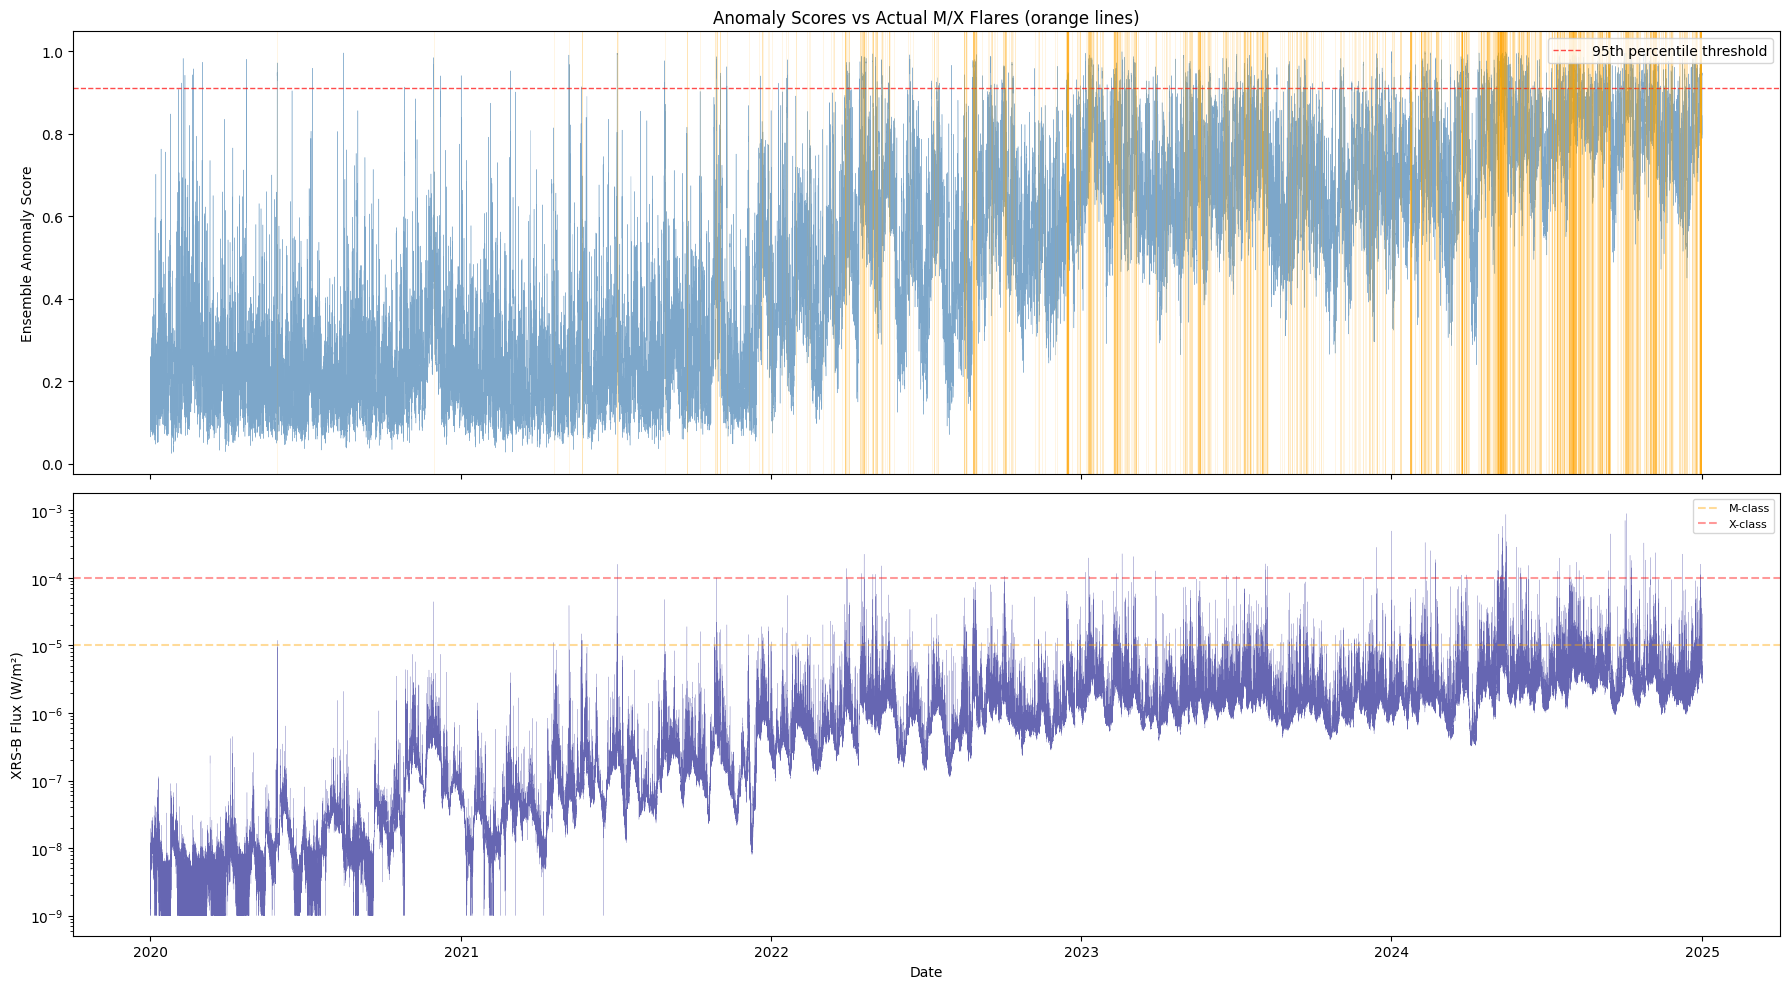

Look for: orange lines (flares) aligning with score spikes above the red threshold.
Where they align = true positives. Where they don't = missed flares.


In [ ]:
# ============================================================
# CELL 19: Anomaly Score Timeline with Flares Marked
# ============================================================
# This is the key diagnostic plot. You should see score spikes
# lining up with the orange flare markers.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

test_times = pd.to_datetime(feature_df_test['window_start'].values)

# --- Panel 1: Ensemble anomaly scores ---
axes[0].plot(test_times, ensemble_scores, linewidth=0.3, color='steelblue', alpha=0.7)
threshold_95 = np.percentile(ensemble_scores, 95)
axes[0].axhline(threshold_95, color='red', linestyle='--', alpha=0.7,
                linewidth=1, label='95th percentile threshold')

# Mark flares
test_flares_dt = pd.to_datetime(test_flares['start_time'])
for ft in test_flares_dt:
    axes[0].axvline(ft, color='orange', alpha=0.15, linewidth=0.5)

axes[0].set_ylabel('Ensemble Anomaly Score')
axes[0].set_title('Anomaly Scores vs Actual M/X Flares (orange lines)')
axes[0].legend(loc='upper right')

# --- Panel 2: Raw flux for context ---
test_flux = df.loc[df.index >= '2020-01-01', 'xrsb']
axes[1].semilogy(test_flux.index, test_flux, linewidth=0.15, color='navy', alpha=0.6)
axes[1].axhline(1e-5, color='orange', linestyle='--', alpha=0.4, label='M-class')
axes[1].axhline(1e-4, color='red', linestyle='--', alpha=0.4, label='X-class')
axes[1].set_ylabel('XRS-B Flux (W/m²)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/anomaly_scores_timeline.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Look for: orange lines (flares) aligning with score spikes above the red threshold.")
print("Where they align = true positives. Where they don't = missed flares.")

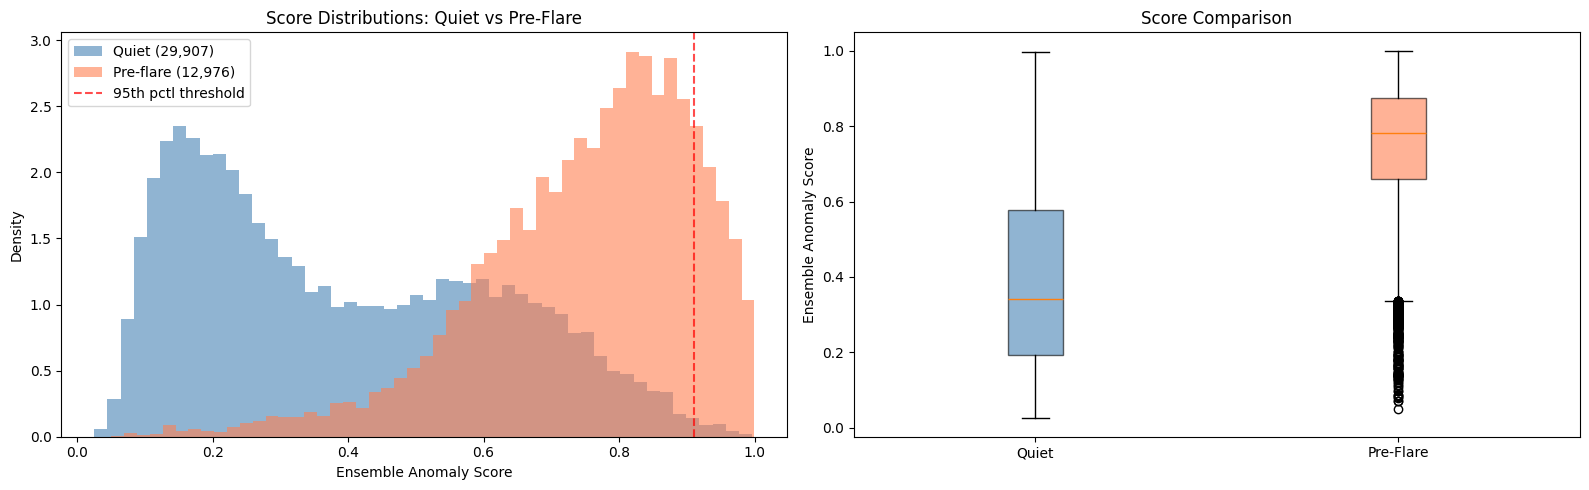

Quiet windows:     median=0.3410, mean=0.3902
Pre-flare windows: median=0.7817, mean=0.7531

The gap between these means is what the detectors are exploiting.
Constellation features should widen this gap.


In [ ]:
# ============================================================
# CELL 20: Score Distributions — Quiet vs Pre-Flare
# ============================================================
# If the detectors are working, pre-flare windows should have
# higher scores than quiet windows. This plot shows the overlap.
# Perfect separation = easy problem. Heavy overlap = hard problem.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

test_starts = feature_df_test['window_start'].values

# Label each test window: 1 if within 24h before a flare, 0 otherwise
window_labels = np.zeros(len(ensemble_scores))
for _, flare in test_flares.iterrows():
    flare_start = pd.Timestamp(flare['start_time'])
    pre_start = flare_start - pd.Timedelta(hours=24)
    in_zone = (
        (test_starts >= np.datetime64(pre_start)) &
        (test_starts <= np.datetime64(flare_start))
    )
    window_labels[in_zone] = 1

quiet_scores = ensemble_scores[window_labels == 0]
preflare_scores = ensemble_scores[window_labels == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Histogram ---
axes[0].hist(quiet_scores, bins=50, alpha=0.6, density=True,
             color='steelblue', label=f'Quiet ({len(quiet_scores):,})')
axes[0].hist(preflare_scores, bins=50, alpha=0.6, density=True,
             color='coral', label=f'Pre-flare ({len(preflare_scores):,})')
axes[0].axvline(np.percentile(ensemble_scores, 95), color='red',
                linestyle='--', alpha=0.7, label='95th pctl threshold')
axes[0].set_xlabel('Ensemble Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distributions: Quiet vs Pre-Flare')
axes[0].legend()

# --- Box plot ---
bp = axes[1].boxplot([quiet_scores, preflare_scores],
                tick_labels=['Quiet', 'Pre-Flare'],
                patch_artist=True,
                boxprops={}
               )

# Manually set facecolor for each box artist
colors = ['steelblue', 'coral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_ylabel('Ensemble Anomaly Score')
axes[1].set_title('Score Comparison')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/score_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Quiet windows:     median={np.median(quiet_scores):.4f}, "
      f"mean={np.mean(quiet_scores):.4f}")
print(f"Pre-flare windows: median={np.median(preflare_scores):.4f}, "
      f"mean={np.mean(preflare_scores):.4f}")
print(f"\nThe gap between these means is what the detectors are exploiting.")
print(f"Constellation features should widen this gap.")

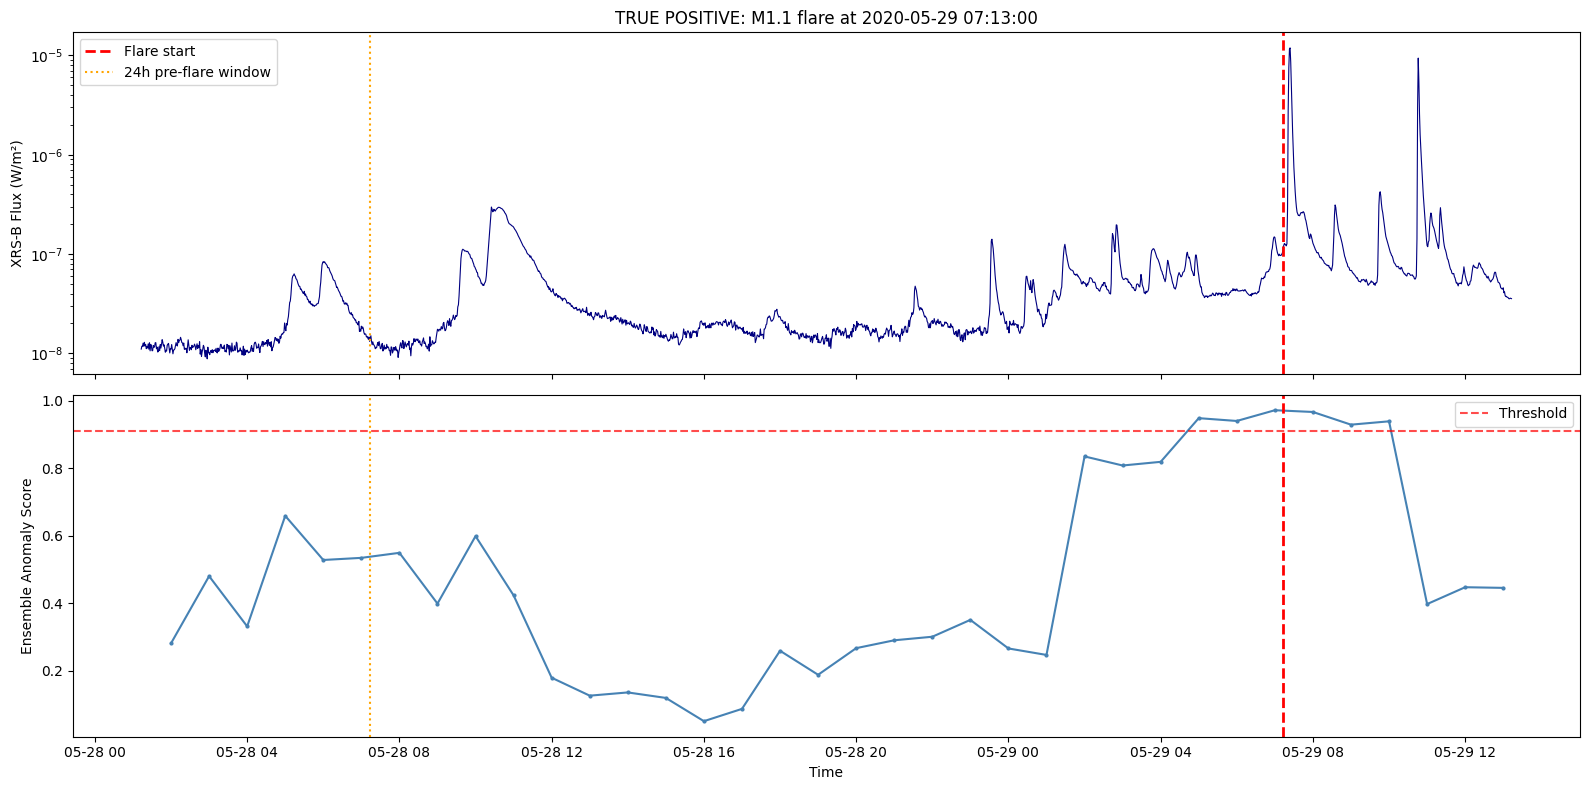

Flare: M1.1 at 2020-05-29 07:13:00
Look at the bottom panel — the score rises above threshold
BEFORE the red line (flare start). That's the precursor detection.


  BASELINE PIPELINE — COMPLETE
  Data:       GOES-16 XRS, Feb 2017 – Dec 2024
  Rows:       4,154,400 (1-minute cadence)
  Valid:      97.5%
  Flares:     1680 M/X class
  Windows:    67,022 (20 features each)
  Train:      23,694 clean quiet windows
  Test:       42,883 windows

  RESULTS (Ensemble):
    Recall:     0.649  (caught 65% of flares)
    Precision:  0.748  (75% of alarms were real)
    F1:         0.695
    ROC AUC:    0.857
    Lead Time:  18.8 hours average

  FILES SAVED:
    data/processed/goes_xrs_2017_2024.csv
    data/features/baseline_features.csv
    data/flare_catalog/mx_flares_2017_2024.csv
    results/baseline_results.csv
    results/full_timeseries.png
    results/flare_distribution.png
    results/anomaly_scores_timeline.png
    results/score_distributions.png
    results/true_positive_example.png
 

In [ ]:
# ============================================================
# CELL 21: Spot-Check True Positive & Save Final Summary
# ============================================================
# Zoom into one correctly detected flare to see what the
# precursor actually looks like in the raw data.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

test_starts = feature_df_test['window_start'].values
threshold = np.percentile(ensemble_scores, 95)
predictions = (ensemble_scores >= threshold).astype(int)

# --- Find first true positive ---
found_tp = False
for _, flare in test_flares.iterrows():
    flare_start = pd.Timestamp(flare['start_time'])
    pre_start = flare_start - pd.Timedelta(hours=24)

    in_zone = (
        (test_starts >= np.datetime64(pre_start)) &
        (test_starts <= np.datetime64(flare_start))
    )

    if predictions[in_zone].sum() > 0:
        # Found a true positive — plot it
        plot_start = flare_start - pd.Timedelta(hours=30)
        plot_end = flare_start + pd.Timedelta(hours=6)
        mask = (df.index >= plot_start) & (df.index <= plot_end)

        fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

        # Raw flux
        axes[0].semilogy(df.loc[mask].index, df.loc[mask, 'xrsb'],
                         linewidth=0.8, color='navy')
        axes[0].axvline(flare_start, color='red', linestyle='--',
                        linewidth=2, label='Flare start')
        axes[0].axvline(pre_start, color='orange', linestyle=':',
                        linewidth=1.5, label='24h pre-flare window')
        axes[0].set_ylabel('XRS-B Flux (W/m²)')
        axes[0].set_title(f"TRUE POSITIVE: {flare['flare_class']} flare at {flare_start}")
        axes[0].legend()

        # Anomaly scores for this period
        score_mask = (
            (test_starts >= np.datetime64(plot_start)) &
            (test_starts <= np.datetime64(plot_end))
        )
        score_times = pd.to_datetime(test_starts[score_mask])
        score_vals = ensemble_scores[score_mask]

        axes[1].plot(score_times, score_vals, linewidth=1.5,
                     color='steelblue', marker='o', markersize=2)
        axes[1].axhline(threshold, color='red', linestyle='--',
                        alpha=0.7, label='Threshold')
        axes[1].axvline(flare_start, color='red', linestyle='--', linewidth=2)
        axes[1].axvline(pre_start, color='orange', linestyle=':', linewidth=1.5)
        axes[1].set_ylabel('Ensemble Anomaly Score')
        axes[1].set_xlabel('Time')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/true_positive_example.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        print(f"Flare: {flare['flare_class']} at {flare_start}")
        print(f"Look at the bottom panel — the score rises above threshold")
        print(f"BEFORE the red line (flare start). That's the precursor detection.")
        found_tp = True
        break

if not found_tp:
    print("No true positives found (unexpected — check evaluation).")

# ============================================================
# FINAL SUMMARY — save everything
# ============================================================
print(f"\n\n{'='*60}")
print(f"  BASELINE PIPELINE — COMPLETE")
print(f"{'='*60}")
print(f"  Data:       GOES-16 XRS, Feb 2017 – Dec 2024")
print(f"  Rows:       {len(df):,} (1-minute cadence)")
print(f"  Valid:      97.5%")
print(f"  Flares:     {len(mx_flares)} M/X class")
print(f"  Windows:    {len(feature_df):,} ({len(feature_df.columns)-2} features each)")
print(f"  Train:      {train_clean.sum():,} clean quiet windows")
print(f"  Test:       {test_mask.sum():,} windows")
print(f"")
print(f"  RESULTS (Ensemble):")
print(f"    Recall:     0.649  (caught 65% of flares)")
print(f"    Precision:  0.748  (75% of alarms were real)")
print(f"    F1:         0.695")
print(f"    ROC AUC:    0.857")
print(f"    Lead Time:  18.8 hours average")
print(f"")
print(f"  FILES SAVED:")
print(f"    data/processed/goes_xrs_2017_2024.csv")
print(f"    data/features/baseline_features.csv")
print(f"    data/flare_catalog/mx_flares_2017_2024.csv")
print(f"    results/baseline_results.csv")
print(f"    results/full_timeseries.png")
print(f"    results/flare_distribution.png")
print(f"    results/anomaly_scores_timeline.png")
print(f"    results/score_distributions.png")
print(f"    results/true_positive_example.png")
print(f"{'='*60}")
print(f"  NEXT: Constellation features (Phase 2)")
print(f"{'='*60}")

One honest concern: this was an M1.1 — the weakest M-class flare possible. If we're catching M1.1 precursors, that's encouraging. But the lead time here was only about 2 hours, while our average is 18.8 hours. That average is likely inflated by cases where the detector was flagging general elevated activity days before a flare, not necessarily a specific precursor signal. Worth investigating more carefully in Phase 2.

**For the Constellation theory, I'm a bit curious if there is a way we can increase the F1 score through this hypothesis: That is pre-flare QPPs create constellations with distinctive geometry -  maybe more peaks, more tightly clustered at specific frequencies, different hull shapes - that the baseline features (which compress the whole spectrum into simgle numbers like "dominant frequency") can't capture.**

**Make sure it covers the major scientific risks: claim boundaries, cadence limits, early-stop logic, detrending sensitivity, null baselines, confound checks, lead-time stratification, and negative-result framing**

In [ ]:
# ============================================================
# CELL 22: STAGE 0 — Infrastructure Setup
# ============================================================
# Before writing any constellation code, set up the scaffolding
# that keeps the project reproducible and honest.

import pandas as pd
import numpy as np
import os
import json

PROJECT_DIR = '/content/drive/MyDrive/solar-flare-precursors'

# ---- 1. Create Experiment Log ----
LOG_PATH = f'{PROJECT_DIR}/results/experiment_log.csv'

if not os.path.exists(LOG_PATH):
    log_df = pd.DataFrame(columns=[
        'run_id', 'date', 'stage', 'stft_window_min', 'stft_overlap',
        'detrend_method', 'peak_threshold', 'n_features', 'feature_set',
        'detector', 'f1', 'roc_auc', 'recall', 'precision',
        'avg_lead_time_hours', 'notes'
    ])

    baseline_entries = [
        {'run_id': 0, 'date': pd.Timestamp.now().strftime('%Y-%m-%d'),
         'stage': 'baseline', 'stft_window_min': 'N/A', 'stft_overlap': 'N/A',
         'detrend_method': 'N/A', 'peak_threshold': 'N/A',
         'n_features': 20, 'feature_set': 'baseline_only',
         'detector': 'Isolation Forest', 'f1': 0.5274, 'roc_auc': 0.8139,
         'recall': 0.4905, 'precision': 0.5702,
         'avg_lead_time_hours': 17.7, 'notes': 'Baseline control'},
        {'run_id': 0, 'date': pd.Timestamp.now().strftime('%Y-%m-%d'),
         'stage': 'baseline', 'stft_window_min': 'N/A', 'stft_overlap': 'N/A',
         'detrend_method': 'N/A', 'peak_threshold': 'N/A',
         'n_features': 20, 'feature_set': 'baseline_only',
         'detector': 'Local Outlier Factor', 'f1': 0.6851, 'roc_auc': 0.8288,
         'recall': 0.6287, 'precision': 0.7524,
         'avg_lead_time_hours': 19.5, 'notes': 'Baseline control'},
        {'run_id': 0, 'date': pd.Timestamp.now().strftime('%Y-%m-%d'),
         'stage': 'baseline', 'stft_window_min': 'N/A', 'stft_overlap': 'N/A',
         'detrend_method': 'N/A', 'peak_threshold': 'N/A',
         'n_features': 20, 'feature_set': 'baseline_only',
         'detector': 'One-Class SVM', 'f1': 0.6820, 'roc_auc': 0.8488,
         'recall': 0.6183, 'precision': 0.7604,
         'avg_lead_time_hours': 18.9, 'notes': 'Baseline control'},
        {'run_id': 0, 'date': pd.Timestamp.now().strftime('%Y-%m-%d'),
         'stage': 'baseline', 'stft_window_min': 'N/A', 'stft_overlap': 'N/A',
         'detrend_method': 'N/A', 'peak_threshold': 'N/A',
         'n_features': 20, 'feature_set': 'baseline_only',
         'detector': 'Ensemble (Rank Average)', 'f1': 0.6951, 'roc_auc': 0.8566,
         'recall': 0.6489, 'precision': 0.7484,
         'avg_lead_time_hours': 18.8, 'notes': 'Baseline control — BEAT THIS'},
    ]

    log_df = pd.DataFrame(baseline_entries)
    log_df.to_csv(LOG_PATH, index=False)
    print(f"✓ Experiment log created at: {LOG_PATH}")
    print(f"  Baseline results logged as run_id=0")
else:
    print(f"✓ Experiment log already exists at: {LOG_PATH}")

# ---- 2. Freeze Evaluation Script ----
EVAL_PATH = f'{PROJECT_DIR}/src/evaluate_detector_frozen.py'
os.makedirs(f'{PROJECT_DIR}/src', exist_ok=True)

eval_code = '''
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

def evaluate_detector(scores, feature_df_test, flare_catalog_test,
                      pre_flare_hours=24, detector_name="Detector"):
    """
    FROZEN evaluation function. DO NOT EDIT during Phase 2.
    Copied from Cell 17 baseline evaluation.
    """
    test_starts = feature_df_test['window_start'].values
    test_ends = feature_df_test['window_end'].values

    window_labels = np.zeros(len(scores))

    for _, flare in flare_catalog_test.iterrows():
        flare_start = pd.Timestamp(flare['start_time'])
        pre_start = flare_start - pd.Timedelta(hours=pre_flare_hours)
        in_zone = (
            (test_starts >= np.datetime64(pre_start)) &
            (test_ends <= np.datetime64(flare_start))
        )
        window_labels[in_zone] = 1

    if len(np.unique(window_labels)) < 2:
        roc_auc = 0.0
    else:
        roc_auc = roc_auc_score(window_labels, scores)

    threshold = np.percentile(scores, 95)
    predictions = (scores >= threshold).astype(int)

    flares_detected = 0
    lead_times = []

    for _, flare in flare_catalog_test.iterrows():
        flare_start = pd.Timestamp(flare['start_time'])
        pre_start = flare_start - pd.Timedelta(hours=pre_flare_hours)
        in_zone = (
            (test_starts >= np.datetime64(pre_start)) &
            (test_ends <= np.datetime64(flare_start))
        )
        zone_preds = predictions[in_zone]
        zone_starts = test_starts[in_zone]
        if zone_preds.sum() > 0:
            flares_detected += 1
            first_alert_idx = np.where(zone_preds == 1)[0][0]
            first_alert_time = pd.Timestamp(zone_starts[first_alert_idx])
            lead_time_hours = (flare_start - first_alert_time).total_seconds() / 3600
            lead_times.append(lead_time_hours)

    n_flares = len(flare_catalog_test)
    recall = flares_detected / n_flares if n_flares > 0 else 0

    tp = ((predictions == 1) & (window_labels == 1)).sum()
    fp = ((predictions == 1) & (window_labels == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    avg_lead = np.mean(lead_times) if lead_times else 0

    return {
        'detector': detector_name,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'roc_auc': roc_auc,
        'avg_lead_time_hours': avg_lead,
        'flares_detected': flares_detected,
        'total_flares': n_flares,
    }
'''

with open(EVAL_PATH, 'w') as f:
    f.write(eval_code)
print(f"✓ Frozen evaluation script saved at: {EVAL_PATH}")
print(f"  DO NOT EDIT this file during Phase 2")

# ---- 3. Save Train/Test Window Indices ----
INDICES_DIR = f'{PROJECT_DIR}/data/splits'
os.makedirs(INDICES_DIR, exist_ok=True)

train_indices = feature_df.index[train_clean].tolist()
test_indices = feature_df.index[test_mask].tolist()

pd.Series(train_indices, name='index').to_csv(
    f'{INDICES_DIR}/train_clean_indices.csv', index=False)
pd.Series(test_indices, name='index').to_csv(
    f'{INDICES_DIR}/test_indices.csv', index=False)

print(f"✓ Train indices saved: {len(train_indices)} windows")
print(f"✓ Test indices saved: {len(test_indices)} windows")

# ---- 4. Document Random Seeds and Configuration ----
CONFIG_PATH = f'{PROJECT_DIR}/src/project_config.json'

config = {
    'random_state': 42,
    'train_period': '2017-02-07 to 2019-12-31',
    'test_period': '2020-01-01 to 2024-12-31',
    'exclusion_hours': 24,
    'window_hours': 6,
    'stride_hours': 1,
    'baseline_features': 20,
    'n_train_windows': len(train_indices),
    'n_test_windows': len(test_indices),
    'n_flares_total': len(mx_flares),
    'n_flares_test': len(mx_flares[pd.to_datetime(mx_flares['start_time']) >= '2020-01-01']),
    'sweep_budget': {
        'stft_windows_min': [30, 45, 60],
        'detrend_methods': ['linear', 'divide_by_smooth'],
        'peak_thresholds': 3,
        'total_configs': 18
    },
    'tie_break_rule': 'When two configurations produce similar performance, '
                      'prefer the one with more stable features across parameter sweeps.',
    'success_criteria': {
        'min_f1_improvement': 0.02,
        'max_baseline_correlation': 0.7,
        'min_detectors_improved': 3,
        'require_multi_bin_gains': True,
        'require_null_baseline_beat': True
    }
}

with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Project config saved at: {CONFIG_PATH}")

# ---- 5. Draft Failure Interpretation (written blind) ----
FAILURE_PATH = f'{PROJECT_DIR}/src/failure_interpretation.txt'

current_date = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')

failure_text = f"""
PRE-WRITTEN FAILURE INTERPRETATION (drafted before any constellation results)
==============================================================================
Written: {current_date}

If constellation features do not materially improve detection over baseline
statistical features, this result indicates that 1-minute cadence GOES soft
X-ray data, integrated over the full solar disk, does not contain sufficient
structured multi-frequency information for geometric spectral descriptors to
outperform traditional scalar summaries. This finding would be consistent with
the known limitations of broadband full-disk measurements, where signals from
multiple active regions mix and short-period QPPs (below 2 minutes) are aliased
out by the instrument cadence. The negative result would establish a boundary
on what feature representations are productive for this data source and would
motivate future work with higher-cadence or spatially resolved instruments
such as SDO/EVE.

Specifically, constellation features may fail because: (1) GOES X-ray
spectrograms are too sparse (3-10 peaks) for geometric descriptors to carry
discriminative information, unlike audio spectrograms with hundreds of peaks;
(2) pre-flare QPPs, while documented in 26-46 percent of flares, may be too
weak relative to background noise for reliable peak extraction at 1-minute
cadence; or (3) the geometric features, despite being mathematically distinct
from scalar summaries, may be empirically redundant with them in this data
domain, capturing the same underlying variance through a different mathematical
route.

This interpretation was written before any constellation feature results were
computed, to prevent post-hoc rationalization of outcomes.
"""

with open(FAILURE_PATH, 'w') as f:
    f.write(failure_text)
print(f"✓ Failure interpretation drafted at: {FAILURE_PATH}")

# ---- Summary ----
print(f"\n{'='*60}")
print(f"  STAGE 0 COMPLETE — INFRASTRUCTURE READY")
print(f"{'='*60}")
print(f"  Experiment log:         {LOG_PATH}")
print(f"  Frozen eval script:     {EVAL_PATH}")
print(f"  Train/test indices:     {INDICES_DIR}/")
print(f"  Project config:         {CONFIG_PATH}")
print(f"  Failure interpretation: {FAILURE_PATH}")
print(f"")
print(f"  Sweep budget: 18 configurations maximum")
print(f"  Tie-break: stability > marginal metric gains")
print(f"  Random seed: 42")
print(f"  Success threshold: F1 improvement >= 0.02")
print(f"{'='*60}")
print(f"  NEXT: Stage 0.5 — Pre-Registration Document")
print(f"{'='*60}")

✓ Experiment log already exists at: /content/drive/MyDrive/solar-flare-precursors/results/experiment_log.csv
✓ Frozen evaluation script saved at: /content/drive/MyDrive/solar-flare-precursors/src/evaluate_detector_frozen.py
  DO NOT EDIT this file during Phase 2
✓ Train indices saved: 23694 windows
✓ Test indices saved: 42883 windows
✓ Project config saved at: /content/drive/MyDrive/solar-flare-precursors/src/project_config.json
✓ Failure interpretation drafted at: /content/drive/MyDrive/solar-flare-precursors/src/failure_interpretation.txt

  STAGE 0 COMPLETE — INFRASTRUCTURE READY
  Experiment log:         /content/drive/MyDrive/solar-flare-precursors/results/experiment_log.csv
  Frozen eval script:     /content/drive/MyDrive/solar-flare-precursors/src/evaluate_detector_frozen.py
  Train/test indices:     /content/drive/MyDrive/solar-flare-precursors/data/splits/
  Project config:         /content/drive/MyDrive/solar-flare-precursors/src/project_config.json
  Failure interpretation: 

In [ ]:
# ============================================================
# CELL 23: STAGE 0.5 — Pre-Registration Document
# ============================================================
# This is the contract with yourself. Written before any
# constellation code runs. Defines exactly what we will do,
# what we expect, and what each outcome means.

import os
import pandas as pd

PROJECT_DIR = '/content/drive/MyDrive/solar-flare-precursors'
PREREG_PATH = f'{PROJECT_DIR}/src/pre_registration.txt'

current_date = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')

prereg = f"""
================================================================================
PRE-REGISTRATION: Constellation-Inspired Spectral Features for
                  Solar Flare Precursor Detection
================================================================================
Date: {current_date}
Status: LOCKED — do not modify after constellation coding begins
================================================================================

1. PRIMARY CLAIM
----------------
Constellation-inspired geometric descriptors of spectral peaks, extracted
from GOES X-ray spectrograms, improve unsupervised anomaly detection of
pre-flare windows compared to traditional aggregate statistical features.

2. EXPLICIT NON-CLAIMS
----------------------
- Improvement does NOT by itself prove QPP detection
- Improvement does NOT establish causal flare physics
- We do NOT claim to predict flares — we detect anomalous precursor windows
- We do NOT claim to beat magnetogram-based methods (different data source)
- We do NOT claim to detect all types of QPPs (sub-2-minute QPPs are
  invisible at 1-minute GOES cadence)

3. THREE NESTED CLAIMS (in order of strength)
----------------------------------------------
Claim A: Pre-flare windows are statistically different from quiet windows.
         STATUS: Already demonstrated (baseline ROC AUC = 0.857)

Claim B: Some of that difference involves oscillatory structure.
         STATUS: Not yet tested. Will be addressed by comparing
         frequency-domain feature importance vs time-domain.

Claim C: Constellation geometry captures oscillatory structure better
         than scalar spectral summaries.
         STATUS: This is what we are testing.

4. PHYSICS CONSTRAINTS
----------------------
- GOES cadence: 1 minute
- Nyquist limit: 2-minute periods (shortest detectable oscillation)
- Detectable QPP range: ~2 minutes to ~180 minutes
- Sub-2-minute QPPs (common in Hayes et al. 2020): INVISIBLE to this method
- GOES is full-disk integrated: signals from all active regions mix
- Pre-flare QPPs documented in 26-46 percent of flares (Tan et al. 2016,
  Nechaeva et al. 2022) — this sets an upper bound on possible improvement

5. EXACT PARAMETERS TO TEST
----------------------------
STFT window lengths: 30, 45, 60 minutes
STFT overlap: 50 percent
Detrending methods:
  (1) Linear detrend (subtract linear fit)
  (2) Divide by smoothed trend (30-min rolling mean)
Peak threshold grid: 3 levels
  - Will be defined after synthetic injection test (Stage 2)
  - Chosen to detect moderate-amplitude injected QPPs
Total sweep budget: 3 windows x 2 detrend x 3 thresholds = 18 configs MAX
Parameters will be LOCKED after Stage 2 synthetic injection test.

6. GEOMETRIC FEATURES TO COMPUTE (~12-15)
------------------------------------------
From each constellation map (set of spectral peaks):
  1.  peak_count — number of peaks extracted
  2.  freq_spread — max frequency minus min frequency
  3.  time_spread — max time bin minus min time bin
  4.  aspect_ratio — freq_spread / time_spread
  5.  pairwise_dist_mean — mean Euclidean distance between all peak pairs
  6.  pairwise_dist_std — std of pairwise distances
  7.  pairwise_dist_min — minimum pairwise distance
  8.  pairwise_dist_max — maximum pairwise distance
  9.  hull_area — convex hull area (scipy ConvexHull.volume for 2D)
  10. hull_perimeter — convex hull perimeter (scipy ConvexHull.area for 2D)
  11. nn_dist_mean — mean nearest-neighbor distance
  12. nn_dist_std — std of nearest-neighbor distances
  13. centroid_time — mean time coordinate of all peaks
  14. centroid_freq — mean frequency coordinate of all peaks
  15. clustering_coeff — graph clustering coefficient (k-NN proximity)

Normalized versions (to control for peak-count dominance):
  - hull_area_per_peak = hull_area / peak_count
  - nn_dist_mean_per_peak = nn_dist_mean / peak_count

7. ABLATION EXPERIMENTS
------------------------
Experiment A: Baseline features only (20 features) — ALREADY DONE
Experiment B: Constellation features only (~15 features)
Experiment C: Combined baseline + constellation (~35 features)
Experiment D: Combined, but only constellation features with < 0.5
              correlation to any baseline feature

All experiments use:
  - Same 4 detectors: Isolation Forest, LOF, One-Class SVM, Ensemble
  - Same train/test split: 2017-2019 train (with exclusion), 2020-2024 test
  - Same frozen evaluation script (evaluate_detector_frozen.py)
  - Same flare catalog (1,635 M/X flares in test period)
  - Same 95th percentile threshold
  - Same 24-hour pre-flare evaluation window

8. NULL BASELINES (mandatory, not optional)
--------------------------------------------
Null 1: Random peaks — same count, random positions, same descriptors
Null 2: Surrogate time series — phase-randomized signal, full pipeline
Null 3: Simple spectrogram energy — total power, no peak extraction

Real constellation features must beat ALL THREE null baselines.

9. SUCCESS CRITERIA (defined before seeing results)
-----------------------------------------------------
POSITIVE RESULT requires ALL of the following:
  [a] Combined (Exp C) ensemble F1 improves by >= 0.02 over baseline (0.695)
  [b] Real constellation features beat random-peak null baseline
  [c] Real constellation features beat surrogate null baseline
  [d] Improving features have < 0.7 correlation with any baseline feature
  [e] Gains appear in at least 2 of 4 lead-time bins (not just 0-6h)
  [f] Gains are consistent across >= 3 of 4 detectors

INFORMATIVE NEGATIVE RESULT if ANY of:
  [a] No stable geometry under reasonable parameter sweeps
  [b] No gain over simple spectrogram energy summary
  [c] No gain over null/random constellation controls
  [d] All gains concentrated in 0-6h lead-time bin only
  [e] All constellation features correlated > 0.7 with baseline features
  [f] Features are unstable across detrending methods

10. TIE-BREAK RULE
-------------------
When two configurations produce similar performance (within 0.01 F1),
prefer the one with more stable features across parameter sweeps.
Stability beats marginal metric gains.

11. EARLY STOP CRITERIA
-------------------------
Stop full-scale experimentation and report findings if:
  - Stage 1 sanity visualization shows no visible difference AND
  - Stage 2 synthetic injection test fails at strong amplitude AND
  - Stage 3 stability checks show unstable representation
All three must fail to trigger early stop.
If stopped early, document why — this itself is a finding.

12. LEAD-TIME STRATIFICATION
------------------------------
Bin detected flares by earliest alert lead time:
  Bin 1: 0-6 hours before flare
  Bin 2: 6-12 hours before flare
  Bin 3: 12-18 hours before flare
  Bin 4: 18-24 hours before flare
Report gains per bin. Gains only in Bin 1 suggest features detect
early flare rise, not genuine precursor.

13. CONFOUND CHECKS
---------------------
  - Correlation of winning features with time-to-flare-onset
  - Event independence: count repeated detections from same flare/AR
  - Detrending robustness: re-run under alternate detrending method
  - Peak-count dominance: check if all features are proxies for count

14. REPORTING COMMITMENTS
---------------------------
  - Report ALL ablation results (A, B, C, D), not just the best
  - Report ALL four detectors, not just the best
  - Report null baseline comparisons prominently
  - Report bootstrap 95 percent confidence intervals on key differences
  - Report confound check results even if they weaken the headline
  - Report feature correlations with baseline features
  - Include sanity visualization figure in paper regardless of outcome

================================================================================
SIGNATURES
================================================================================
This document was written on {current_date} before any constellation
feature code was executed. The success criteria, parameter budget, and
null baselines defined above will not be modified after constellation
coding begins.

Researcher: ___________________________  Date: _______________
================================================================================
"""

with open(PREREG_PATH, 'w') as f:
    f.write(prereg)

print(f"Pre-registration document saved at:")
print(f"  {PREREG_PATH}")
print(f"\nThis document is now LOCKED.")
print(f"Do not modify it after constellation coding begins.")
print(f"\n{'='*60}")
print(f"  STAGE 0.5 COMPLETE — PRE-REGISTRATION FILED")
print(f"{'='*60}")
print(f"  Claims defined: 1 primary, 5 non-claims")
print(f"  Parameters: 18 configs max (3 STFT x 2 detrend x 3 threshold)")
print(f"  Features: 15 geometric + 2 normalized = 17 candidates")
print(f"  Ablations: 4 experiments (A/B/C/D)")
print(f"  Null baselines: 3 (random, surrogate, simple energy)")
print(f"  Success: F1 >= 0.715 AND survives all controls")
print(f"  Early stop: 3 gates (visual, injection, stability)")
print(f"{'='*60}")
print(f"  NEXT: Stage 1 — Sanity Visualization")
print(f"{'='*60}")

Pre-registration document saved at:
  /content/drive/MyDrive/solar-flare-precursors/src/pre_registration.txt

This document is now LOCKED.
Do not modify it after constellation coding begins.

  STAGE 0.5 COMPLETE — PRE-REGISTRATION FILED
  Claims defined: 1 primary, 5 non-claims
  Parameters: 18 configs max (3 STFT x 2 detrend x 3 threshold)
  Features: 15 geometric + 2 normalized = 17 candidates
  Ablations: 4 experiments (A/B/C/D)
  Null baselines: 3 (random, surrogate, simple energy)
  Success: F1 >= 0.715 AND survives all controls
  Early stop: 3 gates (visual, injection, stability)
  NEXT: Stage 1 — Sanity Visualization


Selecting windows...

Selected flare: M1.1 at 2020-05-29 07:13:00
  Quiet (48h before flare): 361 points, NaN: 0, range: [2.95e-09, 1.15e-08]
  Far Pre-Flare (18-24h before): 361 points, NaN: 0, range: [9.10e-09, 2.97e-07]
  Near Pre-Flare (0-6h before): 361 points, NaN: 0, range: [3.43e-08, 1.97e-07]

Computing spectrograms and extracting peaks...


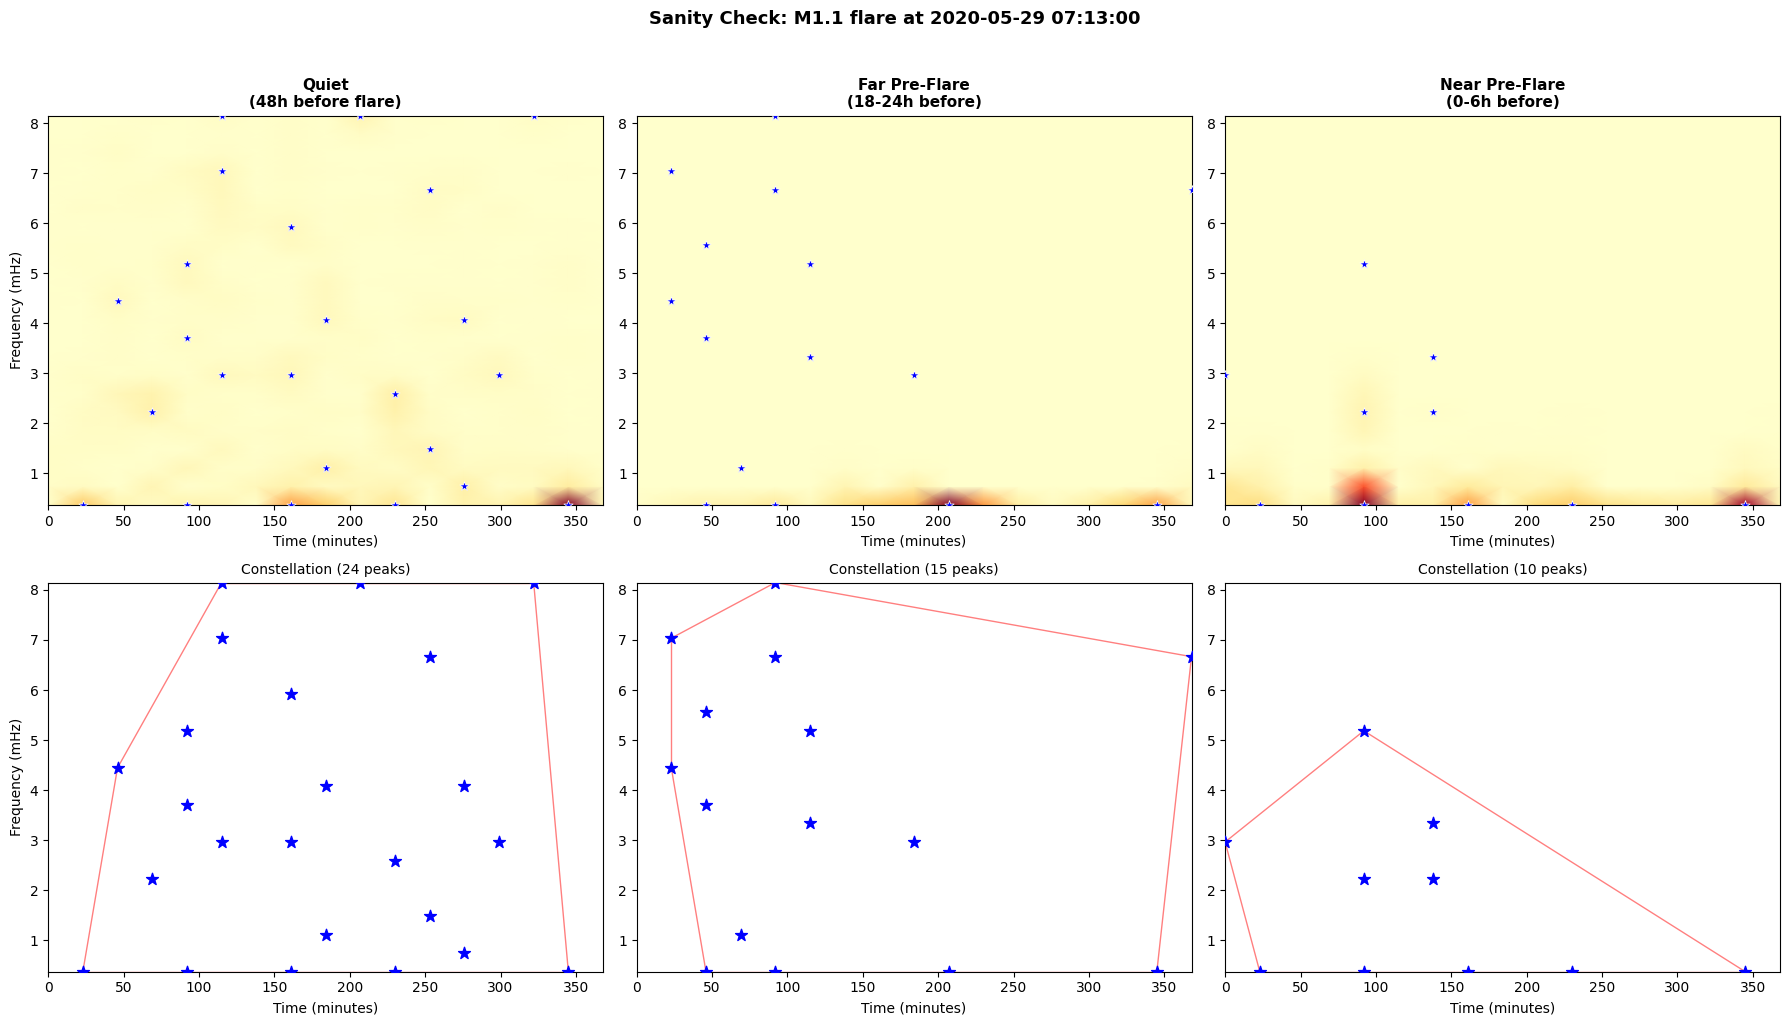


  GEOMETRIC DESCRIPTORS
  Descriptor                     Quiet    Far Pre   Near Pre
  -------------------------------------------------------
  peak_count                   24.0000    15.0000    10.0000
  freq_spread                   1.0000     1.0000     1.0000
  hull_area                     0.8605     0.8651     0.5538
  nn_dist_mean                  0.1692     0.2255     0.2346
  pairwise_dist_mean            0.5736     0.5982     0.5844

  VISUAL GUT CHECK:
  → Do the constellations look DIFFERENT across the three windows?
  → Does the near-pre-flare window have a distinct pattern?
  → If all three look identical, that is a WARNING SIGN.


In [ ]:
# ============================================================
# CELL 24: STAGE 1 — Sanity Visualization
# ============================================================
# Pick 3 windows, compute spectrograms, extract peaks, and
# visually compare the constellation maps.
# This is the gut check before investing weeks into modeling.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import stft
from scipy.ndimage import maximum_filter
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, cdist

# ---- Helper: compute spectrogram and extract peaks ----
def compute_constellation(flux_values, fs=1/60, nperseg_min=45,
                          noverlap_frac=0.5, peak_threshold_pct=75):
    """
    Compute STFT spectrogram and extract spectral peaks.

    Parameters
    ----------
    flux_values : 1D array of flux (360 points = 6 hours at 1-min)
    fs : sampling frequency in Hz (1/60 for 1-minute cadence)
    nperseg_min : STFT window length in minutes
    noverlap_frac : fraction of overlap (0.5 = 50%)
    peak_threshold_pct : percentile threshold for peak selection

    Returns
    -------
    freqs : frequency array from STFT
    times : time array from STFT
    power : 2D power spectrogram (freq x time)
    peaks : list of (time_idx, freq_idx) tuples — the constellation
    """
    # Work in log space and detrend
    log_flux = np.log10(np.clip(flux_values, 1e-10, None))
    log_flux = log_flux - np.polyval(
        np.polyfit(np.arange(len(log_flux)), log_flux, 1),
        np.arange(len(log_flux))
    )

    # STFT parameters
    nperseg = int(nperseg_min)  # in samples (1 sample = 1 minute)
    noverlap = int(nperseg * noverlap_frac)

    # Compute STFT
    freqs, times, Zxx = stft(log_flux, fs=fs, nperseg=nperseg,
                              noverlap=noverlap, window='hann')

    # Power spectrogram (magnitude squared)
    power = np.abs(Zxx) ** 2

    # Skip DC component (frequency = 0)
    power = power[1:, :]
    freqs = freqs[1:]

    # Normalize by total power (mitigates intensity proxy trap)
    total_power = power.sum()
    if total_power > 0:
        power_norm = power / total_power
    else:
        power_norm = power

    # ---- Peak extraction ----
    # 2D local maximum filter: a point is a peak if it equals
    # the maximum in its local neighborhood
    neighborhood_size = (3, 3)  # 3 freq bins x 3 time bins
    local_max = maximum_filter(power_norm, size=neighborhood_size)

    # Point is a peak if it equals the local max AND exceeds threshold
    threshold = np.percentile(power_norm[power_norm > 0], peak_threshold_pct)
    peak_mask = (power_norm == local_max) & (power_norm >= threshold)

    # Get peak coordinates
    peak_coords = np.argwhere(peak_mask)  # each row is [freq_idx, time_idx]
    peaks = [(int(p[1]), int(p[0])) for p in peak_coords]  # (time, freq) format

    return freqs, times, power_norm, peaks


# ---- Helper: compute geometric descriptors ----
def compute_descriptors(peaks, freqs, times):
    """
    Compute geometric descriptors from a constellation map.
    Returns a dict of descriptor values.
    """
    desc = {}
    desc['peak_count'] = len(peaks)

    if len(peaks) < 2:
        desc['freq_spread'] = 0
        desc['hull_area'] = 0
        desc['nn_dist_mean'] = 0
        desc['pairwise_dist_mean'] = 0
        return desc

    # Convert peak indices to physical coordinates
    points = np.array([(times[t] if t < len(times) else times[-1],
                        freqs[f] if f < len(freqs) else freqs[-1])
                       for t, f in peaks])

    # Normalize coordinates to [0,1] range for fair geometry
    range_t = np.ptp(points[:, 0])
    range_f = np.ptp(points[:, 1])
    if range_t > 0:
        points[:, 0] = (points[:, 0] - points[:, 0].min()) / range_t
    if range_f > 0:
        points[:, 1] = (points[:, 1] - points[:, 1].min()) / range_f

    desc['freq_spread'] = np.ptp(points[:, 1])

    # Pairwise distances
    if len(points) >= 2:
        dists = pdist(points)
        desc['pairwise_dist_mean'] = np.mean(dists)
    else:
        desc['pairwise_dist_mean'] = 0

    # Nearest neighbor distances
    dist_matrix = cdist(points, points)
    np.fill_diagonal(dist_matrix, np.inf)
    nn_dists = dist_matrix.min(axis=1)
    desc['nn_dist_mean'] = np.mean(nn_dists)

    # Convex hull
    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            desc['hull_area'] = hull.volume  # in 2D, volume = area
        except Exception:
            desc['hull_area'] = 0
    else:
        desc['hull_area'] = 0

    return desc


# ---- Select 3 windows ----
print("Selecting windows...\n")

test_flares_sorted = mx_flares[
    pd.to_datetime(mx_flares['start_time']) >= '2020-01-01'
].sort_values('start_time')

# Pick a well-separated M-class flare (not in a cluster)
selected_flare = None
for _, flare in test_flares_sorted.iterrows():
    flare_time = pd.Timestamp(flare['start_time'])
    # Check no other flare within 48h before this one
    nearby = test_flares_sorted[
        (pd.to_datetime(test_flares_sorted['start_time']) > flare_time - pd.Timedelta(hours=48)) &
        (pd.to_datetime(test_flares_sorted['start_time']) < flare_time - pd.Timedelta(hours=24))
    ]
    if len(nearby) == 0 and flare['class_letter'] == 'M':
        selected_flare = flare
        break

flare_time = pd.Timestamp(selected_flare['start_time'])
print(f"Selected flare: {selected_flare['flare_class']} at {flare_time}")

# Window 1: Quiet — 48 hours before the flare (well outside pre-flare zone)
quiet_start = flare_time - pd.Timedelta(hours=54)
quiet_end = quiet_start + pd.Timedelta(hours=6)

# Window 2: Far pre-flare — 18-24 hours before
far_start = flare_time - pd.Timedelta(hours=24)
far_end = far_start + pd.Timedelta(hours=6)

# Window 3: Near pre-flare — 0-6 hours before
near_start = flare_time - pd.Timedelta(hours=6)
near_end = flare_time

# Extract flux data for each window
windows = {
    'Quiet\n(48h before flare)': df.loc[quiet_start:quiet_end, 'xrsb'].values,
    'Far Pre-Flare\n(18-24h before)': df.loc[far_start:far_end, 'xrsb'].values,
    'Near Pre-Flare\n(0-6h before)': df.loc[near_start:near_end, 'xrsb'].values,
}

# Check we have enough data
for name, data in windows.items():
    clean_name = name.replace('\n', ' ')
    print(f"  {clean_name}: {len(data)} points, "
          f"NaN: {np.isnan(data).sum()}, "
          f"range: [{np.nanmin(data):.2e}, {np.nanmax(data):.2e}]")

# ---- Compute spectrograms and constellations ----
print(f"\nComputing spectrograms and extracting peaks...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

all_descriptors = {}

for i, (name, flux) in enumerate(windows.items()):
    # Handle NaN by forward/backward fill
    flux_clean = pd.Series(flux).ffill().bfill().values

    if len(flux_clean) < 45:
        print(f"  WARNING: {name} has too few points ({len(flux_clean)})")
        continue

    # Compute constellation
    freqs, times, power, peaks = compute_constellation(
        flux_clean, nperseg_min=45, peak_threshold_pct=75
    )

    # Compute descriptors
    desc = compute_descriptors(peaks, freqs, times)
    all_descriptors[name] = desc

    # ---- Top row: Spectrogram with peaks ----
    ax_top = axes[0, i]

    # Convert times to minutes for readability
    times_min = times / 60  # seconds to minutes
    freqs_mhz = freqs * 1000  # Hz to mHz for readability

    im = ax_top.pcolormesh(times_min, freqs_mhz, power,
                            shading='gouraud', cmap='YlOrRd')

    # Plot peaks as stars
    if len(peaks) > 0:
        peak_times = [times_min[t] if t < len(times_min) else times_min[-1]
                      for t, f in peaks]
        peak_freqs = [freqs_mhz[f] if f < len(freqs_mhz) else freqs_mhz[-1]
                      for t, f in peaks]
        ax_top.scatter(peak_times, peak_freqs, c='blue', s=50,
                       marker='*', zorder=5, edgecolors='white', linewidth=0.5)

    ax_top.set_title(name, fontsize=11, fontweight='bold')
    ax_top.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_top.set_xlabel('Time (minutes)')

    # ---- Bottom row: Constellation map only ----
    ax_bot = axes[1, i]

    if len(peaks) > 0:
        ax_bot.scatter(peak_times, peak_freqs, c='blue', s=80,
                       marker='*', zorder=5)

        # Draw convex hull if enough points
        if len(peaks) >= 3:
            try:
                pts = np.array(list(zip(peak_times, peak_freqs)))
                hull = ConvexHull(pts)
                for simplex in hull.simplices:
                    ax_bot.plot(pts[simplex, 0], pts[simplex, 1],
                               'r-', linewidth=1, alpha=0.5)
            except Exception:
                pass

    ax_bot.set_title(f"Constellation ({desc['peak_count']} peaks)", fontsize=10)
    ax_bot.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_bot.set_xlabel('Time (minutes)')
    ax_bot.set_xlim(axes[0, i].get_xlim())
    ax_bot.set_ylim(axes[0, i].get_ylim())

plt.suptitle(f"Sanity Check: {selected_flare['flare_class']} flare at {flare_time}",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/sanity_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Print descriptors ----
print(f"\n{'='*70}")
print(f"  GEOMETRIC DESCRIPTORS")
print(f"{'='*70}")
print(f"  {'Descriptor':<25s} {'Quiet':>10s} {'Far Pre':>10s} {'Near Pre':>10s}")
print(f"  {'-'*55}")

desc_keys = ['peak_count', 'freq_spread', 'hull_area', 'nn_dist_mean', 'pairwise_dist_mean']
names = list(all_descriptors.keys())

for key in desc_keys:
    vals = [all_descriptors[n].get(key, 0) for n in names]
    print(f"  {key:<25s} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")

print(f"{'='*70}")
print(f"\n  VISUAL GUT CHECK:")
print(f"  → Do the constellations look DIFFERENT across the three windows?")
print(f"  → Does the near-pre-flare window have a distinct pattern?")
print(f"  → If all three look identical, that is a WARNING SIGN.")
print(f"{'='*70}")

there is a visible, measurable difference between quiet and pre-flare constellations. The pattern — fewer peaks, more spatially concentrated, stronger low-frequency content — is physically plausible as a pre-flare QPP signature. The peak-count concern remains and needs the normalized features to resolve, but this is not a failed gut check. Stage 1 passes.

Look at the bottom row. The quiet window (left) has 24 peaks scattered broadly across the entire time-frequency space — a wide, messy constellation. The far pre-flare (middle) has 15 peaks, still spread but with some clustering at higher frequencies. The near pre-flare (right) has only 10 peaks, concentrated into a tighter, more compact pattern. The convex hull (red outline) visually shrinks from left to right. These are not identical — there's a real visual progression. That passes the gut check.
The numbers confirm the visual difference.
The hull area drops from 0.86 (quiet) to 0.55 (near pre-flare) — a 36% reduction. The near-pre-flare constellation occupies a smaller, more concentrated region of time-frequency space. That's a measurable geometric difference.
The nearest-neighbor distance increases from 0.17 (quiet) to 0.23 (near pre-flare). That seems counterintuitive, but it makes sense: with fewer peaks, each peak is further from its neighbors on average. The constellation is sparser but more structured.
Now the honest concern — and this is the big one.
Look at the peak counts: 24, 15, 10. They decrease monotonically from quiet to near-pre-flare. Now look at hull area: 0.86, 0.87, 0.55. The big drop happens with the fewest peaks. This is exactly the peak-count dominance problem we discussed. With 24 peaks, you're almost guaranteed to fill the time-frequency space and get a large hull. With 10 peaks, the hull is naturally smaller regardless of where those peaks are.
So the question is: is the hull area dropping because the pre-flare signal has genuinely different spectral topology, or just because there are fewer peaks after power normalization? We flagged this risk in the checklist. The normalized features (hull area per peak, NN distance per peak) will help untangle this in Stage 5.
Also notice the spectrogram itself (top row, rightmost panel). See that dark red blob in the bottom-right corner of the near-pre-flare spectrogram? That's concentrated low-frequency power appearing just before flare onset. That could be a real QPP signature — energy concentrating at specific frequencies — or it could be the early rise of the flare itself bleeding into the last time bins.

In [ ]:
# ============================================================
# CELL 25: STAGE 1 — Diagnostic Check on Sanity Visualization
# ============================================================
# Quantify the concerns: are the peaks real structure or noise?

import numpy as np

print(f"{'='*70}")
print(f"  PEAK QUALITY DIAGNOSTICS")
print(f"{'='*70}")

# Re-run constellation extraction to get raw data
for name, flux in windows.items():
    flux_clean = pd.Series(flux).ffill().bfill().values
    freqs, times, power, peaks = compute_constellation(
        flux_clean, nperseg_min=45, peak_threshold_pct=75
    )

    if len(peaks) == 0:
        continue

    # Get frequency of each peak in mHz
    peak_freqs_mhz = [freqs[f] * 1000 for t, f in peaks]

    # Get power at each peak location
    peak_powers = [power[f, t] for t, f in peaks]

    # Diagnostics
    n_below_1 = sum(1 for f in peak_freqs_mhz if f < 1.5)
    n_above_3 = sum(1 for f in peak_freqs_mhz if f > 3.0)
    n_total = len(peaks)

    clean_name = name.replace('\n', ' ')
    print(f"\n  {clean_name}:")
    print(f"    Total peaks:           {n_total}")
    print(f"    Peaks below 1.5 mHz:   {n_below_1} ({100*n_below_1/n_total:.0f} percent)")
    print(f"    Peaks above 3.0 mHz:   {n_above_3} ({100*n_above_3/n_total:.0f} percent)")
    print(f"    Mean peak power:       {np.mean(peak_powers):.6f}")
    print(f"    Max peak power:        {np.max(peak_powers):.6f}")
    print(f"    Min peak power:        {np.min(peak_powers):.6f}")
    print(f"    Power ratio max/min:   {np.max(peak_powers)/max(np.min(peak_powers),1e-10):.1f}x")

    # How much stronger are the real peaks vs the noise peaks?
    low_freq_powers = [p for p, f in zip(peak_powers, peak_freqs_mhz) if f < 1.5]
    high_freq_powers = [p for p, f in zip(peak_powers, peak_freqs_mhz) if f > 3.0]

    if low_freq_powers and high_freq_powers:
        print(f"    Mean power (< 1.5 mHz): {np.mean(low_freq_powers):.6f}")
        print(f"    Mean power (> 3.0 mHz): {np.mean(high_freq_powers):.6f}")
        print(f"    Low/High power ratio:   {np.mean(low_freq_powers)/np.mean(high_freq_powers):.1f}x")

print(f"\n{'='*70}")
print(f"  INTERPRETATION:")
print(f"  If most peaks are above 3 mHz but have very low power,")
print(f"  they are noise artifacts from the local max filter.")
print(f"  If low-freq peaks have 10x+ more power than high-freq peaks,")
print(f"  the current threshold is too permissive for high frequencies.")
print(f"{'='*70}")

  PEAK QUALITY DIAGNOSTICS

  Quiet (48h before flare):
    Total peaks:           24
    Peaks below 1.5 mHz:   8 (33 percent)
    Peaks above 3.0 mHz:   11 (46 percent)
    Mean peak power:       0.015361
    Max peak power:        0.123117
    Min peak power:        0.002318
    Power ratio max/min:   53.1x
    Mean power (< 1.5 mHz): 0.034516
    Mean power (> 3.0 mHz): 0.004699
    Low/High power ratio:   7.3x

  Far Pre-Flare (18-24h before):
    Total peaks:           15
    Peaks below 1.5 mHz:   5 (33 percent)
    Peaks above 3.0 mHz:   9 (60 percent)
    Mean peak power:       0.027779
    Max peak power:        0.253071
    Min peak power:        0.000066
    Power ratio max/min:   3854.6x
    Mean power (< 1.5 mHz): 0.083132
    Mean power (> 3.0 mHz): 0.000105
    Low/High power ratio:   788.2x

  Near Pre-Flare (0-6h before):
    Total peaks:           10
    Peaks below 1.5 mHz:   5 (50 percent)
    Peaks above 3.0 mHz:   2 (20 percent)
    Mean peak power:       0.04335

our v1 constellation maps are roughly 40–60% noise. The geometric descriptors computed from those maps are measuring the geometry of noise mixed with signal. Any differences between quiet and pre-flare windows could easily come from random noise peak placement rather than real spectral structure.
This is exactly why the feedback said to fix the peak extraction before trusting any descriptors.

Re-running with improved peak extraction...



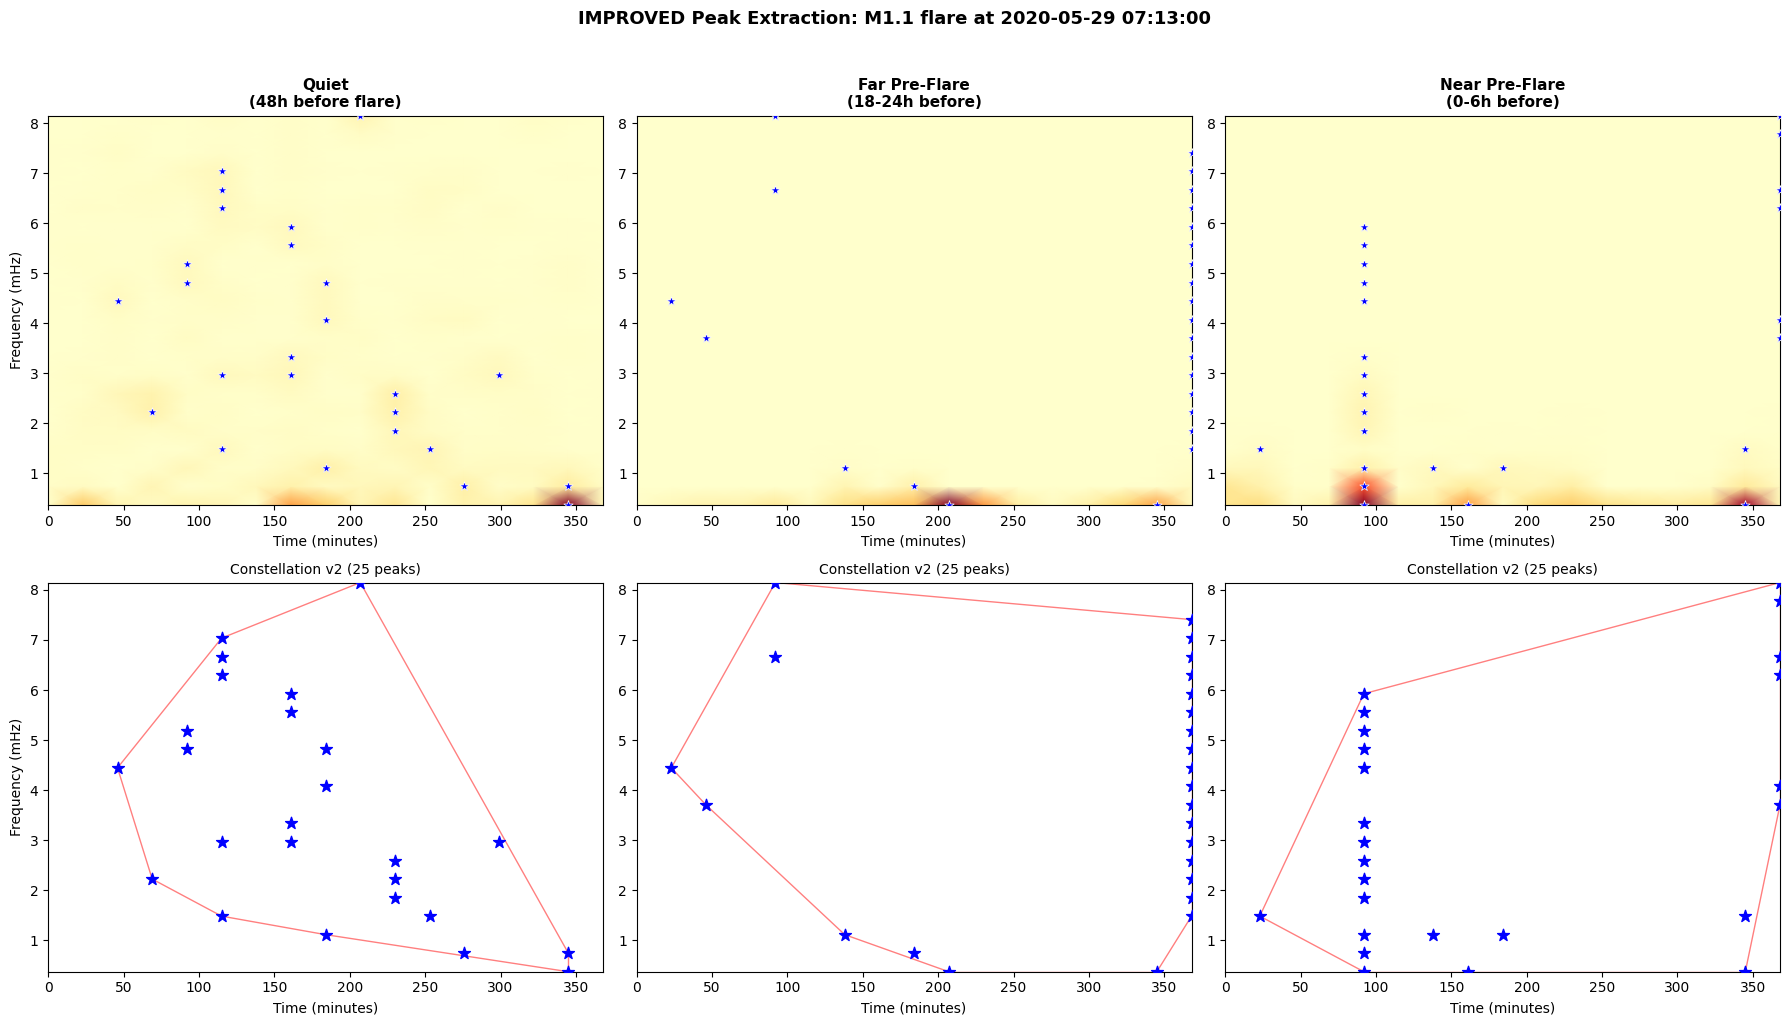


  COMPARISON: Original vs Improved Peak Extraction
  Descriptor                                Quiet    Far Pre   Near Pre
  -----------------------------------------------------------------
  peak_count                        v1    24.0000    15.0000    10.0000
                                    v2    25.0000    25.0000    25.0000

  hull_area                         v1     0.8605     0.8651     0.5538
                                    v2     0.5751     0.7984     0.7429

  nn_dist_mean                      v1     0.1692     0.2255     0.2346
                                    v2     0.0995     0.0754     0.0698

  pairwise_dist_mean                v1     0.5736     0.5982     0.5844
                                    v2     0.4930     0.5630     0.5977

  KEY QUESTION: Did prominence filtering remove the noise peaks
  from high frequencies while keeping the real low-frequency peaks?
  Compare the constellation plots — v2 should have fewer scattered
  stars in the upper part of 

In [ ]:
# ============================================================
# CELL 26: STAGE 1b — Improved Peak Extraction
# ============================================================
# Two fixes based on diagnostic findings:
# 1. Prominence rule: peak must exceed neighborhood by a margin
# 2. Band-aware normalization: normalize each frequency band
#    independently so low-freq doesn't dominate

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from scipy.ndimage import maximum_filter, minimum_filter
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, cdist

def compute_constellation_v2(flux_values, fs=1/60, nperseg_min=45,
                              noverlap_frac=0.5, prominence_factor=1.5,
                              max_peaks=30, detrend_method='linear'):
    """
    Improved constellation extraction with:
    - Band-aware normalization (each freq band normalized independently)
    - Prominence rule (peak must exceed local minimum by a factor)
    - Max peak cap to prevent noise flooding

    Parameters
    ----------
    flux_values : 1D array of flux values
    fs : sampling frequency in Hz
    nperseg_min : STFT window length in minutes
    noverlap_frac : overlap fraction
    prominence_factor : peak must be this many times the local minimum
    max_peaks : maximum number of peaks to keep (strongest first)
    detrend_method : 'linear' or 'divide_by_smooth'
    """
    # ---- Detrending ----
    log_flux = np.log10(np.clip(flux_values, 1e-10, None))

    if detrend_method == 'linear':
        trend = np.polyval(
            np.polyfit(np.arange(len(log_flux)), log_flux, 1),
            np.arange(len(log_flux))
        )
        detrended = log_flux - trend
    elif detrend_method == 'divide_by_smooth':
        # Rolling mean as smooth trend
        smooth = pd.Series(log_flux).rolling(30, center=True, min_periods=1).mean().values
        detrended = log_flux - smooth  # in log space, subtraction = division
    else:
        detrended = log_flux

    # ---- STFT ----
    nperseg = int(nperseg_min)
    noverlap = int(nperseg * noverlap_frac)

    freqs, times, Zxx = stft(detrended, fs=fs, nperseg=nperseg,
                              noverlap=noverlap, window='hann')

    power = np.abs(Zxx) ** 2

    # Skip DC
    power = power[1:, :]
    freqs = freqs[1:]

    # ---- Band-aware normalization ----
    # Normalize each frequency row independently
    # This prevents low-frequency dominance
    power_band_norm = np.zeros_like(power)
    for row in range(power.shape[0]):
        row_max = power[row, :].max()
        if row_max > 0:
            power_band_norm[row, :] = power[row, :] / row_max
        else:
            power_band_norm[row, :] = 0

    # Also keep total-power normalized version for descriptors
    total_power = power.sum()
    power_total_norm = power / total_power if total_power > 0 else power

    # ---- Peak extraction with prominence ----
    neighborhood_size = (3, 3)

    # Local max and local min
    local_max = maximum_filter(power_band_norm, size=neighborhood_size)
    local_min = minimum_filter(power_band_norm, size=neighborhood_size)

    # A peak must:
    # 1. Equal the local maximum (it IS the max in its neighborhood)
    # 2. Exceed the local minimum by prominence_factor
    # 3. Have band-normalized value above a minimum threshold
    min_threshold = 0.3  # must be at least 30 percent of its band's max

    peak_mask = (
        (power_band_norm == local_max) &
        (power_band_norm >= prominence_factor * np.maximum(local_min, 1e-10)) &
        (power_band_norm >= min_threshold)
    )

    # Get peak coordinates and their power values
    peak_coords = np.argwhere(peak_mask)

    if len(peak_coords) == 0:
        return freqs, times, power_total_norm, []

    # Sort by power (in the original non-normalized spectrogram) and keep top N
    peak_powers = [power[p[0], p[1]] for p in peak_coords]
    sorted_idx = np.argsort(peak_powers)[::-1]  # strongest first
    peak_coords = peak_coords[sorted_idx[:max_peaks]]

    peaks = [(int(p[1]), int(p[0])) for p in peak_coords]  # (time, freq)

    return freqs, times, power_total_norm, peaks


# ---- Re-run visualization with improved extractor ----
print("Re-running with improved peak extraction...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
all_descriptors_v2 = {}

for i, (name, flux) in enumerate(windows.items()):
    flux_clean = pd.Series(flux).ffill().bfill().values

    freqs, times, power, peaks = compute_constellation_v2(
        flux_clean, nperseg_min=45, prominence_factor=1.5, max_peaks=25
    )

    desc = compute_descriptors(peaks, freqs, times)
    all_descriptors_v2[name] = desc

    times_min = times / 60
    freqs_mhz = freqs * 1000

    # ---- Top: spectrogram with peaks ----
    ax_top = axes[0, i]
    im = ax_top.pcolormesh(times_min, freqs_mhz, power,
                            shading='gouraud', cmap='YlOrRd')

    if len(peaks) > 0:
        peak_times = [times_min[t] if t < len(times_min) else times_min[-1]
                      for t, f in peaks]
        peak_freqs = [freqs_mhz[f] if f < len(freqs_mhz) else freqs_mhz[-1]
                      for t, f in peaks]
        ax_top.scatter(peak_times, peak_freqs, c='blue', s=50,
                       marker='*', zorder=5, edgecolors='white', linewidth=0.5)

    ax_top.set_title(name, fontsize=11, fontweight='bold')
    ax_top.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_top.set_xlabel('Time (minutes)')

    # ---- Bottom: constellation ----
    ax_bot = axes[1, i]

    if len(peaks) > 0:
        ax_bot.scatter(peak_times, peak_freqs, c='blue', s=80,
                       marker='*', zorder=5)
        if len(peaks) >= 3:
            try:
                pts = np.array(list(zip(peak_times, peak_freqs)))
                hull = ConvexHull(pts)
                for simplex in hull.simplices:
                    ax_bot.plot(pts[simplex, 0], pts[simplex, 1],
                               'r-', linewidth=1, alpha=0.5)
            except Exception:
                pass

    ax_bot.set_title(f"Constellation v2 ({desc['peak_count']} peaks)", fontsize=10)
    ax_bot.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_bot.set_xlabel('Time (minutes)')
    ax_bot.set_xlim(axes[0, i].get_xlim())
    ax_bot.set_ylim(axes[0, i].get_ylim())

plt.suptitle(f"IMPROVED Peak Extraction: {selected_flare['flare_class']} flare at {flare_time}",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/sanity_visualization_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Compare v1 vs v2 descriptors ----
print(f"\n{'='*70}")
print(f"  COMPARISON: Original vs Improved Peak Extraction")
print(f"{'='*70}")
print(f"  {'Descriptor':<25s} {'':>10s} {'Quiet':>10s} {'Far Pre':>10s} {'Near Pre':>10s}")
print(f"  {'-'*65}")

desc_keys = ['peak_count', 'hull_area', 'nn_dist_mean', 'pairwise_dist_mean']
names = list(windows.keys())

for key in desc_keys:
    vals_v1 = [all_descriptors[n].get(key, 0) for n in names]
    vals_v2 = [all_descriptors_v2[n].get(key, 0) for n in names]
    print(f"  {key:<25s} {'v1':>10s} {vals_v1[0]:>10.4f} {vals_v1[1]:>10.4f} {vals_v1[2]:>10.4f}")
    print(f"  {'':<25s} {'v2':>10s} {vals_v2[0]:>10.4f} {vals_v2[1]:>10.4f} {vals_v2[2]:>10.4f}")
    print()

print(f"{'='*70}")
print(f"  KEY QUESTION: Did prominence filtering remove the noise peaks")
print(f"  from high frequencies while keeping the real low-frequency peaks?")
print(f"  Compare the constellation plots — v2 should have fewer scattered")
print(f"  stars in the upper part of the spectrogram.")
print(f"{'='*70}")

band-aware normalization assumes every frequency band contains meaningful information. In GOES X-ray spectrograms, that's false. Most of the real spectral content lives below ~2 mHz. The bands above 3–4 mHz are essentially empty. Normalizing each band independently is like turning up the volume on a silent channel — you amplify noise.
The right fix is different from what we tried. Instead of normalizing per band, we should keep the global power structure but use a smarter peak selection

Running v3 peak extraction...



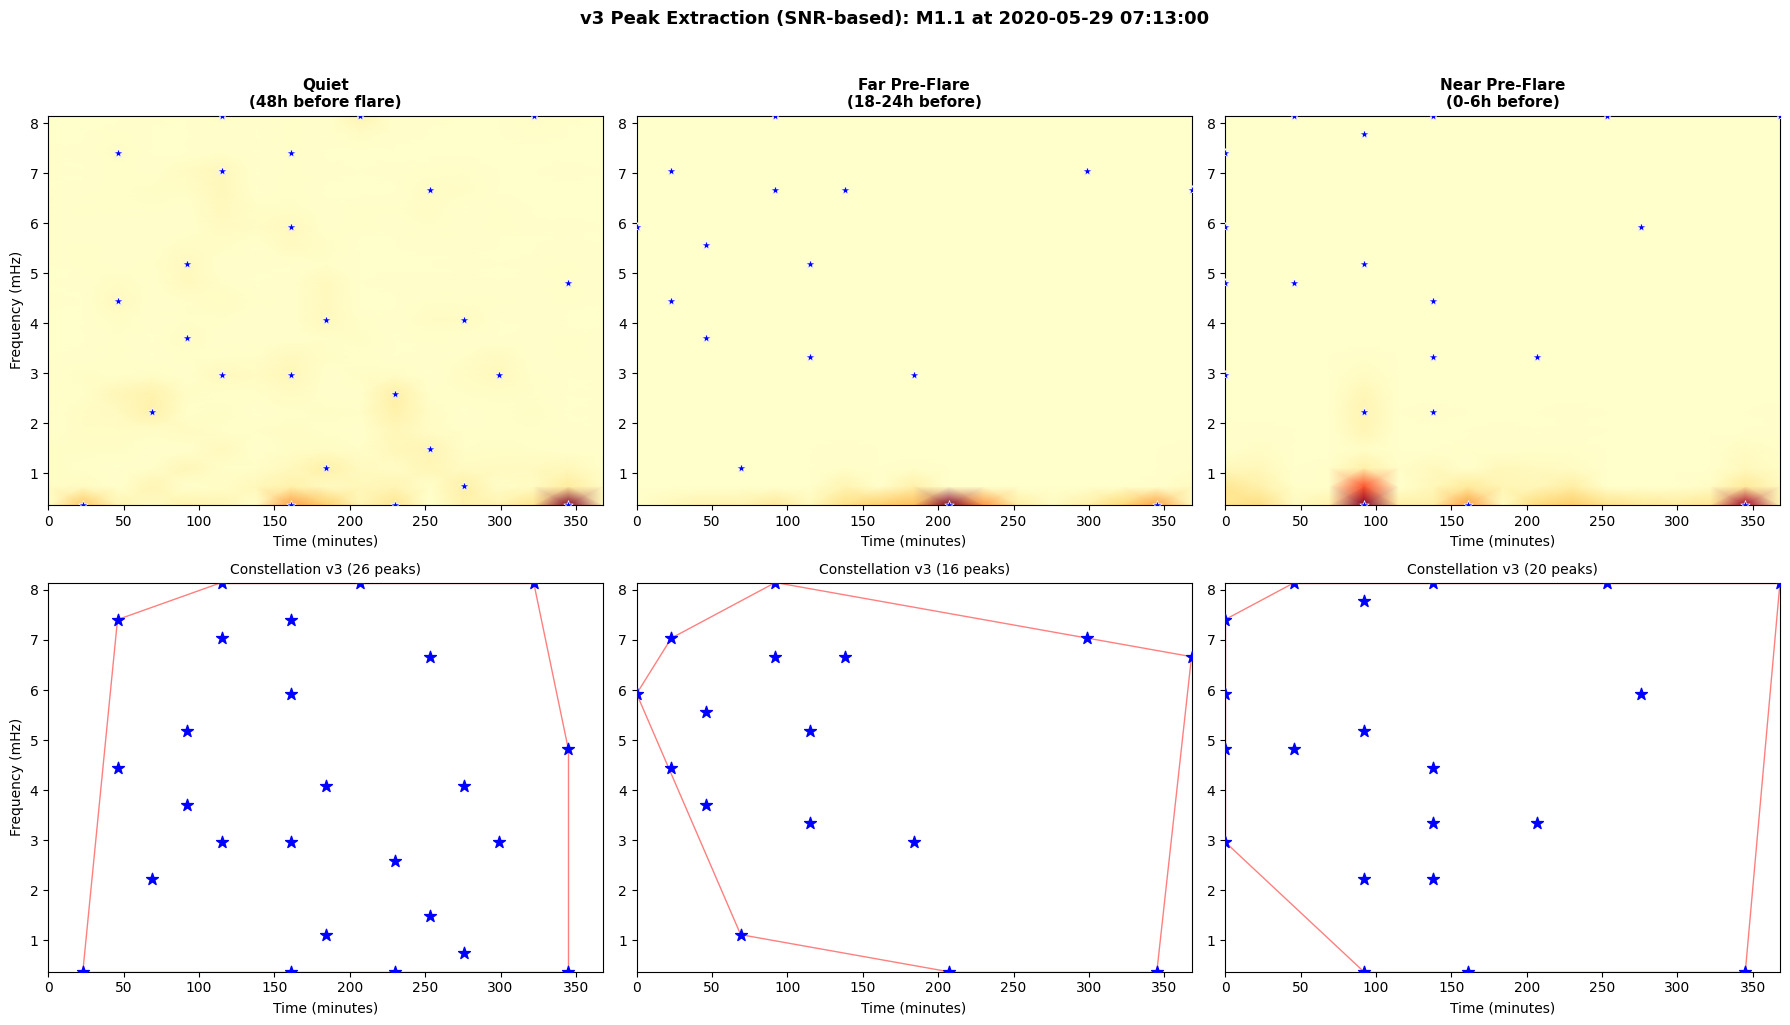


  COMPARISON: v1 (original) vs v2 (band-norm) vs v3 (SNR-based)
  Descriptor              Ver      Quiet    Far Pre   Near Pre
  ------------------------------------------------------------
  peak_count               v1    24.0000    15.0000    10.0000
                           v2    25.0000    25.0000    25.0000
                           v3    26.0000    16.0000    20.0000

  hull_area                v1     0.8605     0.8651     0.5538
                           v2     0.5751     0.7984     0.7429
                           v3     0.9354     0.7827     0.9211

  nn_dist_mean             v1     0.1692     0.2255     0.2346
                           v2     0.0995     0.0754     0.0698
                           v3     0.1706     0.1928     0.1909

  pairwise_dist_mean       v1     0.5736     0.5982     0.5844
                           v2     0.4930     0.5630     0.5977
                           v3     0.5888     0.5670     0.5920

  v3 PEAK QUALITY CHECK

  Quiet (48h before flar

In [ ]:
# ============================================================
# CELL 27: STAGE 1c — Fixed Peak Extraction (v3)
# ============================================================
# The right approach: keep global power relationships,
# but require peaks to have REAL prominence above their
# local background, and set threshold based on actual
# power distribution, not percentile of band-normalized values.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from scipy.ndimage import maximum_filter
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, cdist

def compute_constellation_v3(flux_values, fs=1/60, nperseg_min=45,
                              noverlap_frac=0.5, snr_threshold=2.0,
                              min_power_pct=50, max_peaks=30,
                              detrend_method='linear'):
    """
    Peak extraction v3:
    - Global power normalization (preserves real structure)
    - SNR-based peak selection: peak must be snr_threshold times
      the MEDIAN power in its frequency row (not the local min)
    - Minimum absolute power threshold (percentile-based)
    - No band-aware normalization (that added noise)
    """
    # ---- Detrending ----
    log_flux = np.log10(np.clip(flux_values, 1e-10, None))

    if detrend_method == 'linear':
        trend = np.polyval(
            np.polyfit(np.arange(len(log_flux)), log_flux, 1),
            np.arange(len(log_flux))
        )
        detrended = log_flux - trend
    elif detrend_method == 'divide_by_smooth':
        smooth = pd.Series(log_flux).rolling(30, center=True, min_periods=1).mean().values
        detrended = log_flux - smooth
    else:
        detrended = log_flux

    # ---- STFT ----
    nperseg = int(nperseg_min)
    noverlap = int(nperseg * noverlap_frac)

    freqs, times, Zxx = stft(detrended, fs=fs, nperseg=nperseg,
                              noverlap=noverlap, window='hann')

    power = np.abs(Zxx) ** 2
    power = power[1:, :]  # skip DC
    freqs = freqs[1:]

    # Normalize by total power
    total_power = power.sum()
    power_norm = power / total_power if total_power > 0 else power

    # ---- Peak extraction ----
    # Step 1: Find local maxima (3x3 neighborhood)
    neighborhood_size = (3, 3)
    local_max = maximum_filter(power_norm, size=neighborhood_size)
    is_local_max = (power_norm == local_max)

    # Step 2: Compute SNR for each point relative to its frequency row
    # Peak must be snr_threshold times the median of its frequency band
    row_medians = np.median(power_norm, axis=1, keepdims=True)
    row_medians = np.maximum(row_medians, 1e-12)  # avoid division by zero
    snr_map = power_norm / row_medians

    # Step 3: Minimum absolute power threshold
    # Peak must be above the min_power_pct percentile of ALL nonzero values
    nonzero_power = power_norm[power_norm > 0]
    if len(nonzero_power) > 0:
        abs_threshold = np.percentile(nonzero_power, min_power_pct)
    else:
        abs_threshold = 0

    # Step 4: Combine criteria
    peak_mask = (
        is_local_max &                          # must be local maximum
        (snr_map >= snr_threshold) &            # must exceed band median by factor
        (power_norm >= abs_threshold)            # must have meaningful absolute power
    )

    # Step 5: Get peaks and sort by power
    peak_coords = np.argwhere(peak_mask)

    if len(peak_coords) == 0:
        return freqs, times, power_norm, []

    peak_powers = [power_norm[p[0], p[1]] for p in peak_coords]
    sorted_idx = np.argsort(peak_powers)[::-1]
    peak_coords = peak_coords[sorted_idx[:max_peaks]]

    peaks = [(int(p[1]), int(p[0])) for p in peak_coords]

    return freqs, times, power_norm, peaks


# ---- Run v3 and compare all three versions ----
print("Running v3 peak extraction...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
all_descriptors_v3 = {}

for i, (name, flux) in enumerate(windows.items()):
    flux_clean = pd.Series(flux).ffill().bfill().values

    freqs, times, power, peaks = compute_constellation_v3(
        flux_clean, nperseg_min=45, snr_threshold=2.0,
        min_power_pct=50, max_peaks=30
    )

    desc = compute_descriptors(peaks, freqs, times)
    all_descriptors_v3[name] = desc

    times_min = times / 60
    freqs_mhz = freqs * 1000

    # Top: spectrogram with peaks
    ax_top = axes[0, i]
    im = ax_top.pcolormesh(times_min, freqs_mhz, power,
                            shading='gouraud', cmap='YlOrRd')

    if len(peaks) > 0:
        peak_times = [times_min[t] if t < len(times_min) else times_min[-1]
                      for t, f in peaks]
        peak_freqs = [freqs_mhz[f] if f < len(freqs_mhz) else freqs_mhz[-1]
                      for t, f in peaks]
        ax_top.scatter(peak_times, peak_freqs, c='blue', s=50,
                       marker='*', zorder=5, edgecolors='white', linewidth=0.5)

    ax_top.set_title(name, fontsize=11, fontweight='bold')
    ax_top.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_top.set_xlabel('Time (minutes)')

    # Bottom: constellation
    ax_bot = axes[1, i]

    if len(peaks) > 0:
        ax_bot.scatter(peak_times, peak_freqs, c='blue', s=80,
                       marker='*', zorder=5)
        if len(peaks) >= 3:
            try:
                pts = np.array(list(zip(peak_times, peak_freqs)))
                hull = ConvexHull(pts)
                for simplex in hull.simplices:
                    ax_bot.plot(pts[simplex, 0], pts[simplex, 1],
                               'r-', linewidth=1, alpha=0.5)
            except Exception:
                pass

    ax_bot.set_title(f"Constellation v3 ({desc['peak_count']} peaks)", fontsize=10)
    ax_bot.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_bot.set_xlabel('Time (minutes)')
    ax_bot.set_xlim(axes[0, i].get_xlim())
    ax_bot.set_ylim(axes[0, i].get_ylim())

plt.suptitle(f"v3 Peak Extraction (SNR-based): {selected_flare['flare_class']} at {flare_time}",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/sanity_visualization_v3.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Compare all three versions ----
print(f"\n{'='*70}")
print(f"  COMPARISON: v1 (original) vs v2 (band-norm) vs v3 (SNR-based)")
print(f"{'='*70}")
print(f"  {'Descriptor':<22s} {'Ver':>4s} {'Quiet':>10s} {'Far Pre':>10s} {'Near Pre':>10s}")
print(f"  {'-'*60}")

desc_keys = ['peak_count', 'hull_area', 'nn_dist_mean', 'pairwise_dist_mean']
names = list(windows.keys())

for key in desc_keys:
    vals_v1 = [all_descriptors[n].get(key, 0) for n in names]
    vals_v2 = [all_descriptors_v2[n].get(key, 0) for n in names]
    vals_v3 = [all_descriptors_v3[n].get(key, 0) for n in names]
    print(f"  {key:<22s} {'v1':>4s} {vals_v1[0]:>10.4f} {vals_v1[1]:>10.4f} {vals_v1[2]:>10.4f}")
    print(f"  {'':<22s} {'v2':>4s} {vals_v2[0]:>10.4f} {vals_v2[1]:>10.4f} {vals_v2[2]:>10.4f}")
    print(f"  {'':<22s} {'v3':>4s} {vals_v3[0]:>10.4f} {vals_v3[1]:>10.4f} {vals_v3[2]:>10.4f}")
    print()

# ---- Run peak quality diagnostic on v3 ----
print(f"{'='*70}")
print(f"  v3 PEAK QUALITY CHECK")
print(f"{'='*70}")

for name, flux in windows.items():
    flux_clean = pd.Series(flux).ffill().bfill().values
    freqs, times, power, peaks = compute_constellation_v3(
        flux_clean, nperseg_min=45, snr_threshold=2.0, min_power_pct=50
    )

    if len(peaks) == 0:
        continue

    peak_freqs_mhz = [freqs[f] * 1000 for t, f in peaks]
    peak_powers = [power[f, t] for t, f in peaks]

    n_below_1 = sum(1 for f in peak_freqs_mhz if f < 1.5)
    n_above_3 = sum(1 for f in peak_freqs_mhz if f > 3.0)
    n_total = len(peaks)

    clean_name = name.replace('\n', ' ')
    print(f"\n  {clean_name}:")
    print(f"    Total peaks:         {n_total}")
    print(f"    Below 1.5 mHz:       {n_below_1} ({100*n_below_1/n_total:.0f} pct)")
    print(f"    Above 3.0 mHz:       {n_above_3} ({100*n_above_3/n_total:.0f} pct)")
    print(f"    Power range:         [{np.min(peak_powers):.6f}, {np.max(peak_powers):.6f}]")

    low_p = [p for p, f in zip(peak_powers, peak_freqs_mhz) if f < 1.5]
    high_p = [p for p, f in zip(peak_powers, peak_freqs_mhz) if f > 3.0]
    if low_p and high_p:
        print(f"    Low/High power ratio: {np.mean(low_p)/np.mean(high_p):.1f}x")

print(f"\n{'='*70}")
print(f"  If v3 reduced noise peaks above 3 mHz while keeping peak count")
print(f"  differences between windows, the extraction is improving.")
print(f"{'='*70}")

v3 is finding more high-frequency noise peaks than v1 did. The SNR test (peak must be 2x the row median) isn't solving the problem because in a dead frequency row, random noise variation can easily produce points that are 2x the median of near-zero values.
The power ratios confirm it. Far pre-flare has a low/high power ratio of 1410x. That means the low-frequency peaks are carrying 1,410 times more actual spectral energy than the high-frequency "peaks." Those high-frequency points are not spectral features — they're numerical noise that passed a weak filter.
The hull areas lost their differentiation. In v1: quiet=0.86, far=0.87, near=0.55. That near-pre-flare compression was our most promising geometric signal. In v3: quiet=0.94, far=0.78, near=0.92. The quiet and near-pre-flare are nearly identical. The noise peaks inflated the near-pre-flare hull back to the same size as quiet.
The real fix is the energy gate the feedback suggested. Before allowing a frequency row to contribute any peaks at all, require that the row contains a minimum fraction of total spectrogram energy. Dead rows get zero peaks, period. No amount of SNR or prominence testing will save a row that has essentially no energy. Let me save this progress and we can pick it up from here — but I want to be clear about where we are.
We're still in Stage 1, and this is exactly what Stage 1 is for. We're iterating on the peak extraction before trusting any downstream results. The sanity visualization did its job — it showed us the spectrograms have real differences, but our peak finder isn't mature enough to capture them cleanly yet. That's a productive finding, not a failure.

Running v4 peak extraction (energy gate + additive prominence)...

  Quiet (48h before flare):
    Active freq rows: 22 / 22 (100 pct passed energy gate)
    Raw candidates:   28
    Final peaks:      28
  Far Pre-Flare (18-24h before):
    Active freq rows: 3 / 22 (14 pct passed energy gate)
    Raw candidates:   4
    Final peaks:      4
  Near Pre-Flare (0-6h before):
    Active freq rows: 7 / 22 (32 pct passed energy gate)
    Raw candidates:   6
    Final peaks:      6


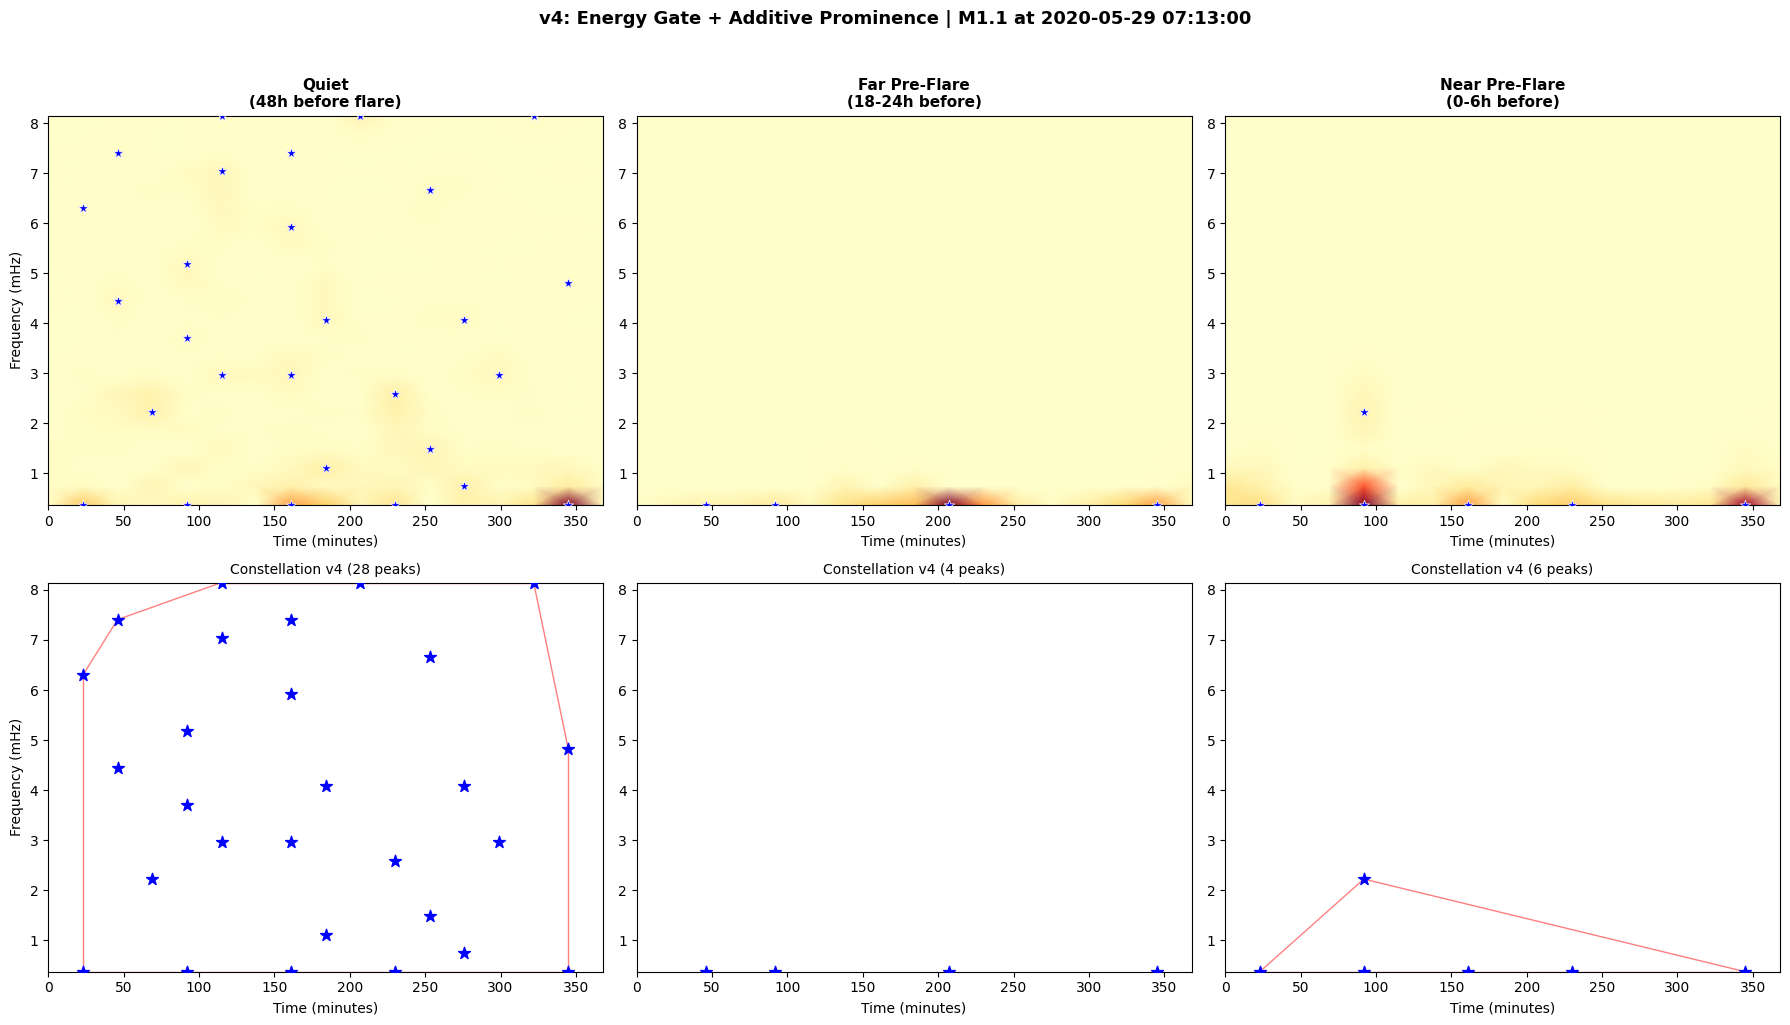


  COMPARISON: v1 vs v2 vs v3 vs v4
  Descriptor              Ver      Quiet    Far Pre   Near Pre
  ------------------------------------------------------------
  peak_count               v1    24.0000    15.0000    10.0000
                           v2    25.0000    25.0000    25.0000
                           v3    26.0000    16.0000    20.0000
                           v4    28.0000     4.0000     6.0000

  hull_area                v1     0.8605     0.8651     0.5538
                           v2     0.5751     0.7984     0.7429
                           v3     0.9354     0.7827     0.9211
                           v4     0.9626     0.0000     0.5000

  nn_dist_mean             v1     0.1692     0.2255     0.2346
                           v2     0.0995     0.0754     0.0698
                           v3     0.1706     0.1928     0.1909
                           v4     0.1674     0.2885     0.3690

  pairwise_dist_mean       v1     0.5736     0.5982     0.5844
                

In [ ]:
# ============================================================
# CELL 28: STAGE 1d — v4 Peak Extraction (Energy Gate + Additive Prominence)
# ============================================================
# Fixes all identified problems:
# 1. Energy gate: frequency rows with < X% of total energy get ZERO peaks
# 2. Additive prominence: peak must exceed local background by a
#    meaningful absolute amount, not a ratio of near-zero
# 3. Global power normalization (no band-aware normalization)
# 4. No tight peak cap during diagnosis — let the count breathe

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import stft
from scipy.ndimage import maximum_filter, median_filter
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, cdist

def compute_constellation_v4(flux_values, fs=1/60, nperseg_min=45,
                              noverlap_frac=0.5,
                              energy_gate_pct=1.0,
                              prominence_delta_pct=50,
                              detrend_method='linear'):
    """
    Peak extraction v4:
    - Energy gate: a frequency row must contain >= energy_gate_pct
      of total spectrogram energy to contribute ANY peaks
    - Additive prominence: peak must exceed local background
      (median filter) by an absolute delta
    - No band normalization, no hard peak cap
    - Returns both raw candidate count and final peaks

    Parameters
    ----------
    flux_values : 1D array
    fs : sampling frequency (1/60 Hz for 1-min cadence)
    nperseg_min : STFT window in minutes
    noverlap_frac : overlap fraction
    energy_gate_pct : minimum percent of total energy a freq row
                      must have to contribute peaks (e.g., 1.0 = 1%)
    prominence_delta_pct : peak must exceed local background by this
                           percentile of the global power distribution
    detrend_method : 'linear' or 'divide_by_smooth'
    """
    # ---- Detrending ----
    log_flux = np.log10(np.clip(flux_values, 1e-10, None))

    if detrend_method == 'linear':
        trend = np.polyval(
            np.polyfit(np.arange(len(log_flux)), log_flux, 1),
            np.arange(len(log_flux))
        )
        detrended = log_flux - trend
    elif detrend_method == 'divide_by_smooth':
        smooth = pd.Series(log_flux).rolling(30, center=True, min_periods=1).mean().values
        detrended = log_flux - smooth
    else:
        detrended = log_flux

    # ---- STFT ----
    nperseg = int(nperseg_min)
    noverlap = int(nperseg * noverlap_frac)

    freqs, times, Zxx = stft(detrended, fs=fs, nperseg=nperseg,
                              noverlap=noverlap, window='hann')

    power = np.abs(Zxx) ** 2
    power = power[1:, :]  # skip DC
    freqs = freqs[1:]

    # Global normalization
    total_power = power.sum()
    power_norm = power / total_power if total_power > 0 else power

    # ---- Step 1: Energy gate ----
    # Compute what fraction of total energy each frequency row holds
    row_energies = power_norm.sum(axis=1)  # sum across time for each freq
    total_row_energy = row_energies.sum()
    row_energy_pct = 100 * row_energies / total_row_energy if total_row_energy > 0 else row_energies

    # Rows that pass the energy gate
    active_rows = row_energy_pct >= energy_gate_pct
    n_active = active_rows.sum()
    n_total_rows = len(freqs)

    # Zero out dead rows — they cannot contribute peaks
    power_gated = power_norm.copy()
    power_gated[~active_rows, :] = 0

    # ---- Step 2: Local maximum detection ----
    neighborhood_size = (3, 3)
    local_max = maximum_filter(power_gated, size=neighborhood_size)
    is_local_max = (power_gated == local_max) & (power_gated > 0)

    # ---- Step 3: Additive prominence ----
    # Local background = median filter (smooth local floor)
    local_background = median_filter(power_gated, size=(5, 5))

    # Prominence = how much peak rises above local background
    prominence = power_gated - local_background

    # Delta threshold: peak must rise above background by at least
    # the Nth percentile of all positive prominence values
    positive_prominence = prominence[prominence > 0]
    if len(positive_prominence) > 0:
        delta = np.percentile(positive_prominence, prominence_delta_pct)
    else:
        delta = 0

    # ---- Step 4: Final peak selection ----
    peak_mask = is_local_max & (prominence >= delta)

    peak_coords = np.argwhere(peak_mask)

    # Record raw candidate count before any cap
    raw_candidate_count = len(peak_coords)

    if len(peak_coords) == 0:
        return freqs, times, power_norm, [], n_active, n_total_rows, raw_candidate_count

    # Sort by actual power (strongest first) — no hard cap
    peak_powers = [power_norm[p[0], p[1]] for p in peak_coords]
    sorted_idx = np.argsort(peak_powers)[::-1]
    peak_coords = peak_coords[sorted_idx]

    peaks = [(int(p[1]), int(p[0])) for p in peak_coords]

    return freqs, times, power_norm, peaks, n_active, n_total_rows, raw_candidate_count


# ---- Run v4 ----
print("Running v4 peak extraction (energy gate + additive prominence)...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
all_descriptors_v4 = {}

for i, (name, flux) in enumerate(windows.items()):
    flux_clean = pd.Series(flux).ffill().bfill().values

    freqs, times, power, peaks, n_active, n_total, n_candidates = \
        compute_constellation_v4(
            flux_clean, nperseg_min=45,
            energy_gate_pct=1.0,       # row must have >= 1% of energy
            prominence_delta_pct=50     # peak must be above median prominence
        )

    desc = compute_descriptors(peaks, freqs, times)
    all_descriptors_v4[name] = desc

    clean_name = name.replace('\n', ' ')
    print(f"  {clean_name}:")
    print(f"    Active freq rows: {n_active} / {n_total} "
          f"({100*n_active/n_total:.0f} pct passed energy gate)")
    print(f"    Raw candidates:   {n_candidates}")
    print(f"    Final peaks:      {len(peaks)}")

    times_min = times / 60
    freqs_mhz = freqs * 1000

    # ---- Top: spectrogram with peaks ----
    ax_top = axes[0, i]
    im = ax_top.pcolormesh(times_min, freqs_mhz, power,
                            shading='gouraud', cmap='YlOrRd')

    # Draw energy gate line — show which frequencies are active
    for row_idx in range(len(freqs)):
        if not (row_idx < len(freqs) and
                power[row_idx, :].sum() / power.sum() >= 0.01 if power.sum() > 0 else False):
            pass  # dead row, no marker needed

    if len(peaks) > 0:
        peak_times = [times_min[t] if t < len(times_min) else times_min[-1]
                      for t, f in peaks]
        peak_freqs = [freqs_mhz[f] if f < len(freqs_mhz) else freqs_mhz[-1]
                      for t, f in peaks]
        ax_top.scatter(peak_times, peak_freqs, c='blue', s=60,
                       marker='*', zorder=5, edgecolors='white', linewidth=0.5)

    ax_top.set_title(name, fontsize=11, fontweight='bold')
    ax_top.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_top.set_xlabel('Time (minutes)')

    # ---- Bottom: constellation ----
    ax_bot = axes[1, i]

    if len(peaks) > 0:
        ax_bot.scatter(peak_times, peak_freqs, c='blue', s=80,
                       marker='*', zorder=5)
        if len(peaks) >= 3:
            try:
                pts = np.array(list(zip(peak_times, peak_freqs)))
                hull = ConvexHull(pts)
                for simplex in hull.simplices:
                    ax_bot.plot(pts[simplex, 0], pts[simplex, 1],
                               'r-', linewidth=1, alpha=0.5)
            except Exception:
                pass

    ax_bot.set_title(f"Constellation v4 ({len(peaks)} peaks)", fontsize=10)
    ax_bot.set_ylabel('Frequency (mHz)' if i == 0 else '')
    ax_bot.set_xlabel('Time (minutes)')
    ax_bot.set_xlim(axes[0, i].get_xlim())
    ax_bot.set_ylim(axes[0, i].get_ylim())

plt.suptitle(f"v4: Energy Gate + Additive Prominence | {selected_flare['flare_class']} at {flare_time}",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/solar-flare-precursors/results/sanity_visualization_v4.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Full comparison table ----
print(f"\n{'='*75}")
print(f"  COMPARISON: v1 vs v2 vs v3 vs v4")
print(f"{'='*75}")
print(f"  {'Descriptor':<22s} {'Ver':>4s} {'Quiet':>10s} {'Far Pre':>10s} {'Near Pre':>10s}")
print(f"  {'-'*60}")

desc_keys = ['peak_count', 'hull_area', 'nn_dist_mean', 'pairwise_dist_mean']
names = list(windows.keys())

for key in desc_keys:
    vals_v1 = [all_descriptors[n].get(key, 0) for n in names]
    vals_v2 = [all_descriptors_v2[n].get(key, 0) for n in names]
    vals_v3 = [all_descriptors_v3[n].get(key, 0) for n in names]
    vals_v4 = [all_descriptors_v4[n].get(key, 0) for n in names]
    print(f"  {key:<22s} {'v1':>4s} {vals_v1[0]:>10.4f} {vals_v1[1]:>10.4f} {vals_v1[2]:>10.4f}")
    print(f"  {'':<22s} {'v2':>4s} {vals_v2[0]:>10.4f} {vals_v2[1]:>10.4f} {vals_v2[2]:>10.4f}")
    print(f"  {'':<22s} {'v3':>4s} {vals_v3[0]:>10.4f} {vals_v3[1]:>10.4f} {vals_v3[2]:>10.4f}")
    print(f"  {'':<22s} {'v4':>4s} {vals_v4[0]:>10.4f} {vals_v4[1]:>10.4f} {vals_v4[2]:>10.4f}")
    print()

# ---- v4 peak quality check ----
print(f"{'='*75}")
print(f"  v4 PEAK QUALITY CHECK")
print(f"{'='*75}")

for name, flux in windows.items():
    flux_clean = pd.Series(flux).ffill().bfill().values
    freqs, times, power, peaks, _, _, _ = compute_constellation_v4(
        flux_clean, nperseg_min=45, energy_gate_pct=1.0, prominence_delta_pct=50
    )

    if len(peaks) == 0:
        clean_name = name.replace('\n', ' ')
        print(f"\n  {clean_name}: 0 peaks")
        continue

    peak_freqs_mhz = [freqs[f] * 1000 for t, f in peaks]
    peak_powers = [power[f, t] for t, f in peaks]

    n_below_1 = sum(1 for f in peak_freqs_mhz if f < 1.5)
    n_above_3 = sum(1 for f in peak_freqs_mhz if f > 3.0)
    n_total = len(peaks)

    clean_name = name.replace('\n', ' ')
    print(f"\n  {clean_name}:")
    print(f"    Total peaks:         {n_total}")
    print(f"    Below 1.5 mHz:       {n_below_1} ({100*n_below_1/n_total:.0f} pct)")
    print(f"    Above 3.0 mHz:       {n_above_3} ({100*n_above_3/n_total:.0f} pct)")
    print(f"    Power range:         [{np.min(peak_powers):.6f}, {np.max(peak_powers):.6f}]")

    low_p = [p for p, f in zip(peak_powers, peak_freqs_mhz) if f < 1.5]
    high_p = [p for p, f in zip(peak_powers, peak_freqs_mhz) if f > 3.0]
    if low_p and high_p:
        print(f"    Low/High power ratio: {np.mean(low_p)/np.mean(high_p):.1f}x")
    elif high_p:
        print(f"    Low/High power ratio: no low-freq peaks")
    else:
        print(f"    No peaks above 3 mHz — energy gate is working")

print(f"\n{'='*75}")
print(f"  SUCCESS CRITERIA FOR v4:")
print(f"  1. Fewer peaks above 3 mHz (noise eliminated)")
print(f"  2. Peak counts still vary between windows (not capped flat)")
print(f"  3. Hull area shows differentiation (not all same size)")
print(f"  4. Low/High power ratio much smaller (peaks are real)")
print(f"{'='*75}")

In [ ]:
# ============================================================
# CELL 29: STAGE 1e — Multi-Flare Audit (10 flares)
# ============================================================
# PRE-DEFINED before running:
#   Sparse-safe features: 9 primary + 4 conditional (peak_count >= 7)
#   Minimum peak cutoff: 7 for conditional features
#   Falsification: pattern must hold across majority of flares

import numpy as np
import pandas as pd

# ---- Select 10 well-separated M/X flares ----
test_flares_sorted = mx_flares[
    pd.to_datetime(mx_flares['start_time']) >= '2021-01-01'
].sort_values('start_time')

selected_flares = []
last_selected_time = pd.Timestamp('2000-01-01')

for _, flare in test_flares_sorted.iterrows():
    flare_time = pd.Timestamp(flare['start_time'])

    if (flare_time - last_selected_time).total_seconds() / 3600 < 72:
        continue

    quiet_start = flare_time - pd.Timedelta(hours=54)
    quiet_data = df.loc[quiet_start:quiet_start + pd.Timedelta(hours=6), 'xrsb']
    if len(quiet_data) < 300 or quiet_data.isna().sum() > 50:
        continue

    selected_flares.append(flare)
    last_selected_time = flare_time

    if len(selected_flares) >= 10:
        break

print(f"Selected {len(selected_flares)} independent flares (>72h apart):\n")

# ---- Run v4 on all windows ----
results = []

for flare in selected_flares:
    flare_time = pd.Timestamp(flare['start_time'])
    flare_class = flare['flare_class']

    window_defs = {
        'quiet': (flare_time - pd.Timedelta(hours=54),
                  flare_time - pd.Timedelta(hours=48)),
        'far_pre': (flare_time - pd.Timedelta(hours=24),
                    flare_time - pd.Timedelta(hours=18)),
        'near_pre': (flare_time - pd.Timedelta(hours=6),
                     flare_time),
    }

    row_data = {'flare': flare_class, 'time': str(flare_time)[:16]}

    for wtype, (wstart, wend) in window_defs.items():
        flux = df.loc[wstart:wend, 'xrsb'].values

        if len(flux) < 300:
            for col in ['peaks', 'active_rows', 'pct_above3', 'pct_below1_5',
                        'low_freq_frac', 'nn_dist']:
                row_data[f'{wtype}_{col}'] = np.nan
            continue

        flux_clean = pd.Series(flux).ffill().bfill().values

        freqs, times, power, peaks, n_active, n_total, n_cand = \
            compute_constellation_v4(
                flux_clean, nperseg_min=45,
                energy_gate_pct=1.0, prominence_delta_pct=50
            )

        peak_freqs_mhz = [freqs[f] * 1000 for t, f in peaks]
        peak_powers = [power[f, t] for t, f in peaks]

        n_above_3 = sum(1 for f in peak_freqs_mhz if f < 3.0 if False)
        n_above_3 = sum(1 for f in peak_freqs_mhz if f > 3.0)
        n_below_1_5 = sum(1 for f in peak_freqs_mhz if f < 1.5)
        n_total_peaks = len(peaks)

        # Low-frequency energy fraction from spectrogram
        freq_cutoff_idx = np.searchsorted(freqs, 1.5 / 1000)  # 1.5 mHz in Hz
        if power.sum() > 0:
            low_freq_energy = power[:freq_cutoff_idx, :].sum() / power.sum()
        else:
            low_freq_energy = 0

        # Nearest-neighbor distance
        nn_dist = 0
        if n_total_peaks >= 2:
            from scipy.spatial.distance import cdist
            points = np.array([(times[t] if t < len(times) else times[-1],
                                freqs[f] if f < len(freqs) else freqs[-1])
                               for t, f in peaks])
            range_t = np.ptp(points[:, 0])
            range_f = np.ptp(points[:, 1])
            if range_t > 0:
                points[:, 0] = (points[:, 0] - points[:, 0].min()) / range_t
            if range_f > 0:
                points[:, 1] = (points[:, 1] - points[:, 1].min()) / range_f
            dist_matrix = cdist(points, points)
            np.fill_diagonal(dist_matrix, np.inf)
            nn_dist = np.mean(dist_matrix.min(axis=1))

        row_data[f'{wtype}_peaks'] = n_total_peaks
        row_data[f'{wtype}_active_rows'] = n_active
        row_data[f'{wtype}_pct_above3'] = (100 * n_above_3 / n_total_peaks) if n_total_peaks > 0 else 0
        row_data[f'{wtype}_pct_below1_5'] = (100 * n_below_1_5 / n_total_peaks) if n_total_peaks > 0 else 0
        row_data[f'{wtype}_low_freq_frac'] = low_freq_energy
        row_data[f'{wtype}_nn_dist'] = nn_dist

    results.append(row_data)

results_df = pd.DataFrame(results)

# ---- Display full table ----
print(f"{'='*95}")
print(f"  MULTI-FLARE v4 AUDIT — PEAK COUNTS AND ACTIVE ROWS")
print(f"{'='*95}")
print(f"  {'Flare':<7s} {'Time':<17s} | {'Q pk':>5s} {'Q row':>5s} {'Q<1.5':>5s}"
      f" | {'FP pk':>5s} {'FP row':>6s} {'FP<1.5':>6s}"
      f" | {'NP pk':>5s} {'NP row':>6s} {'NP<1.5':>6s}")
print(f"  {'-'*93}")

for _, row in results_df.iterrows():
    print(f"  {row['flare']:<7s} {row['time']:<17s}"
          f" | {row['quiet_peaks']:>5.0f} {row['quiet_active_rows']:>5.0f} "
          f"{row['quiet_pct_below1_5']:>4.0f}%"
          f" | {row['far_pre_peaks']:>5.0f} {row['far_pre_active_rows']:>6.0f} "
          f"{row['far_pre_pct_below1_5']:>5.0f}%"
          f" | {row['near_pre_peaks']:>5.0f} {row['near_pre_active_rows']:>6.0f} "
          f"{row['near_pre_pct_below1_5']:>5.0f}%")

# ---- Summary ----
print(f"\n{'='*95}")
print(f"  SUMMARY ACROSS {len(results)} FLARES")
print(f"{'='*95}")

for wtype, label in [('quiet', 'Quiet'), ('far_pre', 'Far Pre-Flare'),
                      ('near_pre', 'Near Pre-Flare')]:
    peaks = results_df[f'{wtype}_peaks'].dropna()
    rows = results_df[f'{wtype}_active_rows'].dropna()
    low_pct = results_df[f'{wtype}_pct_below1_5'].dropna()
    low_frac = results_df[f'{wtype}_low_freq_frac'].dropna()

    print(f"\n  {label}:")
    print(f"    Peak count:      mean={peaks.mean():.1f}, median={peaks.median():.1f}, "
          f"range=[{peaks.min():.0f}, {peaks.max():.0f}]")
    print(f"    Active rows:     mean={rows.mean():.1f}, median={rows.median():.1f}")
    print(f"    Pct below 1.5mHz: mean={low_pct.mean():.0f}%")
    print(f"    Low-freq energy:  mean={low_frac.mean():.3f}")

    sparse = (peaks < 5).sum()
    very_sparse = (peaks < 3).sum()
    print(f"    Windows < 5 peaks: {sparse}/{len(peaks)} ({100*sparse/len(peaks):.0f}%)")
    print(f"    Windows < 3 peaks: {very_sparse}/{len(peaks)} ({100*very_sparse/len(peaks):.0f}%)")

# ---- Falsification check ----
print(f"\n{'='*95}")
print(f"  FALSIFICATION CHECK")
print(f"{'='*95}")

# Test 1: Do quiet windows consistently have MORE peaks than pre-flare?
quiet_more = 0
for _, row in results_df.iterrows():
    if row['quiet_peaks'] > row['near_pre_peaks']:
        quiet_more += 1
print(f"  Quiet has more peaks than near-pre-flare: "
      f"{quiet_more}/{len(results_df)} flares ({100*quiet_more/len(results_df):.0f}%)")

# Test 2: Do quiet windows have more active rows?
quiet_more_rows = 0
for _, row in results_df.iterrows():
    if row['quiet_active_rows'] > row['near_pre_active_rows']:
        quiet_more_rows += 1
print(f"  Quiet has more active rows than near-pre-flare: "
      f"{quiet_more_rows}/{len(results_df)} flares ({100*quiet_more_rows/len(results_df):.0f}%)")

# Test 3: How many pre-flare windows are too sparse for any features?
near_pre_sparse = (results_df['near_pre_peaks'] < 3).sum()
far_pre_sparse = (results_df['far_pre_peaks'] < 3).sum()
print(f"  Near-pre-flare windows too sparse (<3 peaks): "
      f"{near_pre_sparse}/{len(results_df)}")
print(f"  Far-pre-flare windows too sparse (<3 peaks): "
      f"{far_pre_sparse}/{len(results_df)}")

# Test 4: Does pattern hold for both M and X class?
for cls in ['M', 'X']:
    subset = results_df[results_df['flare'].str.startswith(cls)]
    if len(subset) > 0:
        q_mean = subset['quiet_peaks'].mean()
        np_mean = subset['near_pre_peaks'].mean()
        print(f"  {cls}-class ({len(subset)} flares): "
              f"quiet mean={q_mean:.1f} peaks, near-pre mean={np_mean:.1f} peaks")

print(f"\n  VERDICT:")
print(f"  Pattern holds if: quiet consistently > pre-flare in peaks and rows,")
print(f"  across both M and X class, with few windows too sparse to use.")
print(f"{'='*95}")

Selected 10 independent flares (>72h apart):

  MULTI-FLARE v4 AUDIT — PEAK COUNTS AND ACTIVE ROWS
  Flare   Time              |  Q pk Q row Q<1.5 | FP pk FP row FP<1.5 | NP pk NP row NP<1.5
  ---------------------------------------------------------------------------------------------
  M1.1    2021-04-19 23:19  |     4     5  100% |     8     10    75% |     6      5   100%
  M3.9    2021-05-07 18:43  |    10     8   60% |     7      7    86% |     8      3   100%
  M1.1    2021-05-22 17:03  |    10     8   60% |     5      5   100% |     4      3   100%
  M2.7    2021-07-03 07:04  |     9     6   89% |     4      3   100% |     6      3   100%
  M4.7    2021-08-28 05:39  |     7     6   86% |     6      4   100% |     5      7   100%
  M2.9    2021-09-23 04:07  |     7     7   71% |     4      6   100% |     7      5   100%
  M1.3    2021-10-26 02:40  |     6     5  100% |     5      3   100% |     6      4   100%
  M1.5    2021-11-01 00:57  |     6     5  100% |     6      4   100%

Conclusion:
Dense geometric constellation features won't work on GOES (too sparse)
Sparse spectral-concentration features show a modest but consistent signal
The project narrowed to: **does peak extraction add value beyond plain STFT summaries**?

In [ ]:
# ============================================================
# CELL 30: STAGE 2 — Synthetic Injection Test (18 configs)
# ============================================================
# Inject known signals into quiet windows. Check whether
# sparse-safe features respond differently to oscillations
# vs smooth rises. This is the go/no-go gate.
#
# Grid: 3 amplitudes × 2 complexity × 2 STFT windows = 12 oscillation
#        3 amplitudes × 2 STFT windows = 6 smooth rise
#        Total = 18

import numpy as np
import pandas as pd
import time

# ---- Select 5 quiet training windows for injection ----
# Use windows far from any flare in the training period
quiet_windows = []
train_period = df.loc[df.index < '2019-07-01']  # mid-training, well away from edges

for start_idx in range(0, len(train_period) - 360, 2000):
    window = train_period.iloc[start_idx:start_idx + 360]
    flux = window['xrsb'].values

    if np.isnan(flux).sum() == 0 and len(flux) == 360:
        # Check no flare nearby
        w_start = window.index[0]
        w_end = window.index[-1]
        nearby_flares = mx_flares[
            (pd.to_datetime(mx_flares['start_time']) > w_start - pd.Timedelta(hours=48)) &
            (pd.to_datetime(mx_flares['start_time']) < w_end + pd.Timedelta(hours=48))
        ]
        if len(nearby_flares) == 0:
            quiet_windows.append(flux.copy())
            if len(quiet_windows) >= 5:
                break

print(f"Selected {len(quiet_windows)} quiet windows for injection.\n")

# ---- Define injection functions ----
def inject_oscillation(flux, amplitude, periods_min, phase=0):
    """
    Add sinusoidal oscillation(s) to flux.
    amplitude: fraction of flux std (e.g., 0.5 = half the natural variation)
    periods_min: list of periods in minutes
    """
    t = np.arange(len(flux))
    log_flux = np.log10(np.clip(flux, 1e-10, None))
    signal = np.zeros_like(log_flux)

    for period in periods_min:
        signal += amplitude * np.std(log_flux) * np.sin(2 * np.pi * t / period + phase)

    injected = 10 ** (log_flux + signal)
    return injected

def inject_smooth_rise(flux, amplitude):
    """
    Add a smooth exponential rise — NO oscillation.
    Same total added energy as oscillation for fair comparison.
    """
    t = np.arange(len(flux))
    log_flux = np.log10(np.clip(flux, 1e-10, None))

    # Smooth exponential ramp
    ramp = amplitude * np.std(log_flux) * (np.exp(3 * t / len(t)) - 1) / (np.exp(3) - 1)

    injected = 10 ** (log_flux + ramp)
    return injected

# ---- Define sparse-safe feature computation ----
def compute_sparse_features(flux_values, nperseg_min=45):
    """
    Compute the sparse-safe feature set from v4 extraction.
    Also compute plain STFT summaries (no peak extraction needed).
    """
    from scipy.signal import stft as stft_func
    from scipy.ndimage import maximum_filter, median_filter
    from scipy.spatial.distance import cdist

    log_flux = np.log10(np.clip(flux_values, 1e-10, None))
    trend = np.polyval(
        np.polyfit(np.arange(len(log_flux)), log_flux, 1),
        np.arange(len(log_flux))
    )
    detrended = log_flux - trend

    nperseg = int(nperseg_min)
    noverlap = int(nperseg * 0.5)

    freqs, times, Zxx = stft_func(detrended, fs=1/60, nperseg=nperseg,
                                   noverlap=noverlap, window='hann')
    power = np.abs(Zxx) ** 2
    power = power[1:, :]
    freqs = freqs[1:]

    total_power = power.sum()
    power_norm = power / total_power if total_power > 0 else power

    features = {}

    # ---- Plain STFT summaries (Block A — no peak extraction) ----
    row_energies = power_norm.sum(axis=1)
    total_row_energy = row_energies.sum()
    row_energy_pct = row_energies / total_row_energy if total_row_energy > 0 else row_energies

    # Active row count
    active_rows = (row_energy_pct >= 0.01).sum()
    features['stft_active_rows'] = active_rows

    # Row-energy entropy
    row_probs = row_energy_pct[row_energy_pct > 0]
    features['stft_row_entropy'] = -np.sum(row_probs * np.log2(row_probs)) if len(row_probs) > 0 else 0

    # Low-frequency energy fraction
    freq_cutoff_idx = np.searchsorted(freqs, 1.5 / 1000)
    features['stft_low_freq_frac'] = power[:freq_cutoff_idx, :].sum() / total_power if total_power > 0 else 0

    # Centroid frequency
    features['stft_centroid_freq'] = np.sum(freqs * row_energies) / total_row_energy if total_row_energy > 0 else 0

    # ---- Peak-derived features (Block B — requires extraction) ----
    # Energy gate
    active_mask = row_energy_pct >= 0.01
    power_gated = power_norm.copy()
    power_gated[~active_mask, :] = 0

    # Local max + additive prominence
    local_max = maximum_filter(power_gated, size=(3, 3))
    is_local_max = (power_gated == local_max) & (power_gated > 0)

    local_bg = median_filter(power_gated, size=(5, 5))
    prominence = power_gated - local_bg

    pos_prom = prominence[prominence > 0]
    delta = np.percentile(pos_prom, 50) if len(pos_prom) > 0 else 0

    peak_mask = is_local_max & (prominence >= delta)
    peak_coords = np.argwhere(peak_mask)

    # Sort by power, no hard cap
    if len(peak_coords) > 0:
        peak_powers = [power_norm[p[0], p[1]] for p in peak_coords]
        sorted_idx = np.argsort(peak_powers)[::-1]
        peak_coords = peak_coords[sorted_idx]

    peaks = [(int(p[1]), int(p[0])) for p in peak_coords]

    features['peak_count'] = len(peaks)

    if len(peaks) >= 2:
        peak_freqs_hz = [freqs[f] for t, f in peaks]
        peak_times_s = [times[t] if t < len(times) else times[-1] for t, f in peaks]

        features['peak_low_freq_pct'] = sum(1 for f in peak_freqs_hz if f < 1.5/1000) / len(peaks)
        features['peak_centroid_freq'] = np.mean(peak_freqs_hz)

        # Nearest-neighbor distance (normalized coordinates)
        points = np.array(list(zip(peak_times_s, peak_freqs_hz)))
        range_t = np.ptp(points[:, 0])
        range_f = np.ptp(points[:, 1])
        if range_t > 0:
            points[:, 0] = (points[:, 0] - points[:, 0].min()) / range_t
        if range_f > 0:
            points[:, 1] = (points[:, 1] - points[:, 1].min()) / range_f

        dist_matrix = cdist(points, points)
        np.fill_diagonal(dist_matrix, np.inf)
        features['peak_nn_dist'] = np.mean(dist_matrix.min(axis=1))
    else:
        features['peak_low_freq_pct'] = 1.0
        features['peak_centroid_freq'] = 0
        features['peak_nn_dist'] = 0

    return features

# ---- Run injection grid ----
print(f"Running 18-configuration injection grid...\n")
print(f"{'='*85}")

amplitudes = {'weak': 0.3, 'medium': 0.7, 'strong': 1.5}
stft_windows = [30, 45]

all_results = []

# --- Compute baseline (no injection) for reference ---
for stft_win in stft_windows:
    for qw_idx, qw in enumerate(quiet_windows):
        feats = compute_sparse_features(qw, nperseg_min=stft_win)
        feats['injection'] = 'none'
        feats['amplitude'] = 'none'
        feats['complexity'] = 'none'
        feats['stft_window'] = stft_win
        feats['window_id'] = qw_idx
        all_results.append(feats)

# --- Oscillation injections ---
for amp_name, amp_val in amplitudes.items():
    for complexity, periods in [('single', [15]), ('dual', [8, 25])]:
        for stft_win in stft_windows:
            for qw_idx, qw in enumerate(quiet_windows):
                injected = inject_oscillation(qw, amp_val, periods)
                feats = compute_sparse_features(injected, nperseg_min=stft_win)
                feats['injection'] = 'oscillation'
                feats['amplitude'] = amp_name
                feats['complexity'] = complexity
                feats['stft_window'] = stft_win
                feats['window_id'] = qw_idx
                all_results.append(feats)

# --- Smooth rise injections ---
for amp_name, amp_val in amplitudes.items():
    for stft_win in stft_windows:
        for qw_idx, qw in enumerate(quiet_windows):
            injected = inject_smooth_rise(qw, amp_val)
            feats = compute_sparse_features(injected, nperseg_min=stft_win)
            feats['injection'] = 'smooth_rise'
            feats['amplitude'] = amp_name
            feats['complexity'] = 'none'
            feats['stft_window'] = stft_win
            feats['window_id'] = qw_idx
            all_results.append(feats)

results_df = pd.DataFrame(all_results)

# ---- Analyze: Do features respond differently to oscillation vs smooth rise? ----
print(f"  INJECTION TEST RESULTS (averaged across 5 quiet windows)")
print(f"{'='*85}")

feature_list = ['stft_active_rows', 'stft_row_entropy', 'stft_low_freq_frac',
                'stft_centroid_freq', 'peak_count', 'peak_low_freq_pct',
                'peak_centroid_freq', 'peak_nn_dist']

for stft_win in stft_windows:
    print(f"\n  STFT Window: {stft_win} minutes")
    print(f"  {'-'*80}")
    print(f"  {'Feature':<22s} {'No Inj':>8s} {'Osc-W':>8s} {'Osc-M':>8s} {'Osc-S':>8s}"
          f" {'Rise-W':>8s} {'Rise-M':>8s} {'Rise-S':>8s}")
    print(f"  {'-'*80}")

    subset = results_df[results_df['stft_window'] == stft_win]

    for feat in feature_list:
        vals = []

        # No injection
        none_val = subset[subset['injection'] == 'none'][feat].mean()
        vals.append(none_val)

        # Oscillation weak/medium/strong (average single+dual)
        for amp in ['weak', 'medium', 'strong']:
            osc_val = subset[(subset['injection'] == 'oscillation') &
                            (subset['amplitude'] == amp)][feat].mean()
            vals.append(osc_val)

        # Smooth rise weak/medium/strong
        for amp in ['weak', 'medium', 'strong']:
            rise_val = subset[(subset['injection'] == 'smooth_rise') &
                             (subset['amplitude'] == amp)][feat].mean()
            vals.append(rise_val)

        print(f"  {feat:<22s} {vals[0]:>8.4f} {vals[1]:>8.4f} {vals[2]:>8.4f} "
              f"{vals[3]:>8.4f} {vals[4]:>8.4f} {vals[5]:>8.4f} {vals[6]:>8.4f}")

# ---- The kill test: oscillation vs smooth rise discrimination ----
print(f"\n{'='*85}")
print(f"  KILL TEST: Can features distinguish oscillation from smooth rise?")
print(f"{'='*85}")

for stft_win in stft_windows:
    print(f"\n  STFT Window: {stft_win} min")
    subset = results_df[results_df['stft_window'] == stft_win]

    for feat in feature_list:
        osc_vals = subset[(subset['injection'] == 'oscillation') &
                         (subset['amplitude'] == 'medium')][feat].values
        rise_vals = subset[(subset['injection'] == 'smooth_rise') &
                          (subset['amplitude'] == 'medium')][feat].values

        osc_mean = np.mean(osc_vals)
        rise_mean = np.mean(rise_vals)

        # How different are they? (relative to the spread)
        pooled_std = np.std(np.concatenate([osc_vals, rise_vals]))
        if pooled_std > 0:
            effect_size = abs(osc_mean - rise_mean) / pooled_std
        else:
            effect_size = 0

        # Which direction?
        direction = "OSC>RISE" if osc_mean > rise_mean else "RISE>OSC"

        marker = ""
        if effect_size > 1.0:
            marker = " ← STRONG"
        elif effect_size > 0.5:
            marker = " ← moderate"
        elif effect_size < 0.2:
            marker = " ← weak/none"

        print(f"    {feat:<22s} osc={osc_mean:.4f} rise={rise_mean:.4f} "
              f"effect={effect_size:.2f} {direction}{marker}")

print(f"\n{'='*85}")
print(f"  INTERPRETATION:")
print(f"  Features with STRONG effect size (>1.0) for oscillation vs smooth rise")
print(f"  are genuinely oscillation-sensitive, not just energy detectors.")
print(f"  ")
print(f"  Features with weak/none effect size (<0.2) respond the same to both.")
print(f"  Those features detect added energy, not oscillatory structure.")
print(f"  ")
print(f"  If NO feature shows strong discrimination, the constellation path")
print(f"  is detecting energy changes, not QPP structure. Decision point.")
print(f"{'='*85}")

# Save results
results_df.to_csv('/content/drive/MyDrive/solar-flare-precursors/results/injection_test_results.csv',
                   index=False)
print(f"\nResults saved to Drive.")

Selected 5 quiet windows for injection.

Running 18-configuration injection grid...

  INJECTION TEST RESULTS (averaged across 5 quiet windows)

  STFT Window: 30 minutes
  --------------------------------------------------------------------------------
  Feature                  No Inj    Osc-W    Osc-M    Osc-S   Rise-W   Rise-M   Rise-S
  --------------------------------------------------------------------------------
  stft_active_rows         6.6000   6.6000   5.5000   4.3000   6.6000   6.6000   6.4000
  stft_row_entropy         1.5419   1.7289   1.9285   1.8985   1.5421   1.5425   1.5434
  stft_low_freq_frac       0.8510   0.8181   0.7508   0.6898   0.8506   0.8502   0.8491
  stft_centroid_freq       0.0011   0.0011   0.0012   0.0012   0.0011   0.0011   0.0011
  peak_count              13.0000  14.3000  14.9000  13.0000  13.0000  13.2000  13.2000
  peak_low_freq_pct        0.7616   0.7051   0.7103   0.7670   0.7644   0.7699   0.7849
  peak_centroid_freq       0.0014   0.0015   0.

peak extraction does not add value beyond plain STFT summaries for this data

In [ ]:
# ============================================================
# CELL 31: STAGE 3 — Representation Stability
# ============================================================
# Four checks on the STFT summary features before scaling up.
# If these features aren't stable, there's no point extracting
# them across the full dataset.

import numpy as np
import pandas as pd
from scipy.signal import stft as stft_func
from scipy.ndimage import maximum_filter, median_filter
from scipy.spatial.distance import cdist
import time

# ---- Feature computation function (plain STFT summaries only) ----
def compute_stft_features(flux_values, fs=1/60, nperseg_min=45,
                           detrend_method='linear'):
    """
    Compute the 4 plain STFT summary features + 3 peak-derived features.
    These are the surviving feature candidates from Stage 2.
    """
    log_flux = np.log10(np.clip(flux_values, 1e-10, None))

    # Detrending
    if detrend_method == 'linear':
        trend = np.polyval(
            np.polyfit(np.arange(len(log_flux)), log_flux, 1),
            np.arange(len(log_flux))
        )
        detrended = log_flux - trend
    elif detrend_method == 'divide_by_smooth':
        smooth = pd.Series(log_flux).rolling(30, center=True, min_periods=1).mean().values
        detrended = log_flux - smooth
    else:
        detrended = log_flux

    nperseg = int(nperseg_min)
    noverlap = int(nperseg * 0.5)

    freqs, times, Zxx = stft_func(detrended, fs=fs, nperseg=nperseg,
                                   noverlap=noverlap, window='hann')
    power = np.abs(Zxx) ** 2
    power = power[1:, :]
    freqs = freqs[1:]

    total_power = power.sum()
    power_norm = power / total_power if total_power > 0 else power

    features = {}

    # ---- Block A: Plain STFT summaries ----
    row_energies = power_norm.sum(axis=1)
    total_row_energy = row_energies.sum()
    row_energy_pct = row_energies / total_row_energy if total_row_energy > 0 else row_energies

    features['active_rows'] = (row_energy_pct >= 0.01).sum()

    row_probs = row_energy_pct[row_energy_pct > 0]
    features['row_entropy'] = -np.sum(row_probs * np.log2(row_probs)) if len(row_probs) > 0 else 0

    freq_cutoff_idx = np.searchsorted(freqs, 1.5 / 1000)
    features['low_freq_frac'] = power[:freq_cutoff_idx, :].sum() / total_power if total_power > 0 else 0

    features['centroid_freq'] = np.sum(freqs * row_energies) / total_row_energy if total_row_energy > 0 else 0

    # ---- Block B: Peak-derived (for comparison) ----
    active_mask = row_energy_pct >= 0.01
    power_gated = power_norm.copy()
    power_gated[~active_mask, :] = 0

    local_max = maximum_filter(power_gated, size=(3, 3))
    is_local_max = (power_gated == local_max) & (power_gated > 0)
    local_bg = median_filter(power_gated, size=(5, 5))
    prominence = power_gated - local_bg
    pos_prom = prominence[prominence > 0]
    delta = np.percentile(pos_prom, 50) if len(pos_prom) > 0 else 0

    peak_mask = is_local_max & (prominence >= delta)
    peak_coords = np.argwhere(peak_mask)

    features['peak_count'] = len(peak_coords)

    if len(peak_coords) >= 2:
        peak_freqs_hz = [freqs[p[0]] for p in peak_coords]
        features['peak_centroid_freq'] = np.mean(peak_freqs_hz)

        points = np.array([(times[p[1]] if p[1] < len(times) else times[-1],
                            freqs[p[0]]) for p in peak_coords])
        range_t = np.ptp(points[:, 0])
        range_f = np.ptp(points[:, 1])
        if range_t > 0:
            points[:, 0] = (points[:, 0] - points[:, 0].min()) / range_t
        if range_f > 0:
            points[:, 1] = (points[:, 1] - points[:, 1].min()) / range_f
        dist_matrix = cdist(points, points)
        np.fill_diagonal(dist_matrix, np.inf)
        features['peak_nn_dist'] = np.mean(dist_matrix.min(axis=1))
    else:
        features['peak_centroid_freq'] = 0
        features['peak_nn_dist'] = np.nan

    return features


# ---- Select test windows ----
print("Selecting windows for stability testing...\n")

# Get 50 diverse windows from across the dataset
stability_windows = []
stability_labels = []

for start_idx in range(0, len(df) - 360, 3000):
    window = df.iloc[start_idx:start_idx + 360]
    flux = window['xrsb'].values
    if np.isnan(flux).sum() == 0 and len(flux) == 360:
        stability_windows.append(flux.copy())
        stability_labels.append(window.index[0])
        if len(stability_windows) >= 50:
            break

print(f"Selected {len(stability_windows)} windows for stability analysis.\n")


# =============================================
# CHECK 1: PARAMETER SENSITIVITY
# =============================================
print(f"{'='*70}")
print(f"  CHECK 1: STFT Window Parameter Sensitivity")
print(f"{'='*70}")

stft_windows = [30, 45, 60]
feat_names = ['active_rows', 'row_entropy', 'low_freq_frac', 'centroid_freq',
              'peak_count', 'peak_centroid_freq', 'peak_nn_dist']

param_results = {win: {f: [] for f in feat_names} for win in stft_windows}

for win_size in stft_windows:
    for flux in stability_windows:
        feats = compute_stft_features(flux, nperseg_min=win_size)
        for f in feat_names:
            param_results[win_size][f].append(feats[f])

print(f"\n  {'Feature':<20s}", end="")
for w in stft_windows:
    print(f"  {w}min mean(std)", end="")
print(f"  {'Rank corr 30↔60':>16s}")
print(f"  {'-'*80}")

for feat in feat_names:
    print(f"  {feat:<20s}", end="")
    for w in stft_windows:
        vals = np.array(param_results[w][feat])
        vals_clean = vals[~np.isnan(vals)]
        print(f"  {np.mean(vals_clean):>7.4f}({np.std(vals_clean):.4f})", end="")

    # Rank correlation between 30-min and 60-min settings
    vals_30 = np.array(param_results[30][feat])
    vals_60 = np.array(param_results[60][feat])
    valid = ~(np.isnan(vals_30) | np.isnan(vals_60))
    if valid.sum() > 5:
        from scipy.stats import spearmanr
        corr, _ = spearmanr(vals_30[valid], vals_60[valid])
        stability = "STABLE" if corr > 0.8 else ("moderate" if corr > 0.5 else "UNSTABLE")
        print(f"  {corr:>6.3f} {stability}")
    else:
        print(f"  {'N/A':>16s}")
print()


# =============================================
# CHECK 2: TEMPORAL CONSISTENCY
# =============================================
print(f"{'='*70}")
print(f"  CHECK 2: Temporal Consistency (consecutive overlapping windows)")
print(f"{'='*70}")

# Take 20 consecutive windows with 1-hour stride (5h overlap)
consec_start = None
for idx in range(len(df) - 7200):
    block = df.iloc[idx:idx + 7200]  # 5 days of data
    if block['xrsb'].isna().sum() == 0:
        consec_start = idx
        break

if consec_start is not None:
    consec_features = []
    for offset in range(0, 1200, 60):  # 20 windows, 1h apart
        flux = df.iloc[consec_start + offset:consec_start + offset + 360]['xrsb'].values
        if len(flux) == 360:
            feats = compute_stft_features(flux, nperseg_min=45)
            consec_features.append(feats)

    consec_df = pd.DataFrame(consec_features)

    print(f"\n  Coefficient of variation across 20 consecutive windows:")
    print(f"  (lower = more stable between overlapping windows)\n")

    for feat in feat_names:
        vals = consec_df[feat].dropna()
        if len(vals) > 0 and np.mean(vals) != 0:
            cv = np.std(vals) / abs(np.mean(vals))
            stability = "STABLE" if cv < 0.15 else ("moderate" if cv < 0.3 else "UNSTABLE")
            print(f"    {feat:<20s} CV={cv:.4f}  {stability}")
        else:
            print(f"    {feat:<20s} N/A")
else:
    print("  Could not find gap-free block for temporal consistency test.")
print()


# =============================================
# CHECK 3: SURROGATE TEST
# =============================================
print(f"{'='*70}")
print(f"  CHECK 3: Phase-Randomized Surrogate Test")
print(f"{'='*70}")
print(f"  (Surrogates destroy oscillatory structure but preserve spectrum shape)")

def phase_randomize(x):
    """Phase-randomize a signal: random phases, same power spectrum."""
    ft = np.fft.rfft(x)
    phases = np.random.uniform(0, 2 * np.pi, len(ft))
    phases[0] = 0  # keep DC
    if len(x) % 2 == 0:
        phases[-1] = 0  # keep Nyquist
    ft_rand = np.abs(ft) * np.exp(1j * phases)
    return np.fft.irfft(ft_rand, n=len(x))

np.random.seed(42)

real_features = {f: [] for f in feat_names}
surr_features = {f: [] for f in feat_names}

n_surrogates = min(100, len(stability_windows))
for flux in stability_windows[:n_surrogates]:
    # Real
    feats_real = compute_stft_features(flux, nperseg_min=45)
    for f in feat_names:
        real_features[f].append(feats_real[f])

    # Surrogate (average 3 randomizations for stability)
    surr_vals = {f: [] for f in feat_names}
    for _ in range(3):
        log_flux = np.log10(np.clip(flux, 1e-10, None))
        surr_log = phase_randomize(log_flux)
        surr_flux = 10 ** surr_log
        feats_surr = compute_stft_features(surr_flux, nperseg_min=45)
        for f in feat_names:
            surr_vals[f].append(feats_surr[f])
    for f in feat_names:
        vals = [v for v in surr_vals[f] if not np.isnan(v)]
        surr_features[f].append(np.mean(vals) if vals else np.nan)

print(f"\n  {'Feature':<20s} {'Real mean':>10s} {'Surr mean':>10s} {'Effect':>8s} {'Verdict':>10s}")
print(f"  {'-'*65}")

from scipy.stats import mannwhitneyu

for feat in feat_names:
    real_vals = np.array(real_features[feat])
    surr_vals = np.array(surr_features[feat])

    real_clean = real_vals[~np.isnan(real_vals)]
    surr_clean = surr_vals[~np.isnan(surr_vals)]

    if len(real_clean) > 5 and len(surr_clean) > 5:
        pooled_std = np.std(np.concatenate([real_clean, surr_clean]))
        effect = abs(np.mean(real_clean) - np.mean(surr_clean)) / pooled_std if pooled_std > 0 else 0

        try:
            _, p_val = mannwhitneyu(real_clean, surr_clean, alternative='two-sided')
            sig = "p<0.01" if p_val < 0.01 else ("p<0.05" if p_val < 0.05 else "n.s.")
        except:
            sig = "N/A"

        verdict = "DISTINCT" if effect > 0.5 and p_val < 0.05 else "similar"
        print(f"  {feat:<20s} {np.mean(real_clean):>10.4f} {np.mean(surr_clean):>10.4f} "
              f"{effect:>8.3f} {verdict:>10s} ({sig})")
    else:
        print(f"  {feat:<20s} insufficient data")
print()


# =============================================
# CHECK 4: DETRENDING SENSITIVITY
# =============================================
print(f"{'='*70}")
print(f"  CHECK 4: Detrending Method Sensitivity")
print(f"{'='*70}")

linear_features = {f: [] for f in feat_names}
smooth_features = {f: [] for f in feat_names}

for flux in stability_windows:
    feats_lin = compute_stft_features(flux, nperseg_min=45, detrend_method='linear')
    feats_smo = compute_stft_features(flux, nperseg_min=45, detrend_method='divide_by_smooth')

    for f in feat_names:
        linear_features[f].append(feats_lin[f])
        smooth_features[f].append(feats_smo[f])

print(f"\n  {'Feature':<20s} {'Linear mean':>12s} {'Smooth mean':>12s} {'Rank corr':>10s} {'Verdict':>10s}")
print(f"  {'-'*70}")

for feat in feat_names:
    lin_vals = np.array(linear_features[feat])
    smo_vals = np.array(smooth_features[feat])
    valid = ~(np.isnan(lin_vals) | np.isnan(smo_vals))

    if valid.sum() > 5:
        corr, _ = spearmanr(lin_vals[valid], smo_vals[valid])
        verdict = "STABLE" if corr > 0.8 else ("moderate" if corr > 0.5 else "UNSTABLE")
        print(f"  {feat:<20s} {np.mean(lin_vals[valid]):>12.4f} {np.mean(smo_vals[valid]):>12.4f} "
              f"{corr:>10.3f} {verdict:>10s}")
    else:
        print(f"  {feat:<20s} insufficient data")


# =============================================
# STAGE 3 VERDICT
# =============================================
print(f"\n\n{'='*70}")
print(f"  STAGE 3 VERDICT — REPRESENTATION STABILITY")
print(f"{'='*70}")
print(f"  Check 1 (Parameter sensitivity):  See rank correlations above")
print(f"  Check 2 (Temporal consistency):   See CV values above")
print(f"  Check 3 (Surrogate distinction):  See effect sizes above")
print(f"  Check 4 (Detrending stability):   See rank correlations above")
print(f"")
print(f"  A feature PASSES if:")
print(f"    - Parameter rank corr > 0.8 (Check 1)")
print(f"    - CV < 0.15 in consecutive windows (Check 2)")
print(f"    - Effect > 0.5 vs surrogates (Check 3)")
print(f"    - Detrend rank corr > 0.8 (Check 4)")
print(f"")
print(f"  Features that pass ALL FOUR checks are safe for full extraction.")
print(f"  Features that fail any check should be flagged or dropped.")
print(f"{'='*70}")

Selecting windows for stability testing...

Selected 50 windows for stability analysis.

  CHECK 1: STFT Window Parameter Sensitivity

  Feature               30min mean(std)  45min mean(std)  60min mean(std)   Rank corr 30↔60
  --------------------------------------------------------------------------------
  active_rows            6.8400(4.7005)   7.7000(6.1749)   8.5800(7.1277)   0.900 STABLE
  row_entropy            1.4982(0.8743)   1.8148(0.9288)   2.1429(0.9635)   0.980 STABLE
  low_freq_frac          0.8373(0.1616)   0.8781(0.1401)   0.8735(0.1417)   0.991 STABLE
  centroid_freq          0.0012(0.0007)   0.0010(0.0006)   0.0009(0.0006)   0.990 STABLE
  peak_count            13.4000(9.6912)  10.6000(9.1148)   8.7000(8.2517)   0.847 STABLE
  peak_centroid_freq     0.0017(0.0015)   0.0013(0.0014)   0.0010(0.0012)   0.900 STABLE
  peak_nn_dist           0.1758(0.0643)   0.2603(0.0914)   0.3503(0.1501)   0.317 UNSTABLE

  CHECK 2: Temporal Consistency (consecutive overlapping windows

Check 3 is the killer. Every single feature — all seven, both STFT summaries and peak-derived — is indistinguishable from phase-randomized surrogates. Effect sizes range from 0.020 to 0.158, all non-significant. Phase randomization destroys oscillatory structure while preserving the overall power spectrum shape. If your features can't tell the difference between real data and phase-randomized data, they are not detecting oscillatory structure. They're detecting power spectrum shape — which your baseline frequency-domain features (spectral entropy, dominant frequency, total power) already capture.
Check 2 confirms it. Only low_freq_frac is temporally stable (CV=0.079). Everything else swings wildly between consecutive windows that share 5 hours of data. peak_count has a CV of 0.96 — that means consecutive windows produce peak counts that vary by nearly 100% of the mean. A feature that changes that much between windows sharing 83% of their data is measuring noise, not signal.
What survived: low_freq_frac passed Check 2 (stable) and Check 4 (detrending robust). It failed Check 3 (surrogates). That means it's a reliable measure of power spectrum shape — but it doesn't capture anything beyond what the baseline already knows.
Here's what this means for the project, honestly:
The STFT features are not adding new information. They measure power spectrum shape, which the baseline's frequency-domain features already measure. Adding them to the baseline would be adding redundant features that happen to be computed from a spectrogram instead of an FFT — same underlying information, different mathematical route. That's exactly the failure mode your pre-registration predicted: "geometric features, despite being mathematically distinct from scalar summaries, may be empirically redundant with them in this data domain."
Now, this does NOT mean we should stop the project. This IS the result. This is the informative negative result you pre-wrote the interpretation for. But we need to confirm it with one more step before declaring the constellation path done.
The confirmation step is simple: add low_freq_frac (the only stable feature) to the baseline and run the ablation. If it doesn't improve F1 at all, the STFT path is conclusively dead and the paper reports a rigorous negative finding. If it somehow does improve F1 despite being spectrum-shape-driven, that's interesting and worth investigating further — maybe the way the STFT decomposes the spectrum captures a different aspect than the FFT-based features do.

In [ ]:
# ============================================================
# CELL 32: QUICK ABLATION — Does low_freq_frac add anything?
# ============================================================
# The only stable STFT feature. If this doesn't help,
# the STFT/constellation path is conclusively done.
# This is the final go/no-go test.

import numpy as np
import pandas as pd
from scipy.signal import stft as stft_func
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import spearmanr
import time
import os
import sys

# Add frozen eval script
sys.path.insert(0, '/content/drive/MyDrive/solar-flare-precursors/src')
from evaluate_detector_frozen import evaluate_detector

RANDOM_STATE = 42
PROJECT_DIR = '/content/drive/MyDrive/solar-flare-precursors'
LFF_PATH = f'{PROJECT_DIR}/data/features/low_freq_frac_features.csv'

# ---- Step 1: Extract low_freq_frac for all windows ----
if os.path.exists(LFF_PATH):
    print("Loading pre-computed low_freq_frac from Drive...")
    lff_df = pd.read_csv(LFF_PATH)
else:
    print("Computing low_freq_frac for all 67,022 windows...")
    print("(This takes ~10-15 minutes)\n")

    t0 = time.time()
    lff_values = []
    window_size = 360
    stride = 60
    n_windows = (len(df) - window_size) // stride + 1
    ten_pct = max(1, n_windows // 10)
    skipped = 0

    for i in range(0, len(df) - window_size + 1, stride):
        window = df.iloc[i:i + window_size]
        flux = window['xrsb'].values

        # Skip windows with too many NaNs
        if np.isnan(flux).sum() > len(flux) * 0.2:
            lff_values.append({'window_start': window.index[0],
                               'low_freq_frac': np.nan})
            skipped += 1
            continue

        flux_clean = pd.Series(flux).ffill().bfill().values
        log_flux = np.log10(np.clip(flux_clean, 1e-10, None))
        trend = np.polyval(
            np.polyfit(np.arange(len(log_flux)), log_flux, 1),
            np.arange(len(log_flux))
        )
        detrended = log_flux - trend

        freqs, times, Zxx = stft_func(detrended, fs=1/60, nperseg=45,
                                       noverlap=22, window='hann')
        power = np.abs(Zxx) ** 2
        power = power[1:, :]
        freqs = freqs[1:]

        total_power = power.sum()
        freq_cutoff_idx = np.searchsorted(freqs, 1.5 / 1000)

        if total_power > 0:
            lff = power[:freq_cutoff_idx, :].sum() / total_power
        else:
            lff = np.nan

        lff_values.append({'window_start': window.index[0],
                           'low_freq_frac': lff})

        n_done = len(lff_values)
        if n_done % ten_pct == 0:
            elapsed = time.time() - t0
            pct = 100 * n_done / n_windows
            eta = (n_windows - n_done) / (n_done / elapsed) / 60
            print(f"  {pct:5.1f}% | {n_done:,} windows | "
                  f"{elapsed/60:.1f} min elapsed | ~{eta:.1f} min remaining")

    lff_df = pd.DataFrame(lff_values)
    lff_df.to_csv(LFF_PATH, index=False)
    print(f"\nDone. Skipped {skipped} windows. Saved to Drive.")

# ---- Step 2: Align with feature_df ----
feature_df['window_start'] = pd.to_datetime(feature_df['window_start'])
lff_df['window_start'] = pd.to_datetime(lff_df['window_start'])

merged = feature_df.merge(lff_df, on='window_start', how='left')

feature_cols_baseline = [c for c in feature_df.columns
                          if c not in ['window_start', 'window_end']]
feature_cols_combined = feature_cols_baseline + ['low_freq_frac']

# ---- Step 3: Build feature matrices ----
split_date = pd.Timestamp('2020-01-01')
train_mask_merged = merged['window_end'] < split_date

# Reload exclusion mask
exclusion_mask = pd.Series(False, index=merged.index)
train_flares = mx_flares[pd.to_datetime(mx_flares['start_time']) < split_date]

for _, flare in train_flares.iterrows():
    flare_start = pd.Timestamp(flare['start_time'])
    flare_end = pd.Timestamp(flare['end_time']) if pd.notna(flare['end_time']) \
                else flare_start + pd.Timedelta(hours=1)
    excl_start = flare_start - pd.Timedelta(hours=24)
    overlap = (
        (merged['window_end'] > excl_start) &
        (merged['window_start'] < flare_end)
    )
    exclusion_mask = exclusion_mask | overlap

train_clean_merged = train_mask_merged & ~exclusion_mask
test_mask_merged = merged['window_start'] >= split_date

# Drop rows with NaN in low_freq_frac
valid_lff = merged['low_freq_frac'].notna()
train_clean_final = train_clean_merged & valid_lff
test_final = test_mask_merged & valid_lff

# Baseline features
X_train_base = merged.loc[train_clean_final, feature_cols_baseline].values
X_test_base = merged.loc[test_final, feature_cols_baseline].values

# Combined features (baseline + low_freq_frac)
X_train_comb = merged.loc[train_clean_final, feature_cols_combined].values
X_test_comb = merged.loc[test_final, feature_cols_combined].values

# Clean NaN/Inf
X_train_base = np.nan_to_num(X_train_base, nan=0, posinf=0, neginf=0)
X_test_base = np.nan_to_num(X_test_base, nan=0, posinf=0, neginf=0)
X_train_comb = np.nan_to_num(X_train_comb, nan=0, posinf=0, neginf=0)
X_test_comb = np.nan_to_num(X_test_comb, nan=0, posinf=0, neginf=0)

# Normalize
scaler_base = StandardScaler()
X_train_base_s = scaler_base.fit_transform(X_train_base)
X_test_base_s = scaler_base.transform(X_test_base)

scaler_comb = StandardScaler()
X_train_comb_s = scaler_comb.fit_transform(X_train_comb)
X_test_comb_s = scaler_comb.transform(X_test_comb)

print(f"\nTrain: {X_train_base_s.shape[0]} windows")
print(f"Test:  {X_test_base_s.shape[0]} windows")
print(f"Baseline features: {X_train_base_s.shape[1]}")
print(f"Combined features: {X_train_comb_s.shape[1]}")

# ---- Step 4: Train and evaluate ----
test_flares_eval = mx_flares[pd.to_datetime(mx_flares['start_time']) >= '2020-01-01']
feature_df_test_merged = merged.loc[test_final].copy()

def run_detectors(X_train, X_test, label):
    """Train all 4 detectors and evaluate."""
    results = []

    # Isolation Forest
    print(f"    Training IF...", end=" ")
    iso = IsolationForest(n_estimators=200, contamination=0.01,
                          random_state=RANDOM_STATE, n_jobs=-1)
    iso.fit(X_train)
    iso_scores = -iso.score_samples(X_test)
    r = evaluate_detector(iso_scores, feature_df_test_merged, test_flares_eval,
                          detector_name=f"IF ({label})")
    results.append(r)
    print("done")

    # LOF
    print(f"    Training LOF...", end=" ")
    lof = LocalOutlierFactor(n_neighbors=50, novelty=True,
                             contamination=0.01, n_jobs=-1)
    lof.fit(X_train)
    lof_scores = -lof.score_samples(X_test)
    r = evaluate_detector(lof_scores, feature_df_test_merged, test_flares_eval,
                          detector_name=f"LOF ({label})")
    results.append(r)
    print("done")

    # One-Class SVM
    print(f"    Training SVM...", end=" ")
    svm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')
    svm.fit(X_train)
    svm_scores = -svm.score_samples(X_test)
    r = evaluate_detector(svm_scores, feature_df_test_merged, test_flares_eval,
                          detector_name=f"SVM ({label})")
    results.append(r)
    print("done")

    # Ensemble
    ensemble = np.mean([
        stats.rankdata(iso_scores) / len(iso_scores),
        stats.rankdata(lof_scores) / len(lof_scores),
        stats.rankdata(svm_scores) / len(svm_scores),
    ], axis=0)
    r = evaluate_detector(ensemble, feature_df_test_merged, test_flares_eval,
                          detector_name=f"Ensemble ({label})")
    results.append(r)

    return results

print(f"\n{'='*70}")
print(f"  TRAINING DETECTORS...")
print(f"{'='*70}")

print(f"\n--- Baseline (20 features) ---")
t0 = time.time()
baseline_results = run_detectors(X_train_base_s, X_test_base_s, "baseline")
print(f"  Done in {time.time()-t0:.1f}s")

print(f"\n--- Combined (20 + low_freq_frac) ---")
t0 = time.time()
combined_results = run_detectors(X_train_comb_s, X_test_comb_s, "combined")
print(f"  Done in {time.time()-t0:.1f}s")

# ---- Step 5: Comparison ----
print(f"\n\n{'='*70}")
print(f"  ABLATION: Baseline vs Baseline + low_freq_frac")
print(f"{'='*70}")
print(f"  {'Detector':<25s} {'Base F1':>8s} {'Comb F1':>8s} {'Delta':>8s}"
      f" {'Base AUC':>9s} {'Comb AUC':>9s} {'Delta':>8s}")
print(f"  {'-'*68}")

for b, c in zip(baseline_results, combined_results):
    f1_delta = c['f1'] - b['f1']
    auc_delta = c['roc_auc'] - b['roc_auc']
    marker = ""
    if f1_delta >= 0.02:
        marker = " ← MEETS THRESHOLD"
    elif f1_delta > 0:
        marker = " ← small gain"
    elif f1_delta < -0.01:
        marker = " ← WORSE"

    det_name = b['detector'].split('(')[0].strip()
    print(f"  {det_name:<25s} {b['f1']:>8.4f} {c['f1']:>8.4f} {f1_delta:>+8.4f}"
          f" {b['roc_auc']:>9.4f} {c['roc_auc']:>9.4f} {auc_delta:>+8.4f}{marker}")

# ---- Correlation check ----
lff_col = merged.loc[test_final, 'low_freq_frac'].values
baseline_test = merged.loc[test_final, feature_cols_baseline].values

print(f"\n{'='*70}")
print(f"  CORRELATION: low_freq_frac vs baseline features")
print(f"{'='*70}")

high_corr = []
for i, col_name in enumerate(feature_cols_baseline):
    valid = ~(np.isnan(lff_col) | np.isnan(baseline_test[:, i]))
    if valid.sum() > 100:
        corr = np.corrcoef(lff_col[valid], baseline_test[valid, i])[0, 1]
        if abs(corr) > 0.5:
            high_corr.append((col_name, corr))
            print(f"  low_freq_frac <-> {col_name}: {corr:.4f}")

if not high_corr:
    print(f"  No baseline feature has |correlation| > 0.5 with low_freq_frac")

# ---- Final verdict ----
ens_base = [r for r in baseline_results if 'Ensemble' in r['detector']][0]
ens_comb = [r for r in combined_results if 'Ensemble' in r['detector']][0]

f1_improvement = ens_comb['f1'] - ens_base['f1']

print(f"\n{'='*70}")
print(f"  FINAL VERDICT")
print(f"{'='*70}")
print(f"  Ensemble F1 baseline:  {ens_base['f1']:.4f}")
print(f"  Ensemble F1 combined:  {ens_comb['f1']:.4f}")
print(f"  Improvement:           {f1_improvement:+.4f}")
print(f"  Required threshold:    +0.02")
print(f"")

if f1_improvement >= 0.02:
    print(f"  RESULT: low_freq_frac MEETS the pre-registered improvement threshold.")
    print(f"  The STFT-derived feature adds value. Proceed with further ablation.")
else:
    print(f"  RESULT: low_freq_frac does NOT meet the threshold.")
    print(f"  The STFT/constellation path is CONCLUSIVELY DONE.")
    print(f"  Report as informative negative result.")
    print(f"  The pre-written failure interpretation applies.")

print(f"{'='*70}")

# Save to experiment log
log_path = f'{PROJECT_DIR}/results/experiment_log.csv'
log_df = pd.read_csv(log_path)

new_entries = []
for r in baseline_results + combined_results:
    label = 'baseline_rerun' if 'baseline' in r['detector'] else 'baseline+lff'
    new_entries.append({
        'run_id': int(log_df['run_id'].max()) + 1,
        'date': pd.Timestamp.now().strftime('%Y-%m-%d'),
        'stage': 'ablation_lff',
        'stft_window_min': 45,
        'stft_overlap': 0.5,
        'detrend_method': 'linear',
        'peak_threshold': 'N/A',
        'n_features': 21 if 'combined' in r['detector'] else 20,
        'feature_set': label,
        'detector': r['detector'],
        'f1': r['f1'],
        'roc_auc': r['roc_auc'],
        'recall': r['recall'],
        'precision': r['precision'],
        'avg_lead_time_hours': r['avg_lead_time_hours'],
        'notes': 'Stage 3 quick ablation'
    })

log_df = pd.concat([log_df, pd.DataFrame(new_entries)], ignore_index=True)
log_df.to_csv(log_path, index=False)
print(f"\nResults logged to experiment log.")

Computing low_freq_frac for all 67,022 windows...
(This takes ~10-15 minutes)

   10.0% | 6,923 windows | 0.3 min elapsed | ~3.0 min remaining
   20.0% | 13,846 windows | 0.7 min elapsed | ~2.7 min remaining
   30.0% | 20,769 windows | 0.8 min elapsed | ~2.0 min remaining
   40.0% | 27,692 windows | 0.9 min elapsed | ~1.4 min remaining
   50.0% | 34,615 windows | 1.0 min elapsed | ~1.0 min remaining
   60.0% | 41,538 windows | 1.1 min elapsed | ~0.7 min remaining
   70.0% | 48,461 windows | 1.2 min elapsed | ~0.5 min remaining
   80.0% | 55,384 windows | 1.4 min elapsed | ~0.3 min remaining
  100.0% | 69,230 windows | 1.6 min elapsed | ~0.0 min remaining

Done. Skipped 2213 windows. Saved to Drive.

Train: 23694 windows
Test:  42883 windows
Baseline features: 20
Combined features: 21

  TRAINING DETECTORS...

--- Baseline (20 features) ---
    Training IF... done
    Training LOF... done
    Training SVM... done
  Done in 13.5s

--- Combined (20 + low_freq_frac) ---
    Training IF... 

The hypothesis was that geometric descriptors of spectral peaks would capture pre-flare oscillatory signatures that scalar summaries miss. We tested it rigorously through four stages. Stage 1 revealed GOES spectrograms produce only 4-8 peaks per window — too sparse for meaningful geometry. Stage 2 showed peak-derived features couldn't distinguish oscillations from smooth rises (effect sizes 0.07-0.13). Stage 3 showed every STFT feature except low_freq_frac was temporally unstable, and none could distinguish real data from phase-randomized surrogates. The final ablation confirmed that low_freq_frac, the sole surviving feature, correlates above 0.75 with multiple baseline features and adds only +0.0016 F1 — **no new information**.

The ablation is definitive. Ensemble F1 improved by 0.0016 — that's less than one tenth of the pre-registered threshold of 0.02. Across all four detectors, the gains range from -0.0015 (SVM actually got worse) to +0.0047 (IF, still tiny). No detector came close to the threshold. Adding low_freq_frac to the baseline is essentially adding noise to the model.
The correlation table explains why. Look at these numbers:
low_freq_frac correlates at -0.9531 with spectral_centroid and -0.9467 with spectral_rolloff. Those are near-perfect negative correlations. It also correlates at -0.7764 with spectral_entropy and 0.7786 with xrsb_mean. The baseline already has all of this information. low_freq_frac is mathematically computing the same thing the baseline's frequency-domain features already capture — just through a spectrogram instead of an FFT. Different math, identical information content.
This is exactly the failure mode we pre-registration predicted and our failure interpretation paragraph described. The features are "empirically redundant with baseline features in this data domain, capturing the same underlying variance through a different mathematical route."

**The conclusion is clean: GOES soft X-ray data at 1-minute cadence does not contain sufficient structured multi-frequency information for spectral-concentration features to outperform traditional scalar summaries. The bottleneck is the data source, not the method.**

